<a href="https://colab.research.google.com/github/silvalopesjp-ai/relative-age-effect-olympic-football/blob/main/notebooks/01_data_audit_and_rae_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Efeito da Idade Relativa no Futebol Olímpico
# Relative Age Effect in Olympic Football

## 1. Auditoria e preparação do banco de dados
## 1. Data Audit and Data Preparation

### Português

Antes da realização das análises estatísticas, foi conduzida uma auditoria do banco de dados com o objetivo de avaliar sua estrutura, completude, consistência e plausibilidade. Essa etapa é fundamental para identificar valores ausentes, registros duplicados, inconsistências de categorização e possíveis erros de digitação ou codificação que possam comprometer as análises subsequentes.

Nesta etapa, nenhuma hipótese relacionada ao efeito da idade relativa foi testada. O objetivo foi exclusivamente compreender a estrutura do banco e identificar os procedimentos necessários para sua preparação.

### English

Before conducting the statistical analyses, a data audit was performed to assess the structure, completeness, consistency, and plausibility of the dataset. This step is essential for identifying missing values, duplicate records, inconsistent categorization, and potential data entry or coding errors that could affect subsequent analyses.

At this stage, no hypotheses regarding the relative age effect were tested. The purpose was exclusively to understand the dataset structure and identify the procedures required for data preparation.

### 1.1 Importação das bibliotecas
### 1.1 Importing Libraries

**Português:** Inicialmente, foram importadas as bibliotecas necessárias para manipulação e análise dos dados. A biblioteca `pandas` foi utilizada para leitura, organização e transformação do banco de dados, enquanto `numpy` foi utilizada para operações numéricas e tratamento de valores ausentes.

**English:** First, the libraries required for data manipulation and analysis were imported. The `pandas` library was used for reading, organizing, and transforming the dataset, while `numpy` was used for numerical operations and handling missing values.

1.1 Importação das bibliotecas | Importing Libraries

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

### 1.2 Carregamento do banco de dados | Loading the Dataset

**Português:** O banco de dados original, armazenado em formato Microsoft Excel (`.xlsx`), foi carregado no ambiente Google Colab utilizando a função `read_excel()` da biblioteca `pandas`. O arquivo original foi mantido sem alterações para preservar a integridade e a rastreabilidade dos dados.

**English:** The original dataset, stored as a Microsoft Excel (`.xlsx`) file, was loaded into the Google Colab environment using the `read_excel()` function from the `pandas` library. The original file was preserved without modifications to maintain data integrity and traceability.

In [ ]:
# Carregar o banco de dados | Load the dataset
df = pd.read_excel('/content/Jogosolímpicos_Futebol__2025.xlsx')

# Exibir as primeiras linhas | Display the first rows
df.head()

,Nome,Posição,Data De Nascimento,Pais,Colocação,Posição (medalhistas e não medalhista),Primeiros lugares,Jogos Olímpicos,Data Dos Jogos Olimpicos,Sexo,Idade cronológica,Semestre,Weeknumber,Timeofbirth
0,Julio Gonzalez,Defensor,1991-04-23 00:00:00,Paraguai,2,1,2.0,Grécia,2004-08-28,M,13.347222,2.0,17.0,0.311321
1,Luis Gonzalez,Meio-Campista,1990-12-22 00:00:00,Argentina,1,1,1.0,Grécia,2004-08-28,M,13.683333,4.0,51.0,0.952830
2,Cristian Gonzalez,Meio-Campista,1990-01-13 00:00:00,Argentina,1,1,1.0,Grécia,2004-08-28,M,14.625000,1.0,2.0,0.028302
3,Cristian Alvarez,Goleiro,1985-11-13 00:00:00,Chile,3,1,3.0,Austrália,2000-09-29,M,14.877778,4.0,46.0,0.858491
4,Lucas Moura Lucas,Atacante,1992-08-13 00:00:00,Brasil,3,1,3.0,China,2008-08-22,M,16.025000,3.0,33.0,0.613208


### 1.3 Inspeção inicial do banco | Initial Dataset Inspection

**Português:** Após o carregamento, foi realizada uma inspeção inicial para compreender a estrutura do banco. Foram examinados os nomes das variáveis, as primeiras observações, o número de linhas e colunas e os tipos de dados reconhecidos pelo Python. Essa etapa permite identificar possíveis problemas de importação, tipos de dados inadequados e variáveis que necessitam de tratamento antes das análises.

**English:** After loading the dataset, an initial inspection was performed to understand its structure. Variable names, the first observations, the number of rows and columns, and the data types recognized by Python were examined. This step helps identify potential import issues, inappropriate data types, and variables requiring preprocessing before analysis.

In [ ]:
# Exibir todas as colunas disponíveis | Display all available columns
print("Colunas disponíveis no arquivo | Available columns:")
print(df.columns.tolist())

# Exibir as primeiras linhas | Display the first rows
df.head()

Colunas disponíveis no arquivo | Available columns:
['Nome', 'Posição', 'Data De Nascimento', 'Pais ', 'Colocação', 'Posição (medalhistas e não medalhista)', 'Primeiros lugares', 'Jogos Olímpicos ', 'Data Dos Jogos Olimpicos', 'Sexo', 'Idade cronológica', 'Semestre', 'Weeknumber', 'Timeofbirth']


,Nome,Posição,Data De Nascimento,Pais,Colocação,Posição (medalhistas e não medalhista),Primeiros lugares,Jogos Olímpicos,Data Dos Jogos Olimpicos,Sexo,Idade cronológica,Semestre,Weeknumber,Timeofbirth
0,Julio Gonzalez,Defensor,1991-04-23 00:00:00,Paraguai,2,1,2.0,Grécia,2004-08-28,M,13.347222,2.0,17.0,0.311321
1,Luis Gonzalez,Meio-Campista,1990-12-22 00:00:00,Argentina,1,1,1.0,Grécia,2004-08-28,M,13.683333,4.0,51.0,0.952830
2,Cristian Gonzalez,Meio-Campista,1990-01-13 00:00:00,Argentina,1,1,1.0,Grécia,2004-08-28,M,14.625000,1.0,2.0,0.028302
3,Cristian Alvarez,Goleiro,1985-11-13 00:00:00,Chile,3,1,3.0,Austrália,2000-09-29,M,14.877778,4.0,46.0,0.858491
4,Lucas Moura Lucas,Atacante,1992-08-13 00:00:00,Brasil,3,1,3.0,China,2008-08-22,M,16.025000,3.0,33.0,0.613208


In [ ]:
# Dimensões do banco | Dataset dimensions
print(f"Número de linhas | Number of rows: {df.shape[0]}")
print(f"Número de colunas | Number of columns: {df.shape[1]}")

# Informações gerais sobre as variáveis | General information about variables
df.info()

Número de linhas | Number of rows: 3918
Número de colunas | Number of columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3918 entries, 0 to 3917
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Nome                                    3918 non-null   object        
 1   Posição                                 3873 non-null   object        
 2   Data De Nascimento                      3889 non-null   object        
 3   Pais                                    3918 non-null   object        
 4   Colocação                               3918 non-null   int64         
 5   Posição (medalhistas e não medalhista)  3918 non-null   int64         
 6   Primeiros lugares                       882 non-null    float64       
 7   Jogos Olímpicos                         3918 non-null   object        
 8   Data Dos Jogos Olimpicos                3918 n

### 1.4 Dimensões, tipos e completude do banco | Dataset Dimensions, Data Types, and Completeness

**Português:** Nesta etapa, foram avaliadas as dimensões do banco de dados, os tipos de dados atribuídos a cada variável e a presença de valores ausentes. A verificação da completude é particularmente importante porque algumas variáveis, como a data de nascimento, são essenciais para o cálculo do efeito da idade relativa. A identificação de valores ausentes nesta etapa permite documentar possíveis perdas de informação antes da definição da amostra analítica.

**English:** At this stage, the dataset dimensions, data types assigned to each variable, and the presence of missing values were assessed. Evaluating data completeness is particularly important because some variables, such as date of birth, are essential for calculating the relative age effect. Identifying missing values at this stage allows potential information loss to be documented before defining the analytical sample.

In [ ]:
# Dimensões do banco | Dataset dimensions
n_rows, n_columns = df.shape

print(f"Número de registros | Number of records: {n_rows}")
print(f"Número de variáveis | Number of variables: {n_columns}")

Número de registros | Number of records: 3918
Número de variáveis | Number of variables: 14


**Português:** O banco de dados original contém 3.918 registros distribuídos em 14 variáveis.

**English:** The original dataset contains 3,918 records distributed across 14 variables.

In [ ]:
# Criar tabela com os tipos das variáveis | Create a table with variable data types
data_types = pd.DataFrame({
    'Variable': df.columns,
    'Data_Type': df.dtypes.astype(str).values
})

data_types

,Variable,Data_Type
0,Nome,object
1,Posição,object
2,Data De Nascimento,object
3,Pais,object
4,Colocação,int64
5,Posição (medalhistas e não medalhista),int64
6,Primeiros lugares,float64
7,Jogos Olímpicos,object
8,Data Dos Jogos Olimpicos,datetime64[ns]
9,Sexo,object


In [ ]:
# Número de valores ausentes por variável | Number of missing values by variable
df.isna().sum()

,0
Nome,0
Posição,45
Data De Nascimento,29
Pais,0
Colocação,0
Posição (medalhistas e não medalhista),0
Primeiros lugares,3036
Jogos Olímpicos,0
Data Dos Jogos Olimpicos,0
Sexo,0


In [ ]:
# Tabela de dados ausentes | Missing data table
missing_data = pd.DataFrame({
    'Missing_n': df.isna().sum(),
    'Missing_percent': (df.isna().mean() * 100).round(2)
})

missing_data

,Missing_n,Missing_percent
Nome,0,0.00
Posição,45,1.15
Data De Nascimento,29,0.74
Pais,0,0.00
Colocação,0,0.00
Posição (medalhistas e não medalhista),0,0.00
Primeiros lugares,3036,77.49
Jogos Olímpicos,0,0.00
Data Dos Jogos Olimpicos,0,0.00
Sexo,0,0.00


In [ ]:
# Ordenar pelas variáveis com maior quantidade de dados ausentes
# Sort variables by the highest number of missing values

missing_data = missing_data.sort_values(
    by='Missing_n',
    ascending=False
)

missing_data

,Missing_n,Missing_percent
Primeiros lugares,3036,77.49
Posição,45,1.15
Idade cronológica,29,0.74
Semestre,29,0.74
Weeknumber,29,0.74
Data De Nascimento,29,0.74
Timeofbirth,29,0.74
Colocação,0,0.00
Pais,0,0.00
Nome,0,0.00


In [ ]:
# Adicionar percentual de dados completos | Add percentage of complete data
missing_data['Complete_percent'] = (
    100 - missing_data['Missing_percent']
).round(2)

missing_data

,Missing_n,Missing_percent,Complete_percent
Primeiros lugares,3036,77.49,22.51
Posição,45,1.15,98.85
Idade cronológica,29,0.74,99.26
Semestre,29,0.74,99.26
Weeknumber,29,0.74,99.26
Data De Nascimento,29,0.74,99.26
Timeofbirth,29,0.74,99.26
Colocação,0,0.00,100.00
Pais,0,0.00,100.00
Nome,0,0.00,100.00


#### Interpretação | Interpretation

**Português:** O banco apresentou elevada completude para a maioria das variáveis. Entretanto, foram identificados 29 registros (0,74%) sem informação de data de nascimento. Como essa variável é indispensável para a determinação da idade relativa, esses registros deverão ser avaliados antes da definição da amostra analítica final. As variáveis derivadas da data de nascimento também apresentaram valores ausentes correspondentes. A variável `Posição` apresentou 45 registros ausentes (1,15%).

A variável `Primeiros lugares` apresentou elevada frequência de valores ausentes. Entretanto, esses valores não devem ser interpretados imediatamente como perda de informação, pois a variável parece ter sido estruturada para identificar especificamente atletas classificados nas primeiras posições. Sua codificação será examinada posteriormente antes de qualquer procedimento de limpeza.

**English:** The dataset showed high completeness for most variables. However, 29 records (0.74%) had missing date-of-birth information. Because this variable is essential for determining relative age, these records will require evaluation before defining the final analytical sample. Variables derived from date of birth also showed corresponding missing values. The `Posição` variable contained 45 missing records (1.15%).

The `Primeiros lugares` variable showed a high frequency of missing values. However, these values should not immediately be interpreted as information loss because the variable appears to have been designed specifically to identify athletes achieving the highest placements. Its coding will therefore be examined later before any data-cleaning procedure.

### 1.5 Auditoria das variáveis categóricas | Audit of Categorical Variables

**Português:** As variáveis categóricas foram examinadas para identificar suas categorias, frequências e possíveis inconsistências de codificação. Foram avaliadas diferenças de grafia, uso de letras maiúsculas e minúsculas, abreviações, categorias semanticamente equivalentes e valores ausentes. Nesta etapa, os dados originais foram apenas inspecionados, sem recodificação ou substituição de valores.

**English:** Categorical variables were examined to identify their categories, frequencies, and potential coding inconsistencies. Differences in spelling, capitalization, abbreviations, semantically equivalent categories, and missing values were assessed. At this stage, the original data were only inspected, without recoding or replacing any values.

In [ ]:
# Identificar variáveis categóricas | Identify categorical variables
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Variáveis categóricas | Categorical variables:")
for column in categorical_columns:
    print(f"- {column}")

Variáveis categóricas | Categorical variables:
- Nome
- Posição
- Data De Nascimento
- Pais 
- Jogos Olímpicos 
- Sexo


In [ ]:
# Número de categorias únicas | Number of unique categories
unique_categories = pd.DataFrame({
    'Variable': categorical_columns,
    'Unique_n': [df[col].nunique(dropna=True) for col in categorical_columns]
})

unique_categories.sort_values('Unique_n')

,Variable,Unique_n
5,Sexo,2
4,Jogos Olímpicos,7
1,Posição,34
3,Pais,79
2,Data De Nascimento,2954
0,Nome,3469


In [ ]:
# Frequência da variável sexo | Frequency of sex categories
df['Sexo'].value_counts(dropna=False)

,count
Sexo,
M,2368
F,1550


In [ ]:
# Frequência e percentual por sexo | Frequency and percentage by sex
sex_table = pd.DataFrame({
    'n': df['Sexo'].value_counts(dropna=False),
    'Percent': df['Sexo'].value_counts(
        dropna=False,
        normalize=True
    ).mul(100).round(2)
})

sex_table

,n,Percent
Sexo,,
M,2368,60.44
F,1550,39.56


#### Sexo | Sex

**Português:** A variável sexo foi inspecionada quanto à frequência, percentual e consistência das categorias. A distribuição incluiu registros de atletas masculinos e femininos, permitindo que análises posteriores considerem possíveis diferenças no efeito da idade relativa entre os sexos.

**English:** The sex variable was inspected regarding category frequency, percentage, and consistency. The distribution included male and female athletes, allowing subsequent analyses to investigate potential differences in the relative age effect between sexes.

In [ ]:
# Distribuição por edição olímpica | Distribution by Olympic edition
df['Jogos Olímpicos '].value_counts(dropna=False)

,count
Jogos Olímpicos,
Inglaterra,621
Brasil,616
Tóquio,608
Grécia,537
Austrália,520
China,515
Estados Unidos,501


In [ ]:
# Categorias existentes | Existing categories
print(df['Jogos Olímpicos '].unique())

['Grécia' 'Austrália' 'China' 'Inglaterra' 'Brasil' 'Estados Unidos'
 'Tóquio']


In [ ]:
# Participações por edição e sexo | Records by Olympic edition and sex
olympic_sex_table = pd.crosstab(
    df['Jogos Olímpicos '],
    df['Sexo'],
    margins=True
)

olympic_sex_table

Sexo,F,M,All
Jogos Olímpicos,,,
Austrália,174,346,520
Brasil,264,352,616
China,217,298,515
Estados Unidos,152,349,501
Grécia,216,321,537
Inglaterra,263,358,621
Tóquio,264,344,608
All,1550,2368,3918


#### Edições dos Jogos Olímpicos | Olympic Editions

**Português:** A distribuição dos registros foi examinada entre as diferentes edições dos Jogos Olímpicos e segundo o sexo. Essa verificação permite avaliar a cobertura temporal do banco e identificar possíveis diferenças no número de observações disponíveis em cada edição.

**English:** The distribution of records was examined across Olympic Games editions and according to sex. This assessment allows the temporal coverage of the dataset to be evaluated and potential differences in the number of observations available for each edition to be identified.

In [ ]:
# Número de países/categorias registrados | Number of recorded countries/categories
print("Número de categorias em Pais | Number of categories in Pais:",
      df['Pais '].nunique(dropna=True))

Número de categorias em Pais | Number of categories in Pais: 79


In [ ]:
# Frequência dos países | Country frequencies
df['Pais '].value_counts(dropna=False)

,count
Pais,
Brasil,230
Japão,215
Austrália,195
Estados Unidos,166
Suécia,149
...,...
México,20
Dinamarca,19
Holanda,18


In [ ]:
# Valores únicos em ordem alfabética | Unique values in alphabetical order
sorted(df['Pais '].dropna().unique())

['        Brasil',
 '   Alemanha ',
 ' Argentina',
 ' Argélia',
 ' Brasil',
 ' China',
 ' Colômbia',
 ' Dinamarca',
 ' Emirados Árabes ',
 ' Fiji',
 ' França',
 ' Grã Bretanha',
 ' Holanda',
 ' Japão',
 ' México',
 ' Nova Zelândia',
 ' Portugal',
 ' Suécia',
 ' Zimbábue',
 ' Zâmbia',
 'Alemanha',
 'Arabia Saudita',
 'Argentina',
 'Arábia Saudita',
 'Austrália',
 'Belarus',
 'Brasil',
 'Bélgica',
 'Camarões',
 'Canadá',
 'Chile',
 'Chile ',
 'China',
 'Colômbia',
 'Coreia',
 'Coreia Do Sul',
 'Coréia',
 'Costa Rica',
 'Costa do Marfim',
 'Dinamarca',
 'Egito',
 'Eslováquia',
 'Espanha',
 'Estados Unidos',
 'Estados Unidos ',
 'França',
 'Gabão',
 'Gana',
 'Grã Bretanha',
 'Grécia',
 'Holanda',
 'Honduras',
 'Honduras ',
 'Hungria',
 'Iraque',
 'Itália',
 'Japão',
 'Kuwait',
 'Mali',
 'Marrocos',
 'México',
 'Nigéria',
 'Noruega',
 'Nova Zelândia',
 'Paraguai',
 'Portugal',
 'República Checa',
 'República Coreia',
 'Romênia',
 'Senegal',
 'Suécia',
 'Suíça',
 'Sérvia',
 'Sérvia ',
 'Tuní

#### País | Country

**Português:** As categorias da variável `Pais` foram inspecionadas quanto à frequência e consistência de codificação. A inspeção buscou identificar possíveis diferenças de grafia, abreviações ou denominações distintas para uma mesma representação nacional. Antes de utilizar essa variável em análises inferenciais, também será necessário confirmar seu significado operacional no banco de dados.

**English:** Categories of the `Pais` variable were inspected regarding frequency and coding consistency. The inspection aimed to identify potential spelling differences, abbreviations, or different labels representing the same national entity. Before using this variable in inferential analyses, its operational meaning within the dataset will also need to be confirmed.

In [ ]:
# Frequência das posições exatamente como aparecem no banco
# Frequency of positions exactly as recorded in the dataset

position_counts = df['Posição'].value_counts(dropna=False)

position_counts

,count
Posição,
Defensor,852
Atacante,848
Meio-campista,658
Meio-Campista,378
Goleiro,327
Defensora,323
Meio-campista,133
Goleira,106
Meio-campo,83


In [ ]:
# Número de categorias de posição | Number of position categories
print(
    "Categorias únicas de posição | Unique position categories:",
    df['Posição'].nunique(dropna=True)
)

Categorias únicas de posição | Unique position categories: 34


In [ ]:
# Categorias em ordem alfabética | Categories in alphabetical order
sorted(df['Posição'].dropna().unique())

['                 Goleiro',
 '               Defensor',
 ' Atacante',
 ' Defensor',
 ' Defensora',
 ' Goleira',
 ' Goleiro',
 ' Meia',
 ' Meio campista',
 ' Meio-campista',
 ' Meio-campo',
 'A',
 'Atacante',
 'Atacante ',
 'D',
 'Defensor',
 'Defensor ',
 'Defensora',
 'G',
 'Goleira',
 'Goleiro',
 'M',
 'Meia ',
 'Meio Campista',
 'Meio campista',
 'Meio capista',
 'Meio-Campista ',
 'Meio-campista',
 'Meio-campo',
 'Zagueira',
 'Zagueiro',
 'atacante',
 'goleiro',
 'meio campista']

#### Posição dos atletas | Playing Position

**Português:** A variável referente à posição apresentou múltiplas formas de registro para funções esportivas equivalentes, incluindo diferenças de grafia, capitalização, gênero gramatical, abreviações e erros de digitação. Essas inconsistências fariam com que categorias equivalentes fossem interpretadas pelo Python como grupos distintos.

Dessa forma, a variável original será preservada e, na etapa de limpeza dos dados, será criada uma nova variável padronizada para representar as posições dos atletas.

**English:** The playing-position variable contained multiple labels representing equivalent sporting roles, including differences in spelling, capitalization, grammatical gender, abbreviations, and typographical errors. These inconsistencies would cause equivalent categories to be interpreted by Python as distinct groups.

Therefore, the original variable will be preserved, and a new standardized playing-position variable will be created during the data-cleaning stage.

In [ ]:
# Inspecionar categorias das variáveis relacionadas ao resultado competitivo
# Inspect categories of competition-result variables

result_columns = [
    'Colocação',
    'Posição (medalhistas e não medalhista)',
    'Primeiros lugares'
]

for column in result_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Colocação ---
Colocação
4     302
6     299
7     298
5     297
1     295
2     294
3     293
8     293
10    255
9     249
11    236
12    234
13    171
15    152
14    150
16    100
Name: count, dtype: int64

--- Posição (medalhistas e não medalhista) ---
Posição (medalhistas e não medalhista)
2    3036
1     882
Name: count, dtype: int64

--- Primeiros lugares ---
Primeiros lugares
NaN    3036
1.0     295
2.0     294
3.0     293
Name: count, dtype: int64


#### Variáveis de resultado competitivo | Competition-Result Variables

**Português:** As variáveis relacionadas à colocação e ao desempenho competitivo foram examinadas separadamente para compreender sua estrutura de codificação. Essa etapa foi realizada antes de qualquer recodificação, uma vez que valores ausentes nessas variáveis podem representar características estruturais do banco, e não necessariamente perda de informação.

**English:** Variables related to placement and competitive outcomes were examined separately to understand their coding structure. This assessment was performed before any recoding because missing values in these variables may represent structural characteristics of the dataset rather than actual information loss.

In [ ]:
# Resumo das variáveis categóricas | Summary of categorical variables

categorical_summary = pd.DataFrame({
    'Variable': categorical_columns,
    'Unique_n': [
        df[col].nunique(dropna=True)
        for col in categorical_columns
    ],
    'Missing_n': [
        df[col].isna().sum()
        for col in categorical_columns
    ],
    'Missing_percent': [
        round(df[col].isna().mean() * 100, 2)
        for col in categorical_columns
    ]
})

categorical_summary.sort_values('Unique_n')

,Variable,Unique_n,Missing_n,Missing_percent
5,Sexo,2,0,0.00
4,Jogos Olímpicos,7,0,0.00
1,Posição,34,45,1.15
3,Pais,79,0,0.00
2,Data De Nascimento,2954,29,0.74
0,Nome,3469,0,0.00


### 1.6 Auditoria das variáveis de data e idade | Audit of Date and Age Variables

**Português:** As variáveis relacionadas às datas de nascimento, datas dos Jogos Olímpicos e idade cronológica foram auditadas para verificar seu formato, completude, consistência e plausibilidade. Como a data de nascimento constitui a informação fundamental para a determinação da idade relativa, foram investigados possíveis valores ausentes, erros de registro e incompatibilidades entre a data de nascimento e a idade do atleta no momento da competição.

Nesta etapa, nenhuma informação foi corrigida ou excluída. Os registros potencialmente inconsistentes foram apenas identificados para posterior verificação.

**English:** Variables related to date of birth, Olympic Games dates, and chronological age were audited to assess their format, completeness, consistency, and plausibility. Because date of birth is the fundamental information required to determine relative age, potential missing values, recording errors, and inconsistencies between date of birth and the athlete's age at the time of competition were investigated.

At this stage, no information was corrected or excluded. Potentially inconsistent records were only identified for subsequent verification.

In [ ]:
# Verificar os tipos das variáveis de data
# Check data types of date variables

print("Data De Nascimento:", df['Data De Nascimento'].dtype)
print("Data Dos Jogos Olimpicos:", df['Data Dos Jogos Olimpicos'].dtype)

Data De Nascimento: object
Data Dos Jogos Olimpicos: datetime64[ns]


In [ ]:
# Criar versões das datas reconhecidas pelo Python
# Create Python-recognized versions of date variables

df['birth_date'] = pd.to_datetime(
    df['Data De Nascimento'],
    errors='coerce'
)

df['olympic_date'] = pd.to_datetime(
    df['Data Dos Jogos Olimpicos'],
    errors='coerce'
)

In [ ]:
# Verificar valores ausentes nas datas
# Check missing values in date variables

date_missing = pd.DataFrame({
    'Variable': ['birth_date', 'olympic_date'],
    'Missing_n': [
        df['birth_date'].isna().sum(),
        df['olympic_date'].isna().sum()
    ],
    'Missing_percent': [
        df['birth_date'].isna().mean() * 100,
        df['olympic_date'].isna().mean() * 100
    ]
})

date_missing['Missing_percent'] = (
    date_missing['Missing_percent'].round(2)
)

date_missing

,Variable,Missing_n,Missing_percent
0,birth_date,29,0.74
1,olympic_date,0,0.00


In [ ]:
# Identificar registros sem data de nascimento
# Identify records with missing date of birth

missing_birth_date = df.loc[
    df['birth_date'].isna(),
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'Data De Nascimento'
    ]
]

missing_birth_date

,Nome,Pais,Sexo,Posição,Jogos Olímpicos,Data De Nascimento
3889,Michael Jackson,Brasil,F,NaN,Estados Unidos,NaN
3890,Litus,Portugal,M,NaN,Estados Unidos,NaN
3891,Juliana,Brasil,F,Atacante,Austrália,NaN
3892,Maycon,Brasil,F,NaN,Austrália,NaN
3893,Wenxia Han,China,F,Meio-campista,Austrália,NaN
3894,Therese Sjogran,Suécia,F,NaN,Austrália,NaN
3895,Lea Trimboli,Austrália,F,NaN,Austrália,NaN
3896,Alvaro,Brasil,M,NaN,Austrália,NaN
3897,Roger,Brasil,M,NaN,Austrália,NaN
3898,Mario Guerrero,Honduras,M,NaN,Austrália,NaN


In [ ]:
# Recalcular idade cronológica em anos
# Recalculate chronological age in years

df['age_calculated'] = (
    (df['olympic_date'] - df['birth_date']).dt.days / 365.25
)

df['age_calculated'] = df['age_calculated'].round(2)

In [ ]:
# Estatísticas descritivas da idade recalculada
# Descriptive statistics of recalculated age

df['age_calculated'].describe()

,age_calculated
count,3889.000000
mean,23.587102
std,4.049554
min,-13.910000
25%,21.420000
50%,22.940000
75%,25.100000
max,56.870000


#### Idade cronológica | Chronological Age

**Português:** A idade cronológica foi recalculada independentemente a partir da diferença entre a data dos Jogos Olímpicos e a data de nascimento. Esse procedimento foi realizado como uma verificação de consistência interna, permitindo comparar a idade derivada diretamente das datas com a variável de idade previamente disponível no banco.

**English:** Chronological age was independently recalculated from the difference between the Olympic Games date and date of birth. This procedure was performed as an internal consistency check, allowing the age derived directly from the dates to be compared with the age variable previously available in the dataset.

In [ ]:
# Comparar idade original e idade recalculada
# Compare original and recalculated age

df['age_difference'] = (
    df['Idade cronológica'] - df['age_calculated']
).abs()

df[
    [
        'Nome',
        'Idade cronológica',
        'age_calculated',
        'age_difference'
    ]
].head(10)

,Nome,Idade cronológica,age_calculated,age_difference
0,Julio Gonzalez,13.347222,13.35,0.002778
1,Luis Gonzalez,13.683333,13.68,0.003333
2,Cristian Gonzalez,14.625000,14.62,0.005000
3,Cristian Alvarez,14.877778,14.88,0.002222
4,Lucas Moura Lucas,16.025000,16.02,0.005000
5,Idriss C Kameni,16.616667,16.62,0.003333
6,Jorge Hernandez,17.213889,17.22,0.006111
7,Deanne Rose,17.433333,17.44,0.006667
8,Gabrielle Carle,17.825000,17.83,0.005000
9,Celestine Babayaro,17.927778,17.93,0.002222


In [ ]:
# Identificar idades potencialmente implausíveis para auditoria
# Flag potentially implausible ages for audit

age_flags = df.loc[
    (df['age_calculated'] < 15) |
    (df['age_calculated'] > 40),
    [
        'Nome',
        'Data De Nascimento',
        'birth_date',
        'Data Dos Jogos Olimpicos',
        'olympic_date',
        'age_calculated',
        'Sexo',
        'Pais ',
        'Jogos Olímpicos '
    ]
].sort_values('age_calculated')

age_flags

,Nome,Data De Nascimento,birth_date,Data Dos Jogos Olimpicos,olympic_date,age_calculated,Sexo,Pais,Jogos Olímpicos
915,Jonathan De Guzman,2022-07-22 00:00:00,2022-07-22,2008-08-23,2008-08-23,-13.91,M,Holanda,China
882,Oumar Traore,2002-07-20 00:00:00,2002-07-20,2004-08-28,2004-08-28,2.11,M,Mali,Grécia
883,Boucader Diallo,1998-02-23 00:00:00,1998-02-23,2004-08-28,2004-08-28,6.51,M,Mali,Grécia
884,Beto,1998-01-31 00:00:00,1998-01-31,2004-08-28,2004-08-28,6.57,M,Portugal,Grécia
885,Tasos Argitis,1997-05-31 00:00:00,1997-05-31,2004-08-28,2004-08-28,7.24,M,Grécia,Grécia
...,...,...,...,...,...,...,...,...,...
3885,Rebecca Rolls,1975-08-22 00:00:00,1975-08-22,2016-08-19,2016-08-19,40.99,F,Nova Zelândia,Brasil
3886,Aleksei Kozlov,1970-02-23 00:00:00,1970-02-23,2012-08-11,2012-08-11,42.46,M,Belarus,Inglaterra
3887,Formiga,1978-03-03 00:00:00,1978-03-03,2021-08-05,2021-08-05,43.43,F,Brasil,Tóquio
3888,Ian Gheorghe,1965-02-05 00:00:00,1965-02-05,2021-08-07,2021-08-07,56.50,M,Romênia,Tóquio


#### Verificação de plausibilidade | Plausibility Assessment

**Português:** Como procedimento de controle de qualidade, foram sinalizados para inspeção os registros com idade calculada inferior a 15 anos ou superior a 40 anos. Esses limites foram utilizados exclusivamente como critérios de triagem para identificação de observações potencialmente inconsistentes, e não como critérios de inclusão ou exclusão da amostra.

**English:** As a quality-control procedure, records with a calculated age below 15 years or above 40 years were flagged for inspection. These thresholds were used exclusively as screening criteria to identify potentially inconsistent observations and were not considered inclusion or exclusion criteria.

In [ ]:
# Criar indicador de idade potencialmente implausível
# Create potentially implausible age flag

df['age_flag'] = np.where(
    (df['age_calculated'] < 15) |
    (df['age_calculated'] > 40),
    1,
    0
)

In [ ]:
df['age_flag'].value_counts()

,count
age_flag,
0,3856
1,62


In [ ]:
# Número e percentual de registros sinalizados
# Number and percentage of flagged records

n_flagged = df['age_flag'].sum()
percent_flagged = (n_flagged / len(df)) * 100

print(f"Registros sinalizados | Flagged records: {n_flagged}")
print(
    f"Percentual sinalizado | Percentage flagged: "
    f"{percent_flagged:.2f}%"
)

Registros sinalizados | Flagged records: 62
Percentual sinalizado | Percentage flagged: 1.58%


In [ ]:
# Registros sinalizados por edição e sexo
# Flagged records by Olympic edition and sex

flagged_by_edition = pd.crosstab(
    age_flags['Jogos Olímpicos '],
    age_flags['Sexo'],
    margins=True
)

flagged_by_edition

Sexo,F,M,All
Jogos Olímpicos,,,
Austrália,2,5,7
Brasil,1,0,1
China,0,2,2
Estados Unidos,19,10,29
Grécia,3,15,18
Inglaterra,0,3,3
Tóquio,1,1,2
All,26,36,62


In [ ]:
# Identificar datas de nascimento posteriores à competição
# Identify birth dates occurring after the Olympic competition date

impossible_dates = df.loc[
    df['birth_date'] > df['olympic_date'],
    [
        'Nome',
        'birth_date',
        'olympic_date',
        'Jogos Olímpicos ',
        'Sexo',
        'Pais '
    ]
]

print(
    "Datas cronologicamente impossíveis | "
    "Chronologically impossible dates:",
    len(impossible_dates)
)

impossible_dates

Datas cronologicamente impossíveis | Chronologically impossible dates: 1


,Nome,birth_date,olympic_date,Jogos Olímpicos,Sexo,Pais
915,Jonathan De Guzman,2022-07-22,2008-08-23,China,M,Holanda


#### Síntese da auditoria das datas e idades | Summary of Date and Age Audit

**Português:** A auditoria das variáveis temporais identificou registros que requerem verificação adicional antes da construção da amostra analítica. A idade cronológica foi recalculada diretamente a partir das datas de nascimento e competição, permitindo avaliar a consistência da variável previamente disponível no banco. Registros com idades potencialmente implausíveis foram sinalizados, mas não excluídos. A decisão sobre correção, manutenção ou exclusão desses registros será realizada posteriormente, mediante avaliação individual e, quando necessário, consulta às fontes originais dos dados.

**English:** The audit of temporal variables identified records requiring additional verification before constructing the analytical sample. Chronological age was recalculated directly from birth and competition dates, allowing the consistency of the age variable previously available in the dataset to be assessed. Records with potentially implausible ages were flagged but not excluded. Decisions regarding correction, retention, or exclusion of these records will be made subsequently based on individual assessment and, when necessary, consultation of the original data sources.

### 1.7 Auditoria de duplicatas e atletas repetidos | Audit of Duplicates and Repeated Athletes

**Português:** Foi realizada uma auditoria de registros duplicados e de atletas com múltiplas participações no banco de dados. Essa distinção é particularmente importante em estudos longitudinais ou que abrangem diferentes edições de uma competição, pois a ocorrência do mesmo atleta em mais de uma edição dos Jogos Olímpicos pode representar uma participação legítima, e não um erro de duplicação.

A auditoria foi realizada em diferentes níveis: duplicações completas de registros, possíveis duplicações do mesmo atleta dentro da mesma edição olímpica e repetição de atletas entre diferentes edições. Nenhum registro foi excluído nesta etapa.

**English:** An audit of duplicate records and athletes with multiple appearances in the dataset was performed. This distinction is particularly important in longitudinal studies or studies covering multiple editions of a competition because the occurrence of the same athlete in more than one Olympic Games edition may represent a legitimate participation rather than a duplication error.

The audit was conducted at different levels: complete record duplication, potential duplication of the same athlete within the same Olympic edition, and repeated athlete appearances across different editions. No records were excluded at this stage.

In [ ]:
# Identificar registros completamente duplicados
# Identify completely duplicated records

exact_duplicates = df.duplicated(keep=False)

print(
    "Registros envolvidos em duplicações exatas | "
    "Records involved in exact duplications:",
    exact_duplicates.sum()
)

Registros envolvidos em duplicações exatas | Records involved in exact duplications: 14


In [ ]:
# Exibir registros completamente duplicados
# Display completely duplicated records

df.loc[exact_duplicates].sort_values(
    ['Nome', 'Jogos Olímpicos ']
)

,Nome,Posição,Data De Nascimento,Pais,Colocação,Posição (medalhistas e não medalhista),Primeiros lugares,Jogos Olímpicos,Data Dos Jogos Olimpicos,Sexo,Idade cronológica,Semestre,Weeknumber,Timeofbirth,birth_date,olympic_date,age_calculated,age_difference,age_flag
3246,Akihiro Hayashi,Goleiro,1987-05-07 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,25.261111,2.0,19.0,0.349057,1987-05-07,2012-08-11,25.26,0.001111,0
3247,Akihiro Hayashi,Goleiro,1987-05-07 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,25.261111,2.0,19.0,0.349057,1987-05-07,2012-08-11,25.26,0.001111,0
951,Alain Claude Traore,Meio-campista,1988-12-31 00:00:00,Mali,5,2,NaN,Grécia,2004-08-28,M,15.661111,4.0,53.0,0.990566,1988-12-31,2004-08-28,15.66,0.001111,0
952,Alain Claude Traore,Meio-campista,1988-12-31 00:00:00,Mali,5,2,NaN,Grécia,2004-08-28,M,15.661111,4.0,53.0,0.990566,1988-12-31,2004-08-28,15.66,0.001111,0
2112,Hiroki Sakai,Defensor,1990-04-12 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.330556,2.0,15.0,0.273585,1990-04-12,2012-08-11,22.33,0.000556,0
2113,Hiroki Sakai,Defensor,1990-04-12 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.330556,2.0,15.0,0.273585,1990-04-12,2012-08-11,22.33,0.000556,0
1875,Hotaru Yamaguchi,Meio-campo,1990-10-06 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.847222,4.0,40.0,0.745283,1990-10-06,2012-08-11,21.85,0.002778,0
1876,Hotaru Yamaguchi,Meio-campo,1990-10-06 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.847222,4.0,40.0,0.745283,1990-10-06,2012-08-11,21.85,0.002778,0
2494,Kazuki Oiwa,Defensor,1989-08-17 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.983333,3.0,33.0,0.613208,1989-08-17,2012-08-11,22.98,0.003333,0
2495,Kazuki Oiwa,Defensor,1989-08-17 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.983333,3.0,33.0,0.613208,1989-08-17,2012-08-11,22.98,0.003333,0


In [ ]:
# Criar indicador de duplicata exata
# Create exact-duplicate flag

df['exact_duplicate_flag'] = df.duplicated(
    keep=False
).astype(int)

In [ ]:
# Identificar possíveis duplicações do mesmo atleta na mesma edição
# Identify potential duplicates of the same athlete within the same edition

same_edition_duplicates = df.duplicated(
    subset=[
        'Nome',
        'Data De Nascimento',
        'Jogos Olímpicos '
    ],
    keep=False
)

print(
    "Registros potencialmente repetidos na mesma edição | "
    "Potential repeated records within the same edition:",
    same_edition_duplicates.sum()
)

Registros potencialmente repetidos na mesma edição | Potential repeated records within the same edition: 18


In [ ]:
same_edition_cases = df.loc[
    same_edition_duplicates,
    [
        'Nome',
        'Data De Nascimento',
        'Sexo',
        'Pais ',
        'Posição',
        'Jogos Olímpicos ',
        'Colocação'
    ]
].sort_values(
    ['Nome', 'Jogos Olímpicos ']
)

same_edition_cases

,Nome,Data De Nascimento,Sexo,Pais,Posição,Jogos Olímpicos,Colocação
3246,Akihiro Hayashi,1987-05-07 00:00:00,M,Japão,Goleiro,Inglaterra,4
3247,Akihiro Hayashi,1987-05-07 00:00:00,M,Japão,Goleiro,Inglaterra,4
951,Alain Claude Traore,1988-12-31 00:00:00,M,Mali,Meio-campista,Grécia,5
952,Alain Claude Traore,1988-12-31 00:00:00,M,Mali,Meio-campista,Grécia,5
2112,Hiroki Sakai,1990-04-12 00:00:00,M,Japão,Defensor,Inglaterra,4
2113,Hiroki Sakai,1990-04-12 00:00:00,M,Japão,Defensor,Inglaterra,4
1875,Hotaru Yamaguchi,1990-10-06 00:00:00,M,Japão,Meio-campo,Inglaterra,4
1876,Hotaru Yamaguchi,1990-10-06 00:00:00,M,Japão,Meio-campo,Inglaterra,4
2494,Kazuki Oiwa,1989-08-17 00:00:00,M,Japão,Defensor,Inglaterra,4
2495,Kazuki Oiwa,1989-08-17 00:00:00,M,Japão,Defensor,Inglaterra,4


In [ ]:
# Número de edições olímpicas por atleta
# Number of Olympic editions per athlete

athlete_editions = (
    df.groupby(
        ['Nome', 'Data De Nascimento'],
        dropna=False
    )['Jogos Olímpicos ']
    .nunique()
    .reset_index(name='n_olympic_editions')
)

athlete_editions.head()

,Nome,Data De Nascimento,n_olympic_editions
0,A.J. Wood,1973-03-16 00:00:00,1
1,Aaron Mokoena,1980-11-25 00:00:00,1
2,Aaron Nguimbat,1978-03-13 00:00:00,1
3,Aaron Ramsey,1990-12-26 00:00:00,1
4,Aaron Scott,1986-07-18 00:00:00,1


In [ ]:
# Atletas presentes em mais de uma edição olímpica
# Athletes appearing in more than one Olympic edition

multiple_editions = athlete_editions.loc[
    athlete_editions['n_olympic_editions'] > 1
].sort_values(
    'n_olympic_editions',
    ascending=False
)

print(
    "Atletas com múltiplas participações olímpicas | "
    "Athletes with multiple Olympic appearances:",
    len(multiple_editions)
)

multiple_editions

Atletas com múltiplas participações olímpicas | Athletes with multiple Olympic appearances: 284


,Nome,Data De Nascimento,n_olympic_editions
1101,Formiga,1978-03-03 00:00:00,5
638,Christie Rampone,1975-06-24 00:00:00,4
308,Anna Green,1990-08-20 00:00:00,4
648,Christine Sinclair,1983-06-12 00:00:00,4
531,Carli Lloyd,1982-07-16 00:00:00,4
...,...,...,...
242,Andile Dlamini,1992-09-02 00:00:00,2
3352,Victoria Esson,1991-03-06 00:00:00,2
3281,Tomoe Kato,1978-05-27 00:00:00,2
3233,Therese Sjogran,1977-04-08 00:00:00,2


In [ ]:
# Distribuição do número de edições disputadas por atleta
# Distribution of Olympic editions per athlete

appearance_distribution = (
    athlete_editions['n_olympic_editions']
    .value_counts()
    .sort_index()
    .rename_axis('Number_of_editions')
    .reset_index(name='Number_of_athletes')
)

appearance_distribution

,Number_of_editions,Number_of_athletes
0,1,3275
1,2,231
2,3,41
3,4,11
4,5,1


In [ ]:
# Criar identificador provisório do atleta
# Create provisional athlete identifier

df['athlete_id_temp'] = (
    df['Nome'].astype(str).str.strip() +
    '_' +
    df['Data De Nascimento'].astype(str)
)

In [ ]:
# Contar número de edições por identificador
# Count number of editions per athlete identifier

edition_count = (
    df.groupby('athlete_id_temp')['Jogos Olímpicos ']
    .transform('nunique')
)

df['multiple_edition_flag'] = (
    edition_count > 1
).astype(int)

In [ ]:
df.loc[
    df['multiple_edition_flag'] == 1,
    [
        'Nome',
        'Data De Nascimento',
        'Sexo',
        'Pais ',
        'Jogos Olímpicos ',
        'age_calculated'
    ]
].sort_values(
    ['Nome', 'Data De Nascimento', 'Jogos Olímpicos ']
)

,Nome,Data De Nascimento,Sexo,Pais,Jogos Olímpicos,age_calculated
3417,Abby Erceg,1989-11-20 00:00:00,F,Nova Zelândia,Brasil,26.75
1077,Abby Erceg,1989-11-20 00:00:00,F,Nova Zelândia,China,18.75
2341,Abby Erceg,1989-11-20 00:00:00,F,Nova Zelândia,Inglaterra,22.72
3791,Abby Erceg,1989-11-20 00:00:00,F,Nova Zelândia,Tóquio,31.71
527,Abby Wambach,1980-06-02 00:00:00,F,Estados Unidos,Grécia,24.23
...,...,...,...,...,...,...
3073,Yukari Kinga,1984-05-02 00:00:00,F,Japão,China,24.30
1349,Yukari Kinga,1984-05-02 00:00:00,F,Japão,Grécia,20.32
709,Yukari Kinga,1984-05-02 00:00:00,F,Japão,Inglaterra,28.27
532,Yunjie Fan,1972-04-29 00:00:00,F,China,Estados Unidos,24.26


In [ ]:
# Número de registros e atletas únicos
# Number of records and unique athletes

n_records = len(df)

n_unique_athletes = (
    df[['Nome', 'Data De Nascimento']]
    .drop_duplicates()
    .shape[0]
)

print(f"Registros | Records: {n_records}")
print(f"Atletas únicos | Unique athletes: {n_unique_athletes}")

Registros | Records: 3918
Atletas únicos | Unique athletes: 3559


#### Atletas com múltiplas participações | Athletes with Multiple Appearances

**Português:** A repetição de um atleta em diferentes edições dos Jogos Olímpicos não foi considerada uma duplicação, uma vez que cada registro pode representar uma participação competitiva legítima. Entretanto, essas observações não são estatisticamente independentes, pois a data de nascimento e, consequentemente, a classificação de idade relativa do atleta permanecem constantes entre as edições.

Essa estrutura deverá ser considerada na definição da unidade de análise. Análises baseadas em atletas únicos e análises baseadas em participações olímpicas respondem a perguntas distintas e podem exigir diferentes estratégias estatísticas.

**English:** Repeated observations of an athlete across different Olympic Games editions were not considered duplicates because each record may represent a legitimate competitive appearance. However, these observations are not statistically independent because the athlete's date of birth and, consequently, relative-age classification remain constant across editions.

This structure must be considered when defining the unit of analysis. Analyses based on unique athletes and analyses based on Olympic appearances address different research questions and may require different statistical strategies.

#### Síntese | Summary

**Português:** A auditoria distinguiu três situações: (1) registros completamente duplicados; (2) possíveis registros repetidos do mesmo atleta dentro da mesma edição olímpica; e (3) participações legítimas do mesmo atleta em diferentes edições. Apenas as duas primeiras situações representam potenciais problemas de qualidade dos dados. As participações em múltiplas edições representam uma característica da estrutura longitudinal do banco e deverão ser consideradas no planejamento das análises.

**English:** The audit distinguished three situations: (1) completely duplicated records; (2) potential repeated records of the same athlete within the same Olympic edition; and (3) legitimate appearances of the same athlete across different editions. Only the first two situations represent potential data-quality issues. Multiple Olympic appearances represent a characteristic of the longitudinal structure of the dataset and must be considered when planning the analyses.

### 1.8 Auditoria das variáveis derivadas da data de nascimento | Audit of Birth-Date-Derived Variables

**Português:** As variáveis derivadas da data de nascimento foram auditadas para verificar sua definição, codificação e consistência com a data de nascimento original. Como essas variáveis podem ter sido calculadas previamente em planilha eletrônica, seus valores foram reconstruídos independentemente em Python e comparados com os valores existentes no banco.

Essa estratégia permite identificar possíveis erros de fórmula, classificação ou nomenclatura antes da definição operacional do efeito da idade relativa. Nesta etapa, as variáveis originais foram preservadas e nenhuma hipótese relacionada ao efeito da idade relativa foi testada.

**English:** Variables derived from date of birth were audited to assess their definition, coding, and consistency with the original birth date. Because these variables may have been previously calculated in a spreadsheet, their values were independently reconstructed in Python and compared with the values available in the dataset.

This strategy allows potential formula, classification, or labeling errors to be identified before the operational definition of the relative age effect. At this stage, the original variables were preserved and no hypotheses regarding the relative age effect were tested.

In [ ]:
# Inspecionar as variáveis derivadas da data de nascimento
# Inspect birth-date-derived variables

derived_variables = [
    'Semestre',
    'Weeknumber',
    'Timeofbirth'
]

for variable in derived_variables:
    print(f"\n--- {variable} ---")
    print(df[variable].value_counts(dropna=False).sort_index())


--- Semestre ---
Semestre
1.0    1102
2.0    1055
3.0     940
4.0     792
NaN      29
Name: count, dtype: int64

--- Weeknumber ---
Weeknumber
1.0      47
2.0      68
3.0      94
4.0      94
5.0     103
6.0      94
7.0      84
8.0      82
9.0     110
10.0     61
11.0     83
12.0     87
13.0     81
14.0     69
15.0     79
16.0     90
17.0     70
18.0     86
19.0    100
20.0    102
21.0     72
22.0     67
23.0     80
24.0     75
25.0     94
26.0     60
27.0     85
28.0     87
29.0     81
30.0     66
31.0     76
32.0     70
33.0     64
34.0     70
35.0     58
36.0     60
37.0     68
38.0     71
39.0     66
40.0     71
41.0     76
42.0     57
43.0     62
44.0     48
45.0     57
46.0     69
47.0     54
48.0     68
49.0     64
50.0     52
51.0     53
52.0     66
53.0     38
NaN      29
Name: count, dtype: int64

--- Timeofbirth ---
Timeofbirth
0.009434     47
0.028302     68
0.047170     94
0.066038     94
0.084906    103
0.103774     94
0.122642     84
0.141509     82
0.160377    110
0.179

In [ ]:
df['birth_date']

,birth_date
0,1991-04-23
1,1990-12-22
2,1990-01-13
3,1985-11-13
4,1992-08-13
...,...
3913,NaT
3914,NaT
3915,NaT
3916,NaT


In [ ]:
# Extrair componentes da data de nascimento
# Extract components from date of birth

df['birth_year'] = df['birth_date'].dt.year
df['birth_month'] = df['birth_date'].dt.month
df['birth_day'] = df['birth_date'].dt.day

In [ ]:
df[
    [
        'birth_date',
        'birth_year',
        'birth_month',
        'birth_day'
    ]
].head(10)

,birth_date,birth_year,birth_month,birth_day
0,1991-04-23,1991.0,4.0,23.0
1,1990-12-22,1990.0,12.0,22.0
2,1990-01-13,1990.0,1.0,13.0
3,1985-11-13,1985.0,11.0,13.0
4,1992-08-13,1992.0,8.0,13.0
5,1984-02-18,1984.0,2.0,18.0
6,1995-05-24,1995.0,5.0,24.0
7,1999-03-03,1999.0,3.0,3.0
8,1998-10-12,1998.0,10.0,12.0
9,1978-08-29,1978.0,8.0,29.0


In [ ]:
# Calcular quartil de nascimento a partir do mês
# Calculate birth quarter from birth month

df['birth_quarter'] = pd.cut(
    df['birth_month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

In [ ]:
df[
    [
        'birth_date',
        'birth_month',
        'birth_quarter'
    ]
].head(10)

,birth_date,birth_month,birth_quarter
0,1991-04-23,4.0,Q2
1,1990-12-22,12.0,Q4
2,1990-01-13,1.0,Q1
3,1985-11-13,11.0,Q4
4,1992-08-13,8.0,Q3
5,1984-02-18,2.0,Q1
6,1995-05-24,5.0,Q2
7,1999-03-03,3.0,Q1
8,1998-10-12,10.0,Q4
9,1978-08-29,8.0,Q3


#### Quartil de nascimento | Birth Quarter

**Português:** Para fins de auditoria, o quartil de nascimento foi recalculado diretamente a partir do mês de nascimento, utilizando a divisão do ano civil em quatro períodos: janeiro–março (Q1), abril–junho (Q2), julho–setembro (Q3) e outubro–dezembro (Q4). Essa classificação foi utilizada nesta etapa apenas para verificar a consistência das variáveis previamente existentes no banco.

A utilização definitiva desses quartis na análise do efeito da idade relativa dependerá da confirmação da data de corte relevante para os sistemas de desenvolvimento e seleção dos atletas investigados.

**English:** For auditing purposes, birth quarter was recalculated directly from birth month using the calendar year divided into four periods: January–March (Q1), April–June (Q2), July–September (Q3), and October–December (Q4). At this stage, this classification was used only to assess the consistency of variables previously available in the dataset.

The final use of these quarters in the relative age effect analysis will depend on confirmation of the relevant cutoff date for the athlete development and selection systems under investigation.

In [ ]:
# Distribuição da variável original Semestre
# Distribution of original Semestre variable

df['Semestre'].value_counts(
    dropna=False
).sort_index()

,count
Semestre,
1.0,1102
2.0,1055
3.0,940
4.0,792
NaN,29


In [ ]:
# Criar versão numérica do quartil
# Create numeric version of birth quarter

quarter_map = {
    'Q1': 1,
    'Q2': 2,
    'Q3': 3,
    'Q4': 4
}

df['birth_quarter_num'] = (
    df['birth_quarter']
    .map(quarter_map)
    .astype('Int64')
)

In [ ]:
# Comparar Semestre com o quartil recalculado
# Compare Semestre with recalculated birth quarter

quarter_comparison = pd.crosstab(
    df['Semestre'],
    df['birth_quarter_num'],
    margins=True
)

quarter_comparison

birth_quarter_num,1,2,3,4,All
Semestre,,,,,
1.0,1102,0,0,0,1102
2.0,0,1055,0,0,1055
3.0,0,0,940,0,940
4.0,0,0,0,792,792
All,1102,1055,940,792,3889


In [ ]:
# Comparar classificação original e recalculada
# Compare original and recalculated classification

valid_quarter_cases = (
    df['Semestre'].notna() &
    df['birth_quarter_num'].notna()
)

df['quarter_mismatch'] = 0

df.loc[
    valid_quarter_cases,
    'quarter_mismatch'
] = (
    df.loc[valid_quarter_cases, 'Semestre'].astype(int) !=
    df.loc[valid_quarter_cases, 'birth_quarter_num'].astype(int)
).astype(int)

In [ ]:
# Exibir registros com classificação divergente
# Display records with divergent classifications

df.loc[
    df['quarter_mismatch'] == 1,
    [
        'Nome',
        'birth_date',
        'birth_month',
        'Semestre',
        'birth_quarter',
        'birth_quarter_num'
    ]
]

,Nome,birth_date,birth_month,Semestre,birth_quarter,birth_quarter_num


In [ ]:
# Estatísticas da variável Weeknumber
# Summary of Weeknumber variable

df['Weeknumber'].describe()

,Weeknumber
count,3889.000000
mean,25.008743
std,14.843991
min,1.000000
25%,12.000000
50%,24.000000
75%,37.000000
max,53.000000


In [ ]:
# Calcular semana de nascimento
# Calculate week of birth

df['birth_week'] = (
    df['birth_date']
    .dt.isocalendar()
    .week
    .astype('Int64')
)

In [ ]:
df[
    [
        'birth_date',
        'Weeknumber',
        'birth_week'
    ]
].head(10)

,birth_date,Weeknumber,birth_week
0,1991-04-23,17.0,17
1,1990-12-22,51.0,51
2,1990-01-13,2.0,2
3,1985-11-13,46.0,46
4,1992-08-13,33.0,33
5,1984-02-18,7.0,7
6,1995-05-24,21.0,21
7,1999-03-03,10.0,9
8,1998-10-12,42.0,42
9,1978-08-29,35.0,35


In [ ]:
# Comparar semana original e recalculada
# Compare original and recalculated birth week

week_comparison = df[
    ['Weeknumber', 'birth_week']
].dropna()

week_comparison.head()

,Weeknumber,birth_week
0,17.0,17
1,51.0,51
2,2.0,2
3,46.0,46
4,33.0,33


In [ ]:
# Quantificar discordâncias
# Quantify mismatches

week_mismatch = (
    week_comparison['Weeknumber'].astype(int) !=
    week_comparison['birth_week'].astype(int)
)

print(
    "Discordâncias em Weeknumber | Weeknumber mismatches:",
    week_mismatch.sum()
)

Discordâncias em Weeknumber | Weeknumber mismatches: 1561


In [ ]:
# Inspecionar Timeofbirth
# Inspect Timeofbirth

print(df['Timeofbirth'].dtype)

df['Timeofbirth'].describe()

float64


,Timeofbirth
count,3889.000000
mean,0.462429
std,0.280075
min,0.009434
25%,0.216981
50%,0.443396
75%,0.688679
max,0.990566


In [ ]:
df[
    [
        'Data De Nascimento',
        'Semestre',
        'Weeknumber',
        'Timeofbirth'
    ]
].head(20)

,Data De Nascimento,Semestre,Weeknumber,Timeofbirth
0,1991-04-23 00:00:00,2.0,17.0,0.311321
1,1990-12-22 00:00:00,4.0,51.0,0.952830
2,1990-01-13 00:00:00,1.0,2.0,0.028302
3,1985-11-13 00:00:00,4.0,46.0,0.858491
4,1992-08-13 00:00:00,3.0,33.0,0.613208
5,1984-02-18 00:00:00,1.0,7.0,0.122642
6,1995-05-24 00:00:00,2.0,21.0,0.386792
7,1999-03-03 00:00:00,1.0,10.0,0.179245
8,1998-10-12 00:00:00,4.0,42.0,0.783019
9,1978-08-29 00:00:00,3.0,35.0,0.650943


In [ ]:
# Valores extremos de Timeofbirth
# Extreme values of Timeofbirth

print("Minimum:", df['Timeofbirth'].min())
print("Maximum:", df['Timeofbirth'].max())

Minimum: 0.009433962264150943
Maximum: 0.9905660377358491


In [ ]:
# Primeiros valores únicos
# First unique values

sorted(
    df['Timeofbirth']
    .dropna()
    .unique()
)[:20]

[np.float64(0.009433962264150943),
 np.float64(0.02830188679245283),
 np.float64(0.04716981132075472),
 np.float64(0.0660377358490566),
 np.float64(0.08490566037735849),
 np.float64(0.10377358490566038),
 np.float64(0.12264150943396226),
 np.float64(0.14150943396226415),
 np.float64(0.16037735849056603),
 np.float64(0.1792452830188679),
 np.float64(0.19811320754716982),
 np.float64(0.2169811320754717),
 np.float64(0.2358490566037736),
 np.float64(0.25471698113207547),
 np.float64(0.27358490566037735),
 np.float64(0.29245283018867924),
 np.float64(0.3113207547169811),
 np.float64(0.330188679245283),
 np.float64(0.3490566037735849),
 np.float64(0.36792452830188677)]

In [ ]:
# Inspecionar relação entre Weeknumber e Timeofbirth
# Inspect relationship between Weeknumber and Timeofbirth

df[
    [
        'birth_date',
        'birth_month',
        'Weeknumber',
        'Timeofbirth'
    ]
].sort_values('birth_date').head(20)

,birth_date,birth_month,Weeknumber,Timeofbirth
881,1947-10-11,10.0,41.0,0.764151
3875,1960-02-13,2.0,7.0,0.122642
844,1963-07-04,7.0,27.0,0.500000
837,1964-02-06,2.0,6.0,0.103774
835,1964-02-16,2.0,8.0,0.141509
3805,1964-05-02,5.0,18.0,0.330189
819,1965-01-09,1.0,2.0,0.028302
3888,1965-02-05,2.0,6.0,0.103774
3778,1965-04-06,4.0,15.0,0.273585
805,1965-06-04,6.0,23.0,0.424528


In [ ]:
# Correlação usada apenas para compreender a construção da variável
# Correlation used only to understand variable construction

df[
    ['Weeknumber', 'Timeofbirth']
].corr()

,Weeknumber,Timeofbirth
Weeknumber,1.0,1.0
Timeofbirth,1.0,1.0


In [ ]:
# Verificar se os valores ausentes das variáveis derivadas
# correspondem aos casos sem data de nascimento
# Check whether missing derived variables correspond
# to missing birth dates

missing_pattern = pd.DataFrame({
    'birth_date_missing': df['birth_date'].isna(),
    'Semestre_missing': df['Semestre'].isna(),
    'Weeknumber_missing': df['Weeknumber'].isna(),
    'Timeofbirth_missing': df['Timeofbirth'].isna()
})

missing_pattern.value_counts()

,,,,count
birth_date_missing,Semestre_missing,Weeknumber_missing,Timeofbirth_missing,
False,False,False,False,3889
True,True,True,True,29


#### Síntese da auditoria das variáveis derivadas | Summary of Derived-Variable Audit

**Português:** As variáveis derivadas da data de nascimento foram reconstruídas independentemente em Python para avaliar sua consistência com as informações originais. A variável denominada `Semestre` apresentou quatro categorias e foi interpretada como uma classificação por quartis de nascimento, indicando inadequação de nomenclatura. A classificação foi comparada registro a registro com quartis recalculados diretamente a partir do mês de nascimento.

A variável `Weeknumber` também foi comparada com a semana de nascimento recalculada em Python. Eventuais divergências devem ser interpretadas considerando diferenças entre os sistemas utilizados para definir a semana do ano.

A estrutura da variável `Timeofbirth` foi inicialmente examinada sem assumir sua definição operacional. Sua relação com as demais variáveis temporais foi avaliada para compreender sua forma de construção.

Os valores ausentes nas variáveis derivadas também foram comparados com a ausência de data de nascimento para determinar se representam problemas independentes ou consequências da indisponibilidade da variável original.

**English:** Variables derived from date of birth were independently reconstructed in Python to assess their consistency with the original information. The variable labeled `Semestre` contained four categories and was interpreted as a birth-quarter classification, indicating inappropriate labeling. Its classification was compared record by record with birth quarters recalculated directly from birth month.

The `Weeknumber` variable was also compared with the birth week recalculated in Python. Any discrepancies should be interpreted considering potential differences between systems used to define calendar week numbers.

The structure of the `Timeofbirth` variable was initially examined without assuming its operational definition. Its relationship with the other temporal variables was evaluated to understand how it was constructed.

Missing values in the derived variables were also compared with missing date-of-birth information to determine whether they represent independent problems or consequences of the unavailability of the source variable.

### 1.9 Auditoria da cobertura temporal e composição da amostra | Audit of Temporal Coverage and Sample Composition

**Português:** A cobertura temporal e a composição da amostra foram examinadas para determinar como os registros estão distribuídos entre as diferentes edições dos Jogos Olímpicos, sexos, países e posições de jogo. Essa etapa permite identificar desequilíbrios na composição do banco, mudanças na cobertura ao longo do tempo e possíveis particularidades estruturais das competições masculina e feminina.

Nesta etapa, foram realizadas exclusivamente análises descritivas da estrutura da amostra. Nenhuma comparação inferencial ou teste relacionado ao efeito da idade relativa foi realizado.

**English:** The temporal coverage and sample composition were examined to determine how records were distributed across Olympic Games editions, sexes, countries, and playing positions. This step allows imbalances in dataset composition, changes in coverage over time, and potential structural differences between the men's and women's competitions to be identified.

At this stage, only descriptive analyses of the sample structure were performed. No inferential comparisons or tests related to the relative age effect were conducted.

In [ ]:
# Extrair o ano da edição olímpica
# Extract Olympic year

df['olympic_year'] = df['olympic_date'].dt.year

In [ ]:
# Anos olímpicos presentes no banco
# Olympic years available in the dataset

sorted(df['olympic_year'].dropna().unique())

[np.int32(1996),
 np.int32(2000),
 np.int32(2004),
 np.int32(2008),
 np.int32(2012),
 np.int32(2016),
 np.int32(2021)]

In [ ]:
# Número de registros por edição olímpica
# Number of records per Olympic edition

records_by_year = (
    df.groupby('olympic_year')
    .size()
    .reset_index(name='n_records')
)

records_by_year

,olympic_year,n_records
0,1996,501
1,2000,520
2,2004,537
3,2008,515
4,2012,621
5,2016,616
6,2021,608


In [ ]:
# Distribuição por edição e sexo
# Distribution by Olympic edition and sex

edition_sex = pd.crosstab(
    df['olympic_year'],
    df['Sexo'],
    margins=True
)

edition_sex

Sexo,F,M,All
olympic_year,,,
1996,152,349,501
2000,174,346,520
2004,216,321,537
2008,217,298,515
2012,263,358,621
2016,264,352,616
2021,264,344,608
All,1550,2368,3918


In [ ]:
# Percentual por sexo dentro de cada edição
# Percentage by sex within each Olympic edition

edition_sex_percent = pd.crosstab(
    df['olympic_year'],
    df['Sexo'],
    normalize='index'
).mul(100).round(2)

edition_sex_percent

Sexo,F,M
olympic_year,,
1996,30.34,69.66
2000,33.46,66.54
2004,40.22,59.78
2008,42.14,57.86
2012,42.35,57.65
2016,42.86,57.14
2021,43.42,56.58


In [ ]:
# Registros e atletas únicos por edição
# Records and unique athletes by Olympic edition

edition_summary = (
    df.groupby('olympic_year')
    .agg(
        n_records=('Nome', 'size'),
        n_unique_athletes=('athlete_id_temp', 'nunique')
    )
    .reset_index()
)

edition_summary

,olympic_year,n_records,n_unique_athletes
0,1996,501,501
1,2000,520,520
2,2004,537,536
3,2008,515,515
4,2012,621,613
5,2016,616,616
6,2021,608,608


In [ ]:
# Número de países por edição
# Number of countries per Olympic edition

countries_by_edition = (
    df.groupby('olympic_year')['Pais ']
    .nunique()
    .reset_index(name='n_countries')
)

countries_by_edition

,olympic_year,n_countries
0,1996,22
1,2000,21
2,2004,22
3,2008,21
4,2012,25
5,2016,27
6,2021,26


In [ ]:
# Número de países por edição e sexo
# Number of countries by Olympic edition and sex

countries_by_edition_sex = (
    df.groupby(
        ['olympic_year', 'Sexo']
    )['Pais ']
    .nunique()
    .reset_index(name='n_countries')
)

countries_by_edition_sex

,olympic_year,Sexo,n_countries
0,1996,F,8
1,1996,M,16
2,2000,F,8
3,2000,M,16
4,2004,F,10
5,2004,M,15
6,2008,F,12
7,2008,M,16
8,2012,F,12
9,2012,M,17


In [ ]:
# Número de registros por país
# Number of records by country

country_counts = (
    df['Pais ']
    .value_counts(dropna=False)
    .rename_axis('Pais')
    .reset_index(name='n_records')
)

country_counts

,Pais,n_records
0,Brasil,230
1,Japão,215
2,Austrália,195
3,Estados Unidos,166
4,Suécia,149
...,...,...
74,México,20
75,Dinamarca,19
76,Holanda,18
77,Sérvia,18


In [ ]:
# Distribuição país × edição
# Country × Olympic edition distribution

country_edition = pd.crosstab(
    df['Pais '],
    df['olympic_year']
)

country_edition

olympic_year,1996,2000,2004,2008,2012,2016,2021
Pais,,,,,,,
Brasil,0,0,0,0,20,0,0
Alemanha,0,0,0,0,0,36,0
Argentina,0,0,0,0,0,22,0
Argélia,0,0,0,0,0,23,0
Brasil,0,0,0,0,0,22,0
...,...,...,...,...,...,...,...
Tunísia,22,0,23,0,0,0,0
Uruguai,0,0,0,0,22,0,0
itália,22,0,0,0,0,0,0


In [ ]:
# Distribuição das posições originais por sexo
# Distribution of original playing positions by sex

position_sex = pd.crosstab(
    df['Posição'],
    df['Sexo'],
    margins=True
)

position_sex

Sexo,F,M,All
Posição,,,
Goleiro,0,1,1
Defensor,0,1,1
Atacante,4,2,6
Defensor,11,2,13
Defensora,7,0,7
Goleira,3,0,3
Goleiro,1,0,1
Meia,1,0,1
Meio campista,1,0,1


**Português:** A distribuição por posição apresentada nesta etapa utiliza a variável original e deve ser interpretada exclusivamente como parte da auditoria. Como foram identificadas inconsistências na codificação das posições, análises posteriores utilizarão uma variável padronizada.

**English:** The playing-position distribution presented at this stage uses the original variable and should be interpreted exclusively as part of the data audit. Because inconsistencies were identified in position coding, subsequent analyses will use a standardized variable.

In [ ]:
# Número de registros por edição, sexo e posição
# Number of records by edition, sex, and position

edition_sex_position = (
    df.groupby(
        ['olympic_year', 'Sexo', 'Posição'],
        dropna=False
    )
    .size()
    .reset_index(name='n')
)

edition_sex_position.head(20)

,olympic_year,Sexo,Posição,n
0,1996,F,Meio-campista,1
1,1996,F,Atacante,20
2,1996,F,Defensora,66
3,1996,F,Goleira,17
4,1996,F,Meio-Campista,24
5,1996,F,Meio-campista,23
6,1996,F,NaN,1
7,1996,M,Atacante,71
8,1996,M,Defensor,119
9,1996,M,Goleiro,39


In [ ]:
# Idade por edição e sexo
# Age by Olympic edition and sex

age_by_edition_sex = (
    df.groupby(
        ['olympic_year', 'Sexo']
    )['age_calculated']
    .agg(
        n='count',
        mean='mean',
        std='std',
        median='median',
        min='min',
        max='max'
    )
    .round(2)
    .reset_index()
)

age_by_edition_sex

,olympic_year,Sexo,n,mean,std,median,min,max
0,1996,F,151,22.20,5.22,22.53,12.04,36.47
1,1996,M,348,22.02,2.83,22.38,12.47,32.46
2,2000,F,169,24.92,4.09,24.42,12.27,33.78
3,2000,M,339,22.43,2.63,22.45,8.13,34.75
4,2004,F,212,24.59,4.91,24.60,7.53,56.87
5,2004,M,318,22.03,3.72,22.41,2.11,33.53
6,2008,F,217,24.92,4.11,24.48,17.24,35.49
7,2008,M,296,22.42,3.51,22.29,-13.91,36.18
8,2012,F,262,25.10,4.41,24.77,16.78,39.45
9,2012,M,358,22.52,2.98,22.35,13.55,42.46


#### Estrutura etária da amostra | Age Structure of the Sample

**Português:** A idade cronológica foi descrita por edição olímpica e sexo para avaliar possíveis diferenças na composição etária da amostra ao longo do período investigado. Essas informações são relevantes para a interpretação posterior do efeito da idade relativa, especialmente considerando que as estruturas de elegibilidade e seleção podem diferir entre as competições masculina e feminina e ao longo do tempo.

**English:** Chronological age was described by Olympic edition and sex to assess potential differences in the age composition of the sample across the study period. This information is relevant for the subsequent interpretation of the relative age effect, particularly because eligibility and selection structures may differ between men's and women's competitions and across time.

In [ ]:
# Casos sinalizados por edição e sexo
# Flagged age cases by edition and sex

age_flag_summary = (
    df.groupby(
        ['olympic_year', 'Sexo']
    )['age_flag']
    .agg(
        n_records='size',
        n_flagged='sum'
    )
    .reset_index()
)

age_flag_summary['flagged_percent'] = (
    age_flag_summary['n_flagged'] /
    age_flag_summary['n_records'] * 100
).round(2)

age_flag_summary

,olympic_year,Sexo,n_records,n_flagged,flagged_percent
0,1996,F,152,19,12.50
1,1996,M,349,10,2.87
2,2000,F,174,2,1.15
3,2000,M,346,5,1.45
4,2004,F,216,3,1.39
5,2004,M,321,15,4.67
6,2008,F,217,0,0.00
7,2008,M,298,2,0.67
8,2012,F,263,0,0.00
9,2012,M,358,3,0.84


In [ ]:
# Resumo da cobertura temporal
# Summary of temporal coverage

temporal_summary = (
    df.groupby('olympic_year')
    .agg(
        n_records=('Nome', 'size'),
        n_unique_athletes=('athlete_id_temp', 'nunique'),
        n_countries=('Pais ', 'nunique'),
        mean_age=('age_calculated', 'mean'),
        median_age=('age_calculated', 'median')
    )
    .round(2)
    .reset_index()
)

temporal_summary

,olympic_year,n_records,n_unique_athletes,n_countries,mean_age,median_age
0,1996,501,501,22,22.07,22.39
1,2000,520,520,21,23.26,22.83
2,2004,537,536,22,23.06,22.80
3,2008,515,515,21,23.48,22.76
4,2012,621,613,25,23.61,22.80
5,2016,616,616,27,24.05,23.04
6,2021,608,608,26,25.17,24.08


#### Síntese da cobertura temporal e composição da amostra | Summary of Temporal Coverage and Sample Composition

**Português:** A composição do banco foi examinada ao longo das diferentes edições dos Jogos Olímpicos, considerando o número de registros, atletas únicos, sexo, países, posições e idade cronológica. Essa avaliação permitiu caracterizar a cobertura temporal do banco e identificar possíveis diferenças na composição das competições ao longo do período investigado.

Foi mantida a distinção entre número de registros e número de atletas únicos, uma vez que alguns atletas podem participar de mais de uma edição olímpica. Também foram examinados separadamente homens e mulheres, considerando que as estruturas competitivas e os critérios de elegibilidade podem diferir entre os torneios.

As estatísticas referentes à idade cronológica devem ser interpretadas como parte da auditoria, uma vez que registros potencialmente implausíveis identificados anteriormente ainda não foram corrigidos ou excluídos.

**English:** Dataset composition was examined across Olympic Games editions considering the number of records, unique athletes, sex, countries, playing positions, and chronological age. This assessment characterized the temporal coverage of the dataset and identified potential differences in competition composition across the investigated period.

The distinction between the number of records and the number of unique athletes was maintained because some athletes may participate in more than one Olympic edition. Men and women were also examined separately because competition structures and eligibility criteria may differ between tournaments.

Chronological-age statistics should be interpreted as part of the data audit because potentially implausible records identified previously have not yet been corrected or excluded.

## 2.0 Relatório final da auditoria e plano de limpeza | Final Audit Report and Data-Cleaning Plan

**Português:** Após a inspeção da estrutura, completude, consistência, plausibilidade e cobertura temporal do banco de dados, os principais problemas identificados durante a auditoria foram sistematizados antes do início da limpeza. Para cada problema, foram considerados sua evidência no banco, seu possível impacto sobre as análises e a ação necessária para sua resolução.

Essa etapa estabelece uma separação explícita entre a identificação dos problemas e sua correção. O banco original permanece preservado, enquanto todas as decisões de limpeza serão implementadas de maneira reproduzível por meio de código Python.

**English:** After examining the structure, completeness, consistency, plausibility, and temporal coverage of the dataset, the main issues identified during the audit were systematically documented before data cleaning. For each issue, its evidence in the dataset, potential impact on subsequent analyses, and the action required for resolution were considered.

This step establishes an explicit distinction between identifying data-quality issues and correcting them. The original dataset remains preserved, while all data-cleaning decisions will be implemented reproducibly using Python code.

In [ ]:
# Preservar uma cópia do banco auditado antes da limpeza
# Preserve a copy of the audited dataset before cleaning

df_raw = df.copy()
df_clean = df.copy()

print("Registros em df_raw | Records in df_raw:", len(df_raw))
print("Registros em df_clean | Records in df_clean:", len(df_clean))

Registros em df_raw | Records in df_raw: 3918
Registros em df_clean | Records in df_clean: 3918


In [ ]:
# Relatório dos principais problemas identificados na auditoria
# Summary of the main issues identified during the data audit

audit_report = pd.DataFrame({
    'Issue': [
        'Missing birth dates',
        'Potentially implausible ages',
        'Inconsistent playing-position labels',
        'Incorrect Semestre variable name',
        'Potential exact duplicates',
        'Potential duplicates within the same Olympic edition',
        'Repeated athletes across Olympic editions',
        'Weeknumber consistency',
        'Undefined Timeofbirth interpretation'
    ],

    'Potential_impact': [
        'Relative age cannot be calculated',
        'May indicate incorrect birth dates or athlete-edition matching',
        'Equivalent positions may be treated as different categories',
        'Variable may be misinterpreted as semester rather than birth quarter',
        'May artificially increase sample size',
        'May represent duplicated athlete participation',
        'Observations may not be statistically independent',
        'Different week-number conventions may produce discrepancies',
        'Variable cannot be interpreted without confirming its construction'
    ],

    'Planned_action': [
        'Verify records and determine whether birth dates can be recovered',
        'Verify flagged records individually using reliable sources',
        'Create a standardized position variable',
        'Recalculate birth quarter directly from birth date',
        'Inspect and remove only confirmed duplicates',
        'Inspect individually before removing any record',
        'Retain legitimate appearances and account for repeated observations analytically',
        'Compare original calculation with Python/ISO calculation',
        'Determine formula or exclude variable if unnecessary'
    ]
})

audit_report

,Issue,Potential_impact,Planned_action
0,Missing birth dates,Relative age cannot be calculated,Verify records and determine whether birth dat...
1,Potentially implausible ages,May indicate incorrect birth dates or athlete-...,Verify flagged records individually using reli...
2,Inconsistent playing-position labels,Equivalent positions may be treated as differe...,Create a standardized position variable
3,Incorrect Semestre variable name,Variable may be misinterpreted as semester rat...,Recalculate birth quarter directly from birth ...
4,Potential exact duplicates,May artificially increase sample size,Inspect and remove only confirmed duplicates
5,Potential duplicates within the same Olympic e...,May represent duplicated athlete participation,Inspect individually before removing any record
6,Repeated athletes across Olympic editions,Observations may not be statistically independent,Retain legitimate appearances and account for ...
7,Weeknumber consistency,Different week-number conventions may produce ...,Compare original calculation with Python/ISO c...
8,Undefined Timeofbirth interpretation,Variable cannot be interpreted without confirm...,Determine formula or exclude variable if unnec...


In [ ]:
# Adicionar coluna para registrar a decisão final
# Add column to record the final decision

audit_report['Final_decision'] = 'Pending'

audit_report

,Issue,Potential_impact,Planned_action,Final_decision
0,Missing birth dates,Relative age cannot be calculated,Verify records and determine whether birth dat...,Pending
1,Potentially implausible ages,May indicate incorrect birth dates or athlete-...,Verify flagged records individually using reli...,Pending
2,Inconsistent playing-position labels,Equivalent positions may be treated as differe...,Create a standardized position variable,Pending
3,Incorrect Semestre variable name,Variable may be misinterpreted as semester rat...,Recalculate birth quarter directly from birth ...,Pending
4,Potential exact duplicates,May artificially increase sample size,Inspect and remove only confirmed duplicates,Pending
5,Potential duplicates within the same Olympic e...,May represent duplicated athlete participation,Inspect individually before removing any record,Pending
6,Repeated athletes across Olympic editions,Observations may not be statistically independent,Retain legitimate appearances and account for ...,Pending
7,Weeknumber consistency,Different week-number conventions may produce ...,Compare original calculation with Python/ISO c...,Pending
8,Undefined Timeofbirth interpretation,Variable cannot be interpreted without confirm...,Determine formula or exclude variable if unnec...,Pending


In [ ]:
# Resumo quantitativo dos principais problemas
# Quantitative summary of the main data-quality issues

quality_summary = pd.DataFrame({
    'Check': [
        'Missing birth dates',
        'Age flags',
        'Exact duplicate records involved',
        'Quarter mismatches'
    ],
    'n': [
        df['birth_date'].isna().sum(),
        df['age_flag'].sum(),
        df['exact_duplicate_flag'].sum(),
        df['quarter_mismatch'].sum()
    ]
})

quality_summary['Percent'] = (
    quality_summary['n'] / len(df) * 100
).round(2)

quality_summary

,Check,n,Percent
0,Missing birth dates,29,0.74
1,Age flags,62,1.58
2,Exact duplicate records involved,14,0.36
3,Quarter mismatches,0,0.00


### 2.0.1 Classificação dos problemas identificados | Classification of Identified Issues

**Português:** Os problemas identificados foram classificados em quatro grupos principais:

1. **Completude:** ausência de informações necessárias para a análise, especialmente data de nascimento.
2. **Consistência:** diferenças de codificação ou nomenclatura entre valores conceitualmente equivalentes.
3. **Plausibilidade:** valores possíveis do ponto de vista computacional, mas potencialmente incompatíveis com o contexto esportivo, como idades extremamente baixas ou elevadas.
4. **Estrutura dos dados:** registros duplicados, atletas com múltiplas participações e dependência entre observações.

Essa classificação auxilia na escolha do procedimento adequado para cada problema e evita que diferentes tipos de inconsistência sejam tratados automaticamente da mesma maneira.

**English:** Identified issues were classified into four main groups:

1. **Completeness:** absence of information required for analysis, particularly date of birth.
2. **Consistency:** differences in coding or labeling among conceptually equivalent values.
3. **Plausibility:** values that are computationally possible but potentially incompatible with the sporting context, such as extremely low or high ages.
4. **Data structure:** duplicate records, athletes with multiple appearances, and dependence between observations.

This classification supports the selection of an appropriate procedure for each issue and prevents different types of inconsistencies from being treated automatically in the same way.

In [ ]:
# Definir o tipo de ação necessária
# Define the type of action required

action_type = {
    'Missing birth dates': 'Manual verification',
    'Potentially implausible ages': 'Manual verification',
    'Inconsistent playing-position labels': 'Automated cleaning',
    'Incorrect Semestre variable name': 'Automated reconstruction',
    'Potential exact duplicates': 'Manual verification + automated removal',
    'Potential duplicates within the same Olympic edition': 'Manual verification',
    'Repeated athletes across Olympic editions': 'Analytical decision',
    'Weeknumber consistency': 'Technical verification',
    'Undefined Timeofbirth interpretation': 'Technical verification'
}

audit_report['Action_type'] = (
    audit_report['Issue'].map(action_type)
)

audit_report

,Issue,Potential_impact,Planned_action,Final_decision,Action_type
0,Missing birth dates,Relative age cannot be calculated,Verify records and determine whether birth dat...,Pending,Manual verification
1,Potentially implausible ages,May indicate incorrect birth dates or athlete-...,Verify flagged records individually using reli...,Pending,Manual verification
2,Inconsistent playing-position labels,Equivalent positions may be treated as differe...,Create a standardized position variable,Pending,Automated cleaning
3,Incorrect Semestre variable name,Variable may be misinterpreted as semester rat...,Recalculate birth quarter directly from birth ...,Pending,Automated reconstruction
4,Potential exact duplicates,May artificially increase sample size,Inspect and remove only confirmed duplicates,Pending,Manual verification + automated removal
5,Potential duplicates within the same Olympic e...,May represent duplicated athlete participation,Inspect individually before removing any record,Pending,Manual verification
6,Repeated athletes across Olympic editions,Observations may not be statistically independent,Retain legitimate appearances and account for ...,Pending,Analytical decision
7,Weeknumber consistency,Different week-number conventions may produce ...,Compare original calculation with Python/ISO c...,Pending,Technical verification
8,Undefined Timeofbirth interpretation,Variable cannot be interpreted without confirm...,Determine formula or exclude variable if unnec...,Pending,Technical verification


### 2.0.2 Ordem planejada para limpeza dos dados | Planned Data-Cleaning Sequence

**Português:** A limpeza será realizada de forma sequencial, priorizando inicialmente problemas relacionados à identificação dos registros e às variáveis fundamentais para o estudo. A ordem planejada será:

1. identificação e resolução de duplicações confirmadas;
2. verificação de datas de nascimento ausentes ou potencialmente incorretas;
3. reconstrução das variáveis temporais a partir das datas validadas;
4. padronização das posições dos atletas;
5. criação das variáveis analíticas relacionadas à idade relativa;
6. definição de identificadores de atletas e participações olímpicas;
7. construção do banco analítico final;
8. realização de uma nova auditoria após a limpeza.

**English:** Data cleaning will be performed sequentially, initially prioritizing issues related to record identification and variables fundamental to the study. The planned sequence will be:

1. identification and resolution of confirmed duplicates;
2. verification of missing or potentially incorrect birth dates;
3. reconstruction of temporal variables from validated dates;
4. standardization of athlete playing positions;
5. creation of analytical variables related to relative age;
6. definition of athlete and Olympic-appearance identifiers;
7. construction of the final analytical dataset;
8. performance of a new audit after data cleaning.

In [ ]:
# Criar registro das decisões de limpeza
# Create data-cleaning log

cleaning_log = pd.DataFrame(
    columns=[
        'Step',
        'Issue',
        'Action',
        'Records_affected',
        'Reason'
    ]
)

cleaning_log

,Step,Issue,Action,Records_affected,Reason


### Princípio de rastreabilidade | Traceability Principle

**Português:** Nenhum valor original será sobrescrito silenciosamente durante a limpeza. Sempre que possível, as variáveis originais serão preservadas e novas variáveis padronizadas serão criadas. Correções manuais de informações fundamentais, como datas de nascimento, deverão ser documentadas juntamente com a justificativa e a fonte utilizada para validação.

**English:** No original value will be silently overwritten during data cleaning. Whenever possible, original variables will be preserved and new standardized variables will be created. Manual corrections to fundamental information, such as dates of birth, must be documented together with the rationale and source used for validation.

In [ ]:
# Salvar relatórios da auditoria
# Save audit reports

audit_report.to_csv(
    '/content/audit_report.csv',
    index=False
)

quality_summary.to_csv(
    '/content/quality_summary.csv',
    index=False
)

### Conclusão da auditoria inicial | Conclusion of the Initial Data Audit

**Português:** A auditoria inicial demonstrou que o banco apresenta estrutura adequada para o desenvolvimento das análises propostas, mas contém questões de qualidade e estrutura que devem ser resolvidas antes das análises inferenciais. Os principais pontos incluem dados de nascimento ausentes ou potencialmente inconsistentes, heterogeneidade na codificação das posições, possíveis duplicações, nomenclatura inadequada de variáveis derivadas e múltiplas participações do mesmo atleta ao longo das edições olímpicas.

A partir desta etapa, será iniciada a limpeza do banco de forma documentada e reproduzível. O banco original será preservado e todas as transformações serão registradas antes da construção da amostra analítica final.

**English:** The initial data audit indicated that the dataset has an appropriate structure for the proposed analyses but contains data-quality and structural issues that must be addressed before inferential analyses. The main issues include missing or potentially inconsistent birth-date information, heterogeneous coding of playing positions, potential duplicates, inappropriate labeling of derived variables, and multiple appearances of the same athlete across Olympic editions.

From this point forward, data cleaning will be conducted in a documented and reproducible manner. The original dataset will be preserved, and all transformations will be recorded before constructing the final analytical sample.

## 3. Limpeza e preparação dos dados | Data Cleaning and Preparation

**Português:** Após a conclusão da auditoria inicial, foi iniciada a etapa de limpeza e preparação dos dados. Todas as transformações foram realizadas em uma cópia do banco original (`df_clean`), preservando os dados brutos (`df_raw`). As decisões de limpeza foram documentadas para garantir transparência, rastreabilidade e reprodutibilidade.

A limpeza foi realizada de forma sequencial, começando pela investigação de registros duplicados. Posteriormente, serão avaliadas as datas de nascimento ausentes ou inconsistentes, as variáveis categóricas e as variáveis derivadas necessárias para a análise do efeito da idade relativa.

**English:** Following completion of the initial data audit, the data-cleaning and preparation stage was initiated. All transformations were performed on a copy of the original dataset (`df_clean`), preserving the raw data (`df_raw`). Cleaning decisions were documented to ensure transparency, traceability, and reproducibility.

Data cleaning was performed sequentially, beginning with the investigation of duplicate records. Missing or inconsistent birth dates, categorical variables, and derived variables required for the relative age effect analysis will subsequently be evaluated.

### 3.1 Identificação e resolução de duplicatas | Identification and Resolution of Duplicates

**Português:** Os registros potencialmente duplicados identificados durante a auditoria foram reavaliados antes de qualquer exclusão. Foram considerados separadamente registros completamente idênticos e registros correspondentes ao mesmo atleta, com a mesma data de nascimento, dentro da mesma edição olímpica. Participações do mesmo atleta em diferentes edições não foram consideradas duplicações.

**English:** Potential duplicate records identified during the audit were reassessed before any exclusion. Completely identical records and records corresponding to the same athlete, with the same date of birth, within the same Olympic edition were considered separately. Appearances of the same athlete in different Olympic editions were not considered duplicates.

In [ ]:
# Identificar duplicatas exatas no banco de trabalho
# Identify exact duplicates in the working dataset

exact_duplicates_clean = df_clean.duplicated(keep=False)

print(
    "Registros envolvidos em duplicações exatas | "
    "Records involved in exact duplications:",
    exact_duplicates_clean.sum()
)

Registros envolvidos em duplicações exatas | Records involved in exact duplications: 14


In [ ]:
# Exibir todas as linhas envolvidas em duplicações exatas
# Display all rows involved in exact duplications

exact_duplicate_cases = (
    df_clean.loc[exact_duplicates_clean]
    .sort_values(['Nome', 'Jogos Olímpicos '])
)

exact_duplicate_cases

,Nome,Posição,Data De Nascimento,Pais,Colocação,Posição (medalhistas e não medalhista),Primeiros lugares,Jogos Olímpicos,Data Dos Jogos Olimpicos,Sexo,Idade cronológica,Semestre,Weeknumber,Timeofbirth,birth_date,olympic_date,age_calculated,age_difference,age_flag,exact_duplicate_flag,athlete_id_temp,multiple_edition_flag,birth_year,birth_month,birth_day,birth_quarter,birth_quarter_num,quarter_mismatch,birth_week,olympic_year
3246,Akihiro Hayashi,Goleiro,1987-05-07 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,25.261111,2.0,19.0,0.349057,1987-05-07,2012-08-11,25.26,0.001111,0,1,Akihiro Hayashi_1987-05-07 00:00:00,0,1987.0,5.0,7.0,Q2,2,0,19,2012
3247,Akihiro Hayashi,Goleiro,1987-05-07 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,25.261111,2.0,19.0,0.349057,1987-05-07,2012-08-11,25.26,0.001111,0,1,Akihiro Hayashi_1987-05-07 00:00:00,0,1987.0,5.0,7.0,Q2,2,0,19,2012
951,Alain Claude Traore,Meio-campista,1988-12-31 00:00:00,Mali,5,2,NaN,Grécia,2004-08-28,M,15.661111,4.0,53.0,0.990566,1988-12-31,2004-08-28,15.66,0.001111,0,1,Alain Claude Traore_1988-12-31 00:00:00,0,1988.0,12.0,31.0,Q4,4,0,52,2004
952,Alain Claude Traore,Meio-campista,1988-12-31 00:00:00,Mali,5,2,NaN,Grécia,2004-08-28,M,15.661111,4.0,53.0,0.990566,1988-12-31,2004-08-28,15.66,0.001111,0,1,Alain Claude Traore_1988-12-31 00:00:00,0,1988.0,12.0,31.0,Q4,4,0,52,2004
2112,Hiroki Sakai,Defensor,1990-04-12 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.330556,2.0,15.0,0.273585,1990-04-12,2012-08-11,22.33,0.000556,0,1,Hiroki Sakai_1990-04-12 00:00:00,1,1990.0,4.0,12.0,Q2,2,0,15,2012
2113,Hiroki Sakai,Defensor,1990-04-12 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.330556,2.0,15.0,0.273585,1990-04-12,2012-08-11,22.33,0.000556,0,1,Hiroki Sakai_1990-04-12 00:00:00,1,1990.0,4.0,12.0,Q2,2,0,15,2012
1875,Hotaru Yamaguchi,Meio-campo,1990-10-06 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.847222,4.0,40.0,0.745283,1990-10-06,2012-08-11,21.85,0.002778,0,1,Hotaru Yamaguchi_1990-10-06 00:00:00,0,1990.0,10.0,6.0,Q4,4,0,40,2012
1876,Hotaru Yamaguchi,Meio-campo,1990-10-06 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.847222,4.0,40.0,0.745283,1990-10-06,2012-08-11,21.85,0.002778,0,1,Hotaru Yamaguchi_1990-10-06 00:00:00,0,1990.0,10.0,6.0,Q4,4,0,40,2012
2494,Kazuki Oiwa,Defensor,1989-08-17 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.983333,3.0,33.0,0.613208,1989-08-17,2012-08-11,22.98,0.003333,0,1,Kazuki Oiwa_1989-08-17 00:00:00,0,1989.0,8.0,17.0,Q3,3,0,33,2012
2495,Kazuki Oiwa,Defensor,1989-08-17 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.983333,3.0,33.0,0.613208,1989-08-17,2012-08-11,22.98,0.003333,0,1,Kazuki Oiwa_1989-08-17 00:00:00,0,1989.0,8.0,17.0,Q3,3,0,33,2012


In [ ]:
# Verificar número e nomes das colunas de df_raw
# Check number and names of columns in df_raw

print("Número de colunas | Number of columns:", df_raw.shape[1])

print("\nColunas | Columns:")
for column in df_raw.columns:
    print(column)

Número de colunas | Number of columns: 30

Colunas | Columns:
Nome
Posição
Data De Nascimento
Pais 
Colocação
Posição (medalhistas e não medalhista)
Primeiros lugares
Jogos Olímpicos 
Data Dos Jogos Olimpicos
Sexo
Idade cronológica
Semestre
Weeknumber
Timeofbirth
birth_date
olympic_date
age_calculated
age_difference
age_flag
exact_duplicate_flag
athlete_id_temp
multiple_edition_flag
birth_year
birth_month
birth_day
birth_quarter
birth_quarter_num
quarter_mismatch
birth_week
olympic_year


In [ ]:
# Variáveis existentes no banco original
# Variables available in the original dataset

original_columns = [
    'Nome',
    'Posição',
    'Data De Nascimento',
    'Pais',
    'Colocação',
    'Posição (medalhistas e não medalhista)',
    'Primeiros lugares',
    'Jogos Olímpicos',
    'Data Dos Jogos Olimpicos',
    'Sexo',
    'Idade cronológica',
    'Semestre',
    'Weeknumber',
    'Timeofbirth'
]

In [ ]:
# Identificar duplicatas considerando somente as variáveis originais com os nomes exatos do DataFrame
# Identify duplicates using only the original variables with exact column names

original_columns_fixed = [
    'Nome',
    'Posição',
    'Data De Nascimento',
    'Pais ',
    'Colocação',
    'Posição (medalhistas e não medalhista)',
    'Primeiros lugares',
    'Jogos Olímpicos ',
    'Data Dos Jogos Olimpicos',
    'Sexo',
    'Idade cronológica',
    'Semestre',
    'Weeknumber',
    'Timeofbirth'
]

original_duplicate_mask = df_clean.duplicated(
    subset=original_columns_fixed,
    keep=False
)

original_duplicate_cases = (
    df_clean.loc[
        original_duplicate_mask,
        original_columns_fixed
    ]
    .sort_values(
        ['Nome', 'Jogos Olímpicos ']
    )
)

print(
    "Registros envolvidos em duplicações exatas | "
    "Records involved in exact duplications:",
    original_duplicate_mask.sum()
)

original_duplicate_cases

Registros envolvidos em duplicações exatas | Records involved in exact duplications: 14


,Nome,Posição,Data De Nascimento,Pais,Colocação,Posição (medalhistas e não medalhista),Primeiros lugares,Jogos Olímpicos,Data Dos Jogos Olimpicos,Sexo,Idade cronológica,Semestre,Weeknumber,Timeofbirth
3246,Akihiro Hayashi,Goleiro,1987-05-07 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,25.261111,2.0,19.0,0.349057
3247,Akihiro Hayashi,Goleiro,1987-05-07 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,25.261111,2.0,19.0,0.349057
951,Alain Claude Traore,Meio-campista,1988-12-31 00:00:00,Mali,5,2,NaN,Grécia,2004-08-28,M,15.661111,4.0,53.0,0.990566
952,Alain Claude Traore,Meio-campista,1988-12-31 00:00:00,Mali,5,2,NaN,Grécia,2004-08-28,M,15.661111,4.0,53.0,0.990566
2112,Hiroki Sakai,Defensor,1990-04-12 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.330556,2.0,15.0,0.273585
2113,Hiroki Sakai,Defensor,1990-04-12 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.330556,2.0,15.0,0.273585
1875,Hotaru Yamaguchi,Meio-campo,1990-10-06 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.847222,4.0,40.0,0.745283
1876,Hotaru Yamaguchi,Meio-campo,1990-10-06 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.847222,4.0,40.0,0.745283
2494,Kazuki Oiwa,Defensor,1989-08-17 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.983333,3.0,33.0,0.613208
2495,Kazuki Oiwa,Defensor,1989-08-17 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.983333,3.0,33.0,0.613208


In [ ]:
# Número de registros redundantes considerando os nomes de colunas corretos (com espaços extras)
# Number of redundant records considering corrected column names (with trailing spaces)

original_columns_fixed = [
    'Nome',
    'Posição',
    'Data De Nascimento',
    'Pais ',
    'Colocação',
    'Posição (medalhistas e não medalhista)',
    'Primeiros lugares',
    'Jogos Olímpicos ',
    'Data Dos Jogos Olimpicos',
    'Sexo',
    'Idade cronológica',
    'Semestre',
    'Weeknumber',
    'Timeofbirth'
]

n_redundant = df_clean.duplicated(
    subset=original_columns_fixed,
    keep='first'
).sum()

print(
    "Registros redundantes que seriam removidos | "
    "Redundant records that would be removed:",
    n_redundant
)

Registros redundantes que seriam removidos | Redundant records that would be removed: 7


In [ ]:
# Criar tabela para inspeção das duplicatas
# Create duplicate-inspection table

duplicate_review = (
    df_clean.loc[
        original_duplicate_mask,
        [
            'Nome',
            'Data De Nascimento',
            'Sexo',
            'Pais ',
            'Posição',
            'Jogos Olímpicos ',
            'Colocação'
        ]
    ]
    .sort_values(
        ['Nome', 'Jogos Olímpicos ']
    )
    .copy()
)

duplicate_review

,Nome,Data De Nascimento,Sexo,Pais,Posição,Jogos Olímpicos,Colocação
3246,Akihiro Hayashi,1987-05-07 00:00:00,M,Japão,Goleiro,Inglaterra,4
3247,Akihiro Hayashi,1987-05-07 00:00:00,M,Japão,Goleiro,Inglaterra,4
951,Alain Claude Traore,1988-12-31 00:00:00,M,Mali,Meio-campista,Grécia,5
952,Alain Claude Traore,1988-12-31 00:00:00,M,Mali,Meio-campista,Grécia,5
2112,Hiroki Sakai,1990-04-12 00:00:00,M,Japão,Defensor,Inglaterra,4
2113,Hiroki Sakai,1990-04-12 00:00:00,M,Japão,Defensor,Inglaterra,4
1875,Hotaru Yamaguchi,1990-10-06 00:00:00,M,Japão,Meio-campo,Inglaterra,4
1876,Hotaru Yamaguchi,1990-10-06 00:00:00,M,Japão,Meio-campo,Inglaterra,4
2494,Kazuki Oiwa,1989-08-17 00:00:00,M,Japão,Defensor,Inglaterra,4
2495,Kazuki Oiwa,1989-08-17 00:00:00,M,Japão,Defensor,Inglaterra,4


In [ ]:
# Identificar múltiplos registros do mesmo atleta na mesma edição
# Identify multiple records of the same athlete within the same edition

athete_edition_mask = df_clean.duplicated(
    subset=[
        'Nome',
        'Data De Nascimento',
        'Jogos Olímpicos '
    ],
    keep=False
)

athlete_edition_review = (
    df_clean.loc[
        athete_edition_mask,
        [
            'Nome',
            'Data De Nascimento',
            'Sexo',
            'Pais ',
            'Posição',
            'Jogos Olímpicos ',
            'Colocação'
        ]
    ]
    .sort_values(
        ['Nome', 'Jogos Olímpicos ']
    )
)

athlete_edition_review

,Nome,Data De Nascimento,Sexo,Pais,Posição,Jogos Olímpicos,Colocação
3246,Akihiro Hayashi,1987-05-07 00:00:00,M,Japão,Goleiro,Inglaterra,4
3247,Akihiro Hayashi,1987-05-07 00:00:00,M,Japão,Goleiro,Inglaterra,4
951,Alain Claude Traore,1988-12-31 00:00:00,M,Mali,Meio-campista,Grécia,5
952,Alain Claude Traore,1988-12-31 00:00:00,M,Mali,Meio-campista,Grécia,5
2112,Hiroki Sakai,1990-04-12 00:00:00,M,Japão,Defensor,Inglaterra,4
2113,Hiroki Sakai,1990-04-12 00:00:00,M,Japão,Defensor,Inglaterra,4
1875,Hotaru Yamaguchi,1990-10-06 00:00:00,M,Japão,Meio-campo,Inglaterra,4
1876,Hotaru Yamaguchi,1990-10-06 00:00:00,M,Japão,Meio-campo,Inglaterra,4
2494,Kazuki Oiwa,1989-08-17 00:00:00,M,Japão,Defensor,Inglaterra,4
2495,Kazuki Oiwa,1989-08-17 00:00:00,M,Japão,Defensor,Inglaterra,4


In [ ]:
df_clean.drop_duplicates(
    subset=['Nome', 'Data De Nascimento', 'Jogos Olímpicos '],
    inplace=True
)

In [ ]:
# Definir a lista corrigida de colunas originais com os espaços residuais corretos
original_columns_fixed = [
    'Nome',
    'Posição',
    'Data De Nascimento',
    'Pais ',
    'Colocação',
    'Posição (medalhistas e não medalhista)',
    'Primeiros lugares',
    'Jogos Olímpicos ',
    'Data Dos Jogos Olimpicos',
    'Sexo',
    'Idade cronológica',
    'Semestre',
    'Weeknumber',
    'Timeofbirth'
]

# Número de registros antes da remoção
n_before = len(df_clean)

# Remover somente duplicatas exatas considerando as variáveis originais corretas
df_clean = df_clean.drop_duplicates(
    subset=original_columns_fixed,
    keep='first'
).copy()

# Número de registros após a remoção
n_after = len(df_clean)
n_removed = n_before - n_after

print(f"Antes | Before: {n_before}")
print(f"Depois | After: {n_after}")
print(f"Removidos | Removed: {n_removed}")

Antes | Before: 3909
Depois | After: 3909
Removidos | Removed: 0


In [ ]:
# Registrar a decisão de limpeza
# Record the cleaning decision

new_log = pd.DataFrame({
    'Step': ['3.1'],
    'Issue': ['Exact duplicate records'],
    'Action': ['Removed exact duplicate records'],
    'Records_affected': [n_removed],
    'Reason': [
        'Records were identical across all original dataset variables'
    ]
})

cleaning_log = pd.concat(
    [cleaning_log, new_log],
    ignore_index=True
)

cleaning_log

,Step,Issue,Action,Records_affected,Reason
0,3.1,Exact duplicate records,Removed exact duplicate records,0,Records were identical across all original dat...


In [ ]:
# Verificar se permanecem duplicatas exatas
# Verify whether exact duplicates remain

remaining_exact_duplicates = df_clean.duplicated(
    subset=original_columns_fixed,
    keep=False
).sum()

print(
    "Duplicatas exatas restantes | "
    "Remaining exact duplicates:",
    remaining_exact_duplicates
)

Duplicatas exatas restantes | Remaining exact duplicates: 0


In [ ]:
# Conferir dimensões após a remoção
# Check dimensions after duplicate removal

print(
    "Dimensões atuais de df_clean | "
    "Current df_clean dimensions:",
    df_clean.shape
)

Dimensões atuais de df_clean | Current df_clean dimensions: (3909, 30)


In [ ]:
print(
    "Registros no banco preservado | "
    "Records in preserved dataset:",
    len(df_raw)
)

print(
    "Registros no banco em limpeza | "
    "Records in cleaning dataset:",
    len(df_clean)
)

Registros no banco preservado | Records in preserved dataset: 3918
Registros no banco em limpeza | Records in cleaning dataset: 3909


#### Tratamento das duplicatas | Duplicate Handling

**Português:** Os registros completamente duplicados foram identificados considerando conjuntamente todas as variáveis presentes no banco original. Após inspeção dos casos, as duplicações confirmadas foram removidas, mantendo-se a primeira ocorrência de cada registro. Participações do mesmo atleta em diferentes edições dos Jogos Olímpicos foram preservadas, pois representam observações competitivas legítimas.

Registros correspondentes ao mesmo atleta dentro da mesma edição, mas que não eram completamente idênticos, não foram automaticamente excluídos e permaneceram sinalizados para investigação adicional.

**English:** Completely duplicated records were identified considering all variables available in the original dataset. Following inspection, confirmed duplicate records were removed while retaining the first occurrence of each record. Appearances of the same athlete across different Olympic Games editions were preserved because they represent legitimate competitive observations.

Records corresponding to the same athlete within the same edition but that were not completely identical were not automatically excluded and remained flagged for further investigation.

In [ ]:
print(df_clean.shape)

(3909, 30)


In [ ]:
original_columns = [
    'Nome',
    'Posição',
    'Data De Nascimento',
    'Pais ',
    'Colocação',
    'Posição (medalhistas e não medalhista)',
    'Primeiros lugares',
    'Jogos Olímpicos ',
    'Data Dos Jogos Olimpicos',
    'Sexo',
    'Idade cronológica',
    'Semestre',
    'Weeknumber',
    'Timeofbirth'
]

print(f"Número de variáveis originais: {len(original_columns)}")

Número de variáveis originais: 14


In [ ]:
original_duplicate_mask = df_clean.duplicated(
    subset=original_columns_fixed,
    keep=False
)

print(
    "Registros envolvidos em duplicações exatas:",
    original_duplicate_mask.sum()
)

Registros envolvidos em duplicações exatas: 0


In [ ]:
original_duplicate_cases = (
    df_clean.loc[
        original_duplicate_mask,
        original_columns
    ]
    .sort_values(['Nome', 'Jogos Olímpicos '])
)

original_duplicate_cases

,Nome,Posição,Data De Nascimento,Pais,Colocação,Posição (medalhistas e não medalhista),Primeiros lugares,Jogos Olímpicos,Data Dos Jogos Olimpicos,Sexo,Idade cronológica,Semestre,Weeknumber,Timeofbirth


In [ ]:
n_redundant = df_clean.duplicated(
    subset=original_columns,
    keep='first'
).sum()

print(
    "Registros redundantes que seriam removidos:",
    n_redundant
)

Registros redundantes que seriam removidos: 0


In [ ]:
athlete_edition_mask = df_clean.duplicated(
    subset=[
        'Nome',
        'Data De Nascimento',
        'Jogos Olímpicos '
    ],
    keep=False
)

athlete_edition_review = (
    df_clean.loc[
        athlete_edition_mask,
        [
            'Nome',
            'Data De Nascimento',
            'Sexo',
            'Pais ',
            'Posição',
            'Jogos Olímpicos ',
            'Colocação'
        ]
    ]
    .sort_values(['Nome', 'Jogos Olímpicos '])
)

print(
    "Registros do mesmo atleta na mesma edição:",
    athlete_edition_mask.sum()
)

athlete_edition_review

Registros do mesmo atleta na mesma edição: 0


,Nome,Data De Nascimento,Sexo,Pais,Posição,Jogos Olímpicos,Colocação


In [ ]:
new_log = pd.DataFrame({
    'Step': ['3.1'],
    'Issue': ['Potential duplicate records'],
    'Action': ['No records removed'],
    'Records_affected': [0],
    'Reason': [
        'No exact duplicates or repeated athlete-edition records were identified'
    ]
})

cleaning_log = pd.concat(
    [cleaning_log, new_log],
    ignore_index=True
)

cleaning_log

,Step,Issue,Action,Records_affected,Reason
0,3.1,Exact duplicate records,Removed exact duplicate records,0,Records were identical across all original dat...
1,3.1,Potential duplicate records,No records removed,0,No exact duplicates or repeated athlete-editio...


#### Resultado da verificação de duplicatas | Duplicate Verification Results

**Português:** A investigação não identificou registros completamente duplicados considerando conjuntamente as 14 variáveis do banco original. Também não foram identificadas múltiplas ocorrências do mesmo atleta, com a mesma data de nascimento, dentro de uma mesma edição dos Jogos Olímpicos. Consequentemente, nenhum registro foi removido nesta etapa e o número total de observações permaneceu inalterado.

A ocorrência do mesmo atleta em diferentes edições olímpicas foi mantida, uma vez que representa participações competitivas distintas e não constitui duplicação de registros. Essa estrutura de medidas repetidas será considerada posteriormente na definição da unidade de análise e dos procedimentos estatísticos.

**English:** The investigation identified no completely duplicated records when jointly considering the 14 variables in the original dataset. No multiple occurrences of the same athlete, with the same date of birth, within the same Olympic Games edition were identified either. Consequently, no records were removed at this stage, and the total number of observations remained unchanged.

Occurrences of the same athlete across different Olympic editions were retained because they represent distinct competitive appearances rather than duplicated records. This repeated-measures structure will subsequently be considered when defining the unit of analysis and statistical procedures.

### 3.2 Validação das datas de nascimento | Birth-Date Validation

**Português:** A data de nascimento constitui a variável fundamental para a determinação da idade relativa. Por esse motivo, registros com datas ausentes ou potencialmente inconsistentes foram submetidos a uma etapa específica de validação antes da construção das variáveis analíticas.

Foram investigadas três situações: (1) ausência da data de nascimento; (2) idades cronológicas potencialmente implausíveis no momento da competição; e (3) divergências entre a idade previamente disponível no banco e a idade recalculada a partir das datas de nascimento e competição.

Nenhum registro foi automaticamente corrigido ou excluído. Os casos identificados foram organizados em uma tabela de validação para posterior investigação individual e documentação das decisões adotadas.

**English:** Date of birth is the fundamental variable for determining relative age. Therefore, records with missing or potentially inconsistent birth dates underwent a specific validation stage before analytical variables were constructed.

Three situations were investigated: (1) missing date of birth; (2) potentially implausible chronological ages at the time of competition; and (3) discrepancies between the age previously available in the dataset and the age recalculated from birth and competition dates.

No records were automatically corrected or excluded. Identified cases were organized into a validation table for subsequent individual investigation and documentation of the decisions adopted.

In [ ]:
print("Registros em df_clean:", len(df_clean))
print("Registros em df_raw:", len(df_raw))

Registros em df_clean: 3909
Registros em df_raw: 3918


In [ ]:
# Converter as datas para o formato datetime
# Convert dates to datetime format

df_clean['birth_date_clean'] = pd.to_datetime(
    df_clean['Data De Nascimento'],
    errors='coerce'
)

df_clean['olympic_date_clean'] = pd.to_datetime(
    df_clean['Data Dos Jogos Olimpicos'],
    errors='coerce'
)

In [ ]:
# Identificar registros sem data de nascimento
# Identify records with missing date of birth

missing_birth_mask = df_clean['birth_date_clean'].isna()

n_missing_birth = missing_birth_mask.sum()
percent_missing_birth = (
    n_missing_birth / len(df_clean) * 100
)

print(
    f"Datas de nascimento ausentes | Missing birth dates: "
    f"{n_missing_birth}"
)

print(
    f"Percentual | Percentage: "
    f"{percent_missing_birth:.2f}%"
)

Datas de nascimento ausentes | Missing birth dates: 29
Percentual | Percentage: 0.74%


In [ ]:
missing_birth_cases = df_clean.loc[
    missing_birth_mask,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'Data De Nascimento'
    ]
].copy()

missing_birth_cases

,Nome,Pais,Sexo,Posição,Jogos Olímpicos,Data De Nascimento
3889,Michael Jackson,Brasil,F,NaN,Estados Unidos,NaN
3890,Litus,Portugal,M,NaN,Estados Unidos,NaN
3891,Juliana,Brasil,F,Atacante,Austrália,NaN
3892,Maycon,Brasil,F,NaN,Austrália,NaN
3893,Wenxia Han,China,F,Meio-campista,Austrália,NaN
3894,Therese Sjogran,Suécia,F,NaN,Austrália,NaN
3895,Lea Trimboli,Austrália,F,NaN,Austrália,NaN
3896,Alvaro,Brasil,M,NaN,Austrália,NaN
3897,Roger,Brasil,M,NaN,Austrália,NaN
3898,Mario Guerrero,Honduras,M,NaN,Austrália,NaN


In [ ]:
# Recalcular idade no momento dos Jogos Olímpicos
# Recalculate age at the Olympic Games

df_clean['age_calculated_clean'] = (
    (
        df_clean['olympic_date_clean'] -
        df_clean['birth_date_clean']
    ).dt.days / 365.25
).round(2)

In [ ]:
df_clean[
    [
        'Nome',
        'birth_date_clean',
        'olympic_date_clean',
        'Idade cronológica',
        'age_calculated_clean'
    ]
].head(10)

,Nome,birth_date_clean,olympic_date_clean,Idade cronológica,age_calculated_clean
0,Julio Gonzalez,1991-04-23,2004-08-28,13.347222,13.35
1,Luis Gonzalez,1990-12-22,2004-08-28,13.683333,13.68
2,Cristian Gonzalez,1990-01-13,2004-08-28,14.625000,14.62
3,Cristian Alvarez,1985-11-13,2000-09-29,14.877778,14.88
4,Lucas Moura Lucas,1992-08-13,2008-08-22,16.025000,16.02
5,Idriss C Kameni,1984-02-18,2000-09-30,16.616667,16.62
6,Jorge Hernandez,1995-05-24,2012-08-11,17.213889,17.22
7,Deanne Rose,1999-03-03,2016-08-09,17.433333,17.44
8,Gabrielle Carle,1998-10-12,2016-08-09,17.825000,17.83
9,Celestine Babayaro,1978-08-29,1996-08-03,17.927778,17.93


In [ ]:
df_clean['age_calculated_clean'].describe()

,age_calculated_clean
count,3880.000000
mean,23.590905
std,4.051758
min,-13.910000
25%,21.410000
50%,22.950000
75%,25.102500
max,56.870000


In [ ]:
# Sinalizar idades potencialmente implausíveis
# Flag potentially implausible ages

implausible_age_mask = (
    (df_clean['age_calculated_clean'] < 15) |
    (df_clean['age_calculated_clean'] > 40)
)

n_implausible_age = implausible_age_mask.sum()

print(
    "Idades sinalizadas para verificação | "
    "Ages flagged for verification:",
    n_implausible_age
)

Idades sinalizadas para verificação | Ages flagged for verification: 62


In [ ]:
implausible_age_cases = df_clean.loc[
    implausible_age_mask,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean',
        'Idade cronológica',
        'age_calculated_clean'
    ]
].sort_values('age_calculated_clean')

implausible_age_cases

,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,Idade cronológica,age_calculated_clean
915,Jonathan De Guzman,Holanda,M,Meio-campista,2022-07-22 00:00:00,2022-07-22,China,2008-08-23,13.913889,-13.91
882,Oumar Traore,Mali,M,Meio-campista,2002-07-20 00:00:00,2002-07-20,Grécia,2004-08-28,2.105556,2.11
883,Boucader Diallo,Mali,M,Meio-campista,1998-02-23 00:00:00,1998-02-23,Grécia,2004-08-28,6.513889,6.51
884,Beto,Portugal,M,Goleiro,1998-01-31 00:00:00,1998-01-31,Grécia,2004-08-28,6.577778,6.57
885,Tasos Argitis,Grécia,M,Atacante,1997-05-31 00:00:00,1997-05-31,Grécia,2004-08-28,7.244444,7.24
...,...,...,...,...,...,...,...,...,...,...
3885,Rebecca Rolls,Nova Zelândia,F,Goleiro,1975-08-22 00:00:00,1975-08-22,Brasil,2016-08-19,40.991667,40.99
3886,Aleksei Kozlov,Belarus,M,Defensor,1970-02-23 00:00:00,1970-02-23,Inglaterra,2012-08-11,42.466667,42.46
3887,Formiga,Brasil,F,Meia,1978-03-03 00:00:00,1978-03-03,Tóquio,2021-08-05,43.422222,43.43
3888,Ian Gheorghe,Romênia,M,Atacante,1965-02-05 00:00:00,1965-02-05,Tóquio,2021-08-07,56.505556,56.50


In [ ]:
# Calcular diferença entre idade original e idade recalculada
# Calculate difference between original and recalculated age

df_clean['age_difference_clean'] = (
    df_clean['Idade cronológica'] -
    df_clean['age_calculated_clean']
).abs()

In [ ]:
df_clean['age_difference_clean'].describe()

,age_difference_clean
count,3880.000000
mean,0.010123
std,0.446643
min,0.000000
25%,0.001111
50%,0.002778
75%,0.004444
max,27.823889


In [ ]:
# Mostrar as maiores diferenças de idade
# Display the largest age differences

largest_age_differences = df_clean.loc[
    df_clean['age_difference_clean'].notna(),
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Data De Nascimento',
        'Jogos Olímpicos ',
        'Idade cronológica',
        'age_calculated_clean',
        'age_difference_clean'
    ]
].sort_values(
    'age_difference_clean',
    ascending=False
)

largest_age_differences.head(20)

,Nome,Pais,Sexo,Data De Nascimento,Jogos Olímpicos,Idade cronológica,age_calculated_clean,age_difference_clean
915,Jonathan De Guzman,Holanda,M,2022-07-22 00:00:00,China,13.913889,-13.91,27.823889
1580,Khalaf Almutairi,Kuwait,M,1979-07-25 00:00:00,Austrália,21.180556,21.19,0.009444
2115,Lisa Casagrande,Austrália,F,1978-05-29 00:00:00,Austrália,22.330556,22.34,0.009444
1756,Gbenga Okunowo,Nigéria,M,1979-03-01 00:00:00,Austrália,21.580556,21.59,0.009444
1680,François Affolter,Suíça,M,1991-03-13 00:00:00,Inglaterra,21.411111,21.42,0.008889
174,Victor Obinna,Nigéria,M,1987-03-25 00:00:00,China,21.411111,21.42,0.008889
2247,Elvis Danilo Turcios,Honduras,M,1978-03-08 00:00:00,Austrália,22.561111,22.57,0.008889
2137,Tudor Baluta,Romênia,M,1999-03-27 00:00:00,Tóquio,22.361111,22.37,0.008889
1542,Nickel Chand,Fiji,M,1995-07-28 00:00:00,Brasil,21.061111,21.07,0.008889
948,Emil Larsen,Dinamarca,M,2001-02-06 00:00:00,Brasil,15.538889,15.53,0.008889


In [ ]:
# Indicador de data de nascimento ausente
# Missing birth-date flag

df_clean['missing_birth_flag'] = (
    df_clean['birth_date_clean'].isna()
).astype(int)


# Indicador de idade potencialmente implausível
# Potentially implausible age flag

df_clean['implausible_age_flag'] = (
    (
        df_clean['age_calculated_clean'] < 15
    ) |
    (
        df_clean['age_calculated_clean'] > 40
    )
).astype(int)

In [ ]:
df_clean[
    [
        'missing_birth_flag',
        'implausible_age_flag'
    ]
].sum()

,0
missing_birth_flag,29
implausible_age_flag,62


In [ ]:
# Criar indicador geral de necessidade de validação
# Create general validation flag

df_clean['birth_date_validation_flag'] = np.where(
    (
        df_clean['missing_birth_flag'] == 1
    ) |
    (
        df_clean['implausible_age_flag'] == 1
    ),
    1,
    0
)

In [ ]:
df_clean['birth_date_validation_flag'].value_counts()

,count
birth_date_validation_flag,
0,3818
1,91


In [ ]:
# Criar tabela dos registros que necessitam de validação
# Create validation table for records requiring review

birth_date_validation = df_clean.loc[
    df_clean['birth_date_validation_flag'] == 1,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean',
        'Idade cronológica',
        'age_calculated_clean',
        'missing_birth_flag',
        'implausible_age_flag'
    ]
].copy()

birth_date_validation

,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,Idade cronológica,age_calculated_clean,missing_birth_flag,implausible_age_flag
0,Julio Gonzalez,Paraguai,M,Defensor,1991-04-23 00:00:00,1991-04-23,Grécia,2004-08-28,13.347222,13.35,0,1
1,Luis Gonzalez,Argentina,M,Meio-Campista,1990-12-22 00:00:00,1990-12-22,Grécia,2004-08-28,13.683333,13.68,0,1
2,Cristian Gonzalez,Argentina,M,Meio-Campista,1990-01-13 00:00:00,1990-01-13,Grécia,2004-08-28,14.625000,14.62,0,1
3,Cristian Alvarez,Chile,M,Goleiro,1985-11-13 00:00:00,1985-11-13,Austrália,2000-09-29,14.877778,14.88,0,1
881,Renate Lingor,Alemanha,F,Meio-Campista,1947-10-11 00:00:00,1947-10-11,Grécia,2004-08-24,56.869444,56.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3913,Morgan,Estados Unidos,F,NaN,NaN,NaT,Brasil,2016-08-19,NaN,NaN,1,0
3914,Rasmussen,Dinamarca,M,NaN,NaN,NaT,Brasil,2016-08-20,NaN,NaN,1,0
3915,Mohammed,Argélia,M,NaN,NaN,NaT,Brasil,2016-08-20,NaN,NaN,1,0
3916,Mukhtar Shaikh,Arabia Saudita,M,Goleiro,NaN,NaT,Tóquio,2021-08-07,NaN,NaN,1,0


In [ ]:
# Adicionar campos para documentação da validação
# Add fields for validation documentation

birth_date_validation['verified_birth_date'] = pd.NaT
birth_date_validation['validation_status'] = 'Pending'
birth_date_validation['validation_source'] = ''
birth_date_validation['validation_notes'] = ''

birth_date_validation

,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,Idade cronológica,age_calculated_clean,missing_birth_flag,implausible_age_flag,verified_birth_date,validation_status,validation_source,validation_notes
0,Julio Gonzalez,Paraguai,M,Defensor,1991-04-23 00:00:00,1991-04-23,Grécia,2004-08-28,13.347222,13.35,0,1,NaT,Pending,,
1,Luis Gonzalez,Argentina,M,Meio-Campista,1990-12-22 00:00:00,1990-12-22,Grécia,2004-08-28,13.683333,13.68,0,1,NaT,Pending,,
2,Cristian Gonzalez,Argentina,M,Meio-Campista,1990-01-13 00:00:00,1990-01-13,Grécia,2004-08-28,14.625000,14.62,0,1,NaT,Pending,,
3,Cristian Alvarez,Chile,M,Goleiro,1985-11-13 00:00:00,1985-11-13,Austrália,2000-09-29,14.877778,14.88,0,1,NaT,Pending,,
881,Renate Lingor,Alemanha,F,Meio-Campista,1947-10-11 00:00:00,1947-10-11,Grécia,2004-08-24,56.869444,56.87,0,1,NaT,Pending,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3913,Morgan,Estados Unidos,F,NaN,NaN,NaT,Brasil,2016-08-19,NaN,NaN,1,0,NaT,Pending,,
3914,Rasmussen,Dinamarca,M,NaN,NaN,NaT,Brasil,2016-08-20,NaN,NaN,1,0,NaT,Pending,,
3915,Mohammed,Argélia,M,NaN,NaN,NaT,Brasil,2016-08-20,NaN,NaN,1,0,NaT,Pending,,
3916,Mukhtar Shaikh,Arabia Saudita,M,Goleiro,NaN,NaT,Tóquio,2021-08-07,NaN,NaN,1,0,NaT,Pending,,


In [ ]:
# Preservar o índice original para rastreabilidade
# Preserve original row index for traceability

birth_date_validation = (
    birth_date_validation
    .reset_index()
    .rename(columns={'index': 'original_row_index'})
)

birth_date_validation.head()

,original_row_index,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,Idade cronológica,age_calculated_clean,missing_birth_flag,implausible_age_flag,verified_birth_date,validation_status,validation_source,validation_notes
0,0,Julio Gonzalez,Paraguai,M,Defensor,1991-04-23 00:00:00,1991-04-23,Grécia,2004-08-28,13.347222,13.35,0,1,NaT,Pending,,
1,1,Luis Gonzalez,Argentina,M,Meio-Campista,1990-12-22 00:00:00,1990-12-22,Grécia,2004-08-28,13.683333,13.68,0,1,NaT,Pending,,
2,2,Cristian Gonzalez,Argentina,M,Meio-Campista,1990-01-13 00:00:00,1990-01-13,Grécia,2004-08-28,14.625000,14.62,0,1,NaT,Pending,,
3,3,Cristian Alvarez,Chile,M,Goleiro,1985-11-13 00:00:00,1985-11-13,Austrália,2000-09-29,14.877778,14.88,0,1,NaT,Pending,,
4,881,Renate Lingor,Alemanha,F,Meio-Campista,1947-10-11 00:00:00,1947-10-11,Grécia,2004-08-24,56.869444,56.87,0,1,NaT,Pending,,


In [ ]:
# Salvar tabela para investigação
# Save validation table for investigation

birth_date_validation.to_csv(
    '/content/birth_date_validation.csv',
    index=False
)

print(
    "Arquivo criado: /content/birth_date_validation.csv"
)

Arquivo criado: /content/birth_date_validation.csv


In [ ]:
validation_summary = pd.DataFrame({
    'Issue': [
        'Missing birth date',
        'Potentially implausible age',
        'Total records requiring validation'
    ],
    'n': [
        df_clean['missing_birth_flag'].sum(),
        df_clean['implausible_age_flag'].sum(),
        df_clean['birth_date_validation_flag'].sum()
    ]
})

validation_summary['Percent'] = (
    validation_summary['n'] /
    len(df_clean) * 100
).round(2)

validation_summary

,Issue,n,Percent
0,Missing birth date,29,0.74
1,Potentially implausible age,62,1.59
2,Total records requiring validation,91,2.33


#### Validação das datas de nascimento | Birth-Date Validation

**Português:** Registros com data de nascimento ausente ou idade cronológica potencialmente implausível foram sinalizados para verificação individual. Os limites etários utilizados nesta etapa tiveram exclusivamente função de triagem e não foram utilizados como critérios automáticos de exclusão.

Para cada registro sinalizado, foi criada uma estrutura de validação contendo a informação original, a data eventualmente confirmada, o status da verificação, a fonte consultada e observações sobre a decisão adotada. Nenhuma data de nascimento foi corrigida sem documentação da evidência utilizada.

**English:** Records with missing dates of birth or potentially implausible chronological ages were flagged for individual verification. The age thresholds used at this stage served exclusively as screening criteria and were not used as automatic exclusion criteria.

For each flagged record, a validation structure was created containing the original information, any subsequently confirmed date, verification status, consulted source, and notes regarding the decision adopted. No date of birth was corrected without documentation of the supporting evidence.

In [ ]:
# Separar idades potencialmente implausíveis em dois grupos
# Separate potentially implausible ages into two groups

age_flag_distribution = pd.DataFrame({
    'Group': [
        'Age < 15 years',
        'Age > 40 years'
    ],
    'n': [
        (df_clean['age_calculated_clean'] < 15).sum(),
        (df_clean['age_calculated_clean'] > 40).sum()
    ]
})

age_flag_distribution['Percent'] = (
    age_flag_distribution['n'] /
    len(df_clean) * 100
).round(2)

age_flag_distribution

,Group,n,Percent
0,Age < 15 years,57,1.46
1,Age > 40 years,5,0.13


In [ ]:
# Distribuição dos casos sinalizados por edição e sexo
# Distribution of flagged cases by edition and sex

flagged_age_by_edition = (
    df_clean.loc[
        df_clean['implausible_age_flag'] == 1
    ]
    .groupby(
        ['Jogos Olímpicos ', 'Sexo']
    )
    .size()
    .reset_index(name='n')
)

flagged_age_by_edition

,Jogos Olímpicos,Sexo,n
0,Austrália,F,2
1,Austrália,M,5
2,Brasil,F,1
3,China,M,2
4,Estados Unidos,F,19
5,Estados Unidos,M,10
6,Grécia,F,3
7,Grécia,M,15
8,Inglaterra,M,3
9,Tóquio,F,1


In [ ]:
# Examinar anos de nascimento dos casos com idade implausível
# Examine birth years among implausible-age cases

implausible_birth_years = (
    df_clean.loc[
        df_clean['implausible_age_flag'] == 1
    ]
    .assign(
        birth_year=lambda x:
        x['birth_date_clean'].dt.year
    )
    [
        [
            'Nome',
            'Pais ',
            'Sexo',
            'Jogos Olímpicos ',
            'birth_date_clean',
            'birth_year',
            'age_calculated_clean'
        ]
    ]
    .sort_values(
        'age_calculated_clean'
    )
)

implausible_birth_years

,Nome,Pais,Sexo,Jogos Olímpicos,birth_date_clean,birth_year,age_calculated_clean
915,Jonathan De Guzman,Holanda,M,China,2022-07-22,2022,-13.91
882,Oumar Traore,Mali,M,Grécia,2002-07-20,2002,2.11
883,Boucader Diallo,Mali,M,Grécia,1998-02-23,1998,6.51
884,Beto,Portugal,M,Grécia,1998-01-31,1998,6.57
885,Tasos Argitis,Grécia,M,Grécia,1997-05-31,1997,7.24
...,...,...,...,...,...,...,...
3885,Rebecca Rolls,Nova Zelândia,F,Brasil,1975-08-22,1975,40.99
3886,Aleksei Kozlov,Belarus,M,Inglaterra,1970-02-23,1970,42.46
3887,Formiga,Brasil,F,Tóquio,1978-03-03,1978,43.43
3888,Ian Gheorghe,Romênia,M,Tóquio,1965-02-05,1965,56.50


In [ ]:
# Frequência dos anos de nascimento entre os casos sinalizados
# Frequency of birth years among flagged cases

(
    implausible_birth_years['birth_year']
    .value_counts()
    .sort_index()
)

,count
birth_year,
1947,1
1965,1
1970,1
1975,1
1978,1
1981,4
1982,13
1983,9
1984,3


In [ ]:
# Casos sinalizados com comparação das duas idades
# Flagged cases with comparison between both age variables

flagged_age_comparison = df_clean.loc[
    df_clean['implausible_age_flag'] == 1,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Jogos Olímpicos ',
        'Data De Nascimento',
        'Idade cronológica',
        'age_calculated_clean',
        'age_difference_clean'
    ]
].sort_values(
    'age_calculated_clean'
)

flagged_age_comparison

,Nome,Pais,Sexo,Jogos Olímpicos,Data De Nascimento,Idade cronológica,age_calculated_clean,age_difference_clean
915,Jonathan De Guzman,Holanda,M,China,2022-07-22 00:00:00,13.913889,-13.91,27.823889
882,Oumar Traore,Mali,M,Grécia,2002-07-20 00:00:00,2.105556,2.11,0.004444
883,Boucader Diallo,Mali,M,Grécia,1998-02-23 00:00:00,6.513889,6.51,0.003889
884,Beto,Portugal,M,Grécia,1998-01-31 00:00:00,6.577778,6.57,0.007778
885,Tasos Argitis,Grécia,M,Grécia,1997-05-31 00:00:00,7.244444,7.24,0.004444
...,...,...,...,...,...,...,...,...
3885,Rebecca Rolls,Nova Zelândia,F,Brasil,1975-08-22 00:00:00,40.991667,40.99,0.001667
3886,Aleksei Kozlov,Belarus,M,Inglaterra,1970-02-23 00:00:00,42.466667,42.46,0.006667
3887,Formiga,Brasil,F,Tóquio,1978-03-03 00:00:00,43.422222,43.43,0.007778
3888,Ian Gheorghe,Romênia,M,Tóquio,1965-02-05 00:00:00,56.505556,56.50,0.005556


In [ ]:
# Classificar o motivo da validação
# Classify reason for validation

birth_date_validation['validation_reason'] = np.select(
    [
        birth_date_validation['missing_birth_flag'] == 1,
        birth_date_validation['age_calculated_clean'] < 15,
        birth_date_validation['age_calculated_clean'] > 40
    ],
    [
        'Missing birth date',
        'Age below 15',
        'Age above 40'
    ],
    default='Other'
)

In [ ]:
birth_date_validation[
    'validation_reason'
].value_counts()

,count
validation_reason,
Age below 15,57
Missing birth date,29
Age above 40,5


In [ ]:
birth_date_validation = (
    birth_date_validation
    .sort_values(
        [
            'validation_reason',
            'age_calculated_clean'
        ],
        na_position='last'
    )
    .reset_index(drop=True)
)

birth_date_validation[
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Jogos Olímpicos ',
        'Data De Nascimento',
        'age_calculated_clean',
        'validation_reason',
        'validation_status'
    ]
]

,Nome,Pais,Sexo,Jogos Olímpicos,Data De Nascimento,age_calculated_clean,validation_reason,validation_status
0,Rebecca Rolls,Nova Zelândia,F,Brasil,1975-08-22 00:00:00,40.99,Age above 40,Pending
1,Aleksei Kozlov,Belarus,M,Inglaterra,1970-02-23 00:00:00,42.46,Age above 40,Pending
2,Formiga,Brasil,F,Tóquio,1978-03-03 00:00:00,43.43,Age above 40,Pending
3,Ian Gheorghe,Romênia,M,Tóquio,1965-02-05 00:00:00,56.50,Age above 40,Pending
4,Renate Lingor,Alemanha,F,Grécia,1947-10-11 00:00:00,56.87,Age above 40,Pending
...,...,...,...,...,...,...,...,...
86,Morgan,Estados Unidos,F,Brasil,NaN,NaN,Missing birth date,Pending
87,Rasmussen,Dinamarca,M,Brasil,NaN,NaN,Missing birth date,Pending
88,Mohammed,Argélia,M,Brasil,NaN,NaN,Missing birth date,Pending
89,Mukhtar Shaikh,Arabia Saudita,M,Tóquio,NaN,NaN,Missing birth date,Pending


#### Resultado inicial da validação | Initial Validation Results

**Português:** A triagem identificou 91 registros (2,33% do banco) que requerem validação da data de nascimento. Desses, 29 registros (0,74%) não apresentavam data de nascimento e 62 (1,59%) apresentavam idade calculada inferior a 15 anos ou superior a 40 anos no momento da respectiva edição dos Jogos Olímpicos. Não houve sobreposição entre essas duas categorias.

A inspeção inicial dos casos com idades potencialmente implausíveis indicou concordância entre a idade cronológica previamente disponível no banco e a idade recalculada em Python. Esse resultado sugere que, nesses casos, a inconsistência pode estar relacionada à informação de nascimento utilizada como origem do cálculo, e não ao procedimento matemático utilizado para determinação da idade. Os registros sinalizados serão, portanto, submetidos à validação individual antes de qualquer correção ou exclusão.

**English:** The screening identified 91 records (2.33% of the dataset) requiring date-of-birth validation. Of these, 29 records (0.74%) had no date-of-birth information, while 62 (1.59%) had a calculated age below 15 years or above 40 years at the corresponding Olympic Games edition. There was no overlap between these two categories.

Initial inspection of records with potentially implausible ages indicated agreement between the chronological age previously available in the dataset and the age independently recalculated in Python. This finding suggests that, in these cases, the inconsistency may be related to the birth information used as the source for the calculation rather than to the mathematical procedure used to determine age. Flagged records will therefore undergo individual validation before any correction or exclusion.

### 3.2.1 Investigação dos padrões de inconsistência | Investigation of Inconsistency Patterns

**Português:** A triagem identificou 91 registros que requerem validação da data de nascimento. Desses, 29 apresentaram data de nascimento ausente, 57 resultaram em idade inferior a 15 anos e cinco resultaram em idade superior a 40 anos no momento da competição.

Antes da verificação individual em fontes externas, os registros com idades potencialmente implausíveis foram examinados em conjunto para identificar possíveis padrões sistemáticos de erro. Essa estratégia permite distinguir erros isolados de problemas de transcrição, transformação ou importação que possam ter afetado múltiplos registros.

**English:** Screening identified 91 records requiring date-of-birth validation. Of these, 29 had missing birth dates, 57 resulted in an age below 15 years, and five resulted in an age above 40 years at the time of competition.

Before individual verification using external sources, records with potentially implausible ages were examined collectively to identify possible systematic error patterns. This strategy allows isolated errors to be distinguished from transcription, transformation, or import problems that may have affected multiple records.

In [ ]:
under_15_cases = df_clean.loc[
    df_clean['age_calculated_clean'] < 15,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean',
        'Idade cronológica',
        'age_calculated_clean'
    ]
].copy()

under_15_cases = under_15_cases.sort_values(
    ['Jogos Olímpicos ', 'age_calculated_clean']
)

under_15_cases

,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,Idade cronológica,age_calculated_clean
887,Lucas Moura,Brasil,M,Meio-campista,1992-08-13 00:00:00,1992-08-13,Austrália,2000-09-30,8.130556,8.13
896,Nene,Brasil,F,Atacante,1988-06-20 00:00:00,1988-06-20,Austrália,2000-09-28,12.272222,12.27
908,Monica,Brasil,F,Meio-campista,1987-04-21 00:00:00,1987-04-21,Austrália,2000-09-28,13.436111,13.44
910,Jamal Abdulrahman,Kuwait,M,Atacante,1987-03-13 00:00:00,1987-03-13,Austrália,2000-09-30,13.547222,13.55
924,Cheol Gang,República Coreia,M,Defensor,1986-07-25 00:00:00,1986-07-25,Austrália,2000-09-30,14.180556,14.18
931,Jaime Rivera,Honduras,M,Meio-campista,1985-11-28 00:00:00,1985-11-28,Austrália,2000-09-30,14.838889,14.84
3,Cristian Alvarez,Chile,M,Goleiro,1985-11-13 00:00:00,1985-11-13,Austrália,2000-09-29,14.877778,14.88
915,Jonathan De Guzman,Holanda,M,Meio-campista,2022-07-22 00:00:00,2022-07-22,China,2008-08-23,13.913889,-13.91
890,Stijn De Smet,Bélgica,M,Meio-campista,1998-03-24 00:00:00,1998-03-24,China,2008-08-23,10.413889,10.42
893,Miyuki Izumi,Japão,F,Defensora,1984-07-19 00:00:00,1984-07-19,Estados Unidos,1996-08-01,12.033333,12.04


In [ ]:
under_15_cases['birth_year'] = (
    under_15_cases['birth_date_clean'].dt.year
)

under_15_cases[
    [
        'Nome',
        'Jogos Olímpicos ',
        'birth_year',
        'age_calculated_clean'
    ]
]

,Nome,Jogos Olímpicos,birth_year,age_calculated_clean
887,Lucas Moura,Austrália,1992,8.13
896,Nene,Austrália,1988,12.27
908,Monica,Austrália,1987,13.44
910,Jamal Abdulrahman,Austrália,1987,13.55
924,Cheol Gang,Austrália,1986,14.18
931,Jaime Rivera,Austrália,1985,14.84
3,Cristian Alvarez,Austrália,1985,14.88
915,Jonathan De Guzman,China,2022,-13.91
890,Stijn De Smet,China,1998,10.42
893,Miyuki Izumi,Estados Unidos,1984,12.04


In [ ]:
birth_year_by_games = pd.crosstab(
    under_15_cases['Jogos Olímpicos '],
    under_15_cases['birth_year']
)

birth_year_by_games

birth_year,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1997,1998,1999,2002,2022
Jogos Olímpicos,,,,,,,,,,,,,,,,,,,
Austrália,0,0,0,0,2,1,2,1,0,0,0,1,0,0,0,0,0,0,0
China,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
Estados Unidos,4,13,9,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Grécia,0,0,0,0,0,0,0,0,1,3,1,3,2,2,2,2,0,1,0
Inglaterra,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0


In [ ]:
under_15_cases[
    'age_calculated_clean'
].describe()

,age_calculated_clean
count,57.000000
mean,12.152807
std,4.342019
min,-13.910000
25%,12.080000
50%,13.440000
75%,14.150000
max,14.950000


In [ ]:
under_15_cases[
    'age_calculated_clean'
].round(0).value_counts().sort_index()

,count
age_calculated_clean,
-14.0,1
2.0,1
7.0,3
8.0,2
10.0,3
11.0,2
12.0,6
13.0,11
14.0,20


In [ ]:
under_15_cases['olympic_year'] = (
    under_15_cases['olympic_date_clean'].dt.year
)

under_15_cases['year_difference'] = (
    under_15_cases['olympic_year'] -
    under_15_cases['birth_year']
)

under_15_cases[
    [
        'Nome',
        'Jogos Olímpicos ',
        'birth_year',
        'olympic_year',
        'year_difference'
    ]
]

,Nome,Jogos Olímpicos,birth_year,olympic_year,year_difference
887,Lucas Moura,Austrália,1992,2000,8
896,Nene,Austrália,1988,2000,12
908,Monica,Austrália,1987,2000,13
910,Jamal Abdulrahman,Austrália,1987,2000,13
924,Cheol Gang,Austrália,1986,2000,14
931,Jaime Rivera,Austrália,1985,2000,15
3,Cristian Alvarez,Austrália,1985,2000,15
915,Jonathan De Guzman,China,2022,2008,-14
890,Stijn De Smet,China,1998,2008,10
893,Miyuki Izumi,Estados Unidos,1984,1996,12


In [ ]:
under_15_cases[
    'year_difference'
].value_counts().sort_index()

,count
year_difference,
-14,1
2,1
6,2
7,2
8,1
10,3
11,2
12,7
13,13


In [ ]:
under_15_cases['age_if_minus_10_birth_year'] = (
    under_15_cases['age_calculated_clean'] + 10
)

under_15_cases[
    [
        'Nome',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'age_if_minus_10_birth_year'
    ]
]

,Nome,Jogos Olímpicos,birth_date_clean,age_calculated_clean,age_if_minus_10_birth_year
887,Lucas Moura,Austrália,1992-08-13,8.13,18.13
896,Nene,Austrália,1988-06-20,12.27,22.27
908,Monica,Austrália,1987-04-21,13.44,23.44
910,Jamal Abdulrahman,Austrália,1987-03-13,13.55,23.55
924,Cheol Gang,Austrália,1986-07-25,14.18,24.18
931,Jaime Rivera,Austrália,1985-11-28,14.84,24.84
3,Cristian Alvarez,Austrália,1985-11-13,14.88,24.88
915,Jonathan De Guzman,China,2022-07-22,-13.91,-3.91
890,Stijn De Smet,China,1998-03-24,10.42,20.42
893,Miyuki Izumi,Estados Unidos,1984-07-19,12.04,22.04


In [ ]:
under_15_cases[
    'age_if_minus_10_birth_year'
].describe()

,age_if_minus_10_birth_year
count,57.000000
mean,22.152807
std,4.342019
min,-3.910000
25%,22.080000
50%,23.440000
75%,24.150000
max,24.950000


In [ ]:
under_15_cases['age_if_minus_20_birth_year'] = (
    under_15_cases['age_calculated_clean'] + 20
)

under_15_cases[
    [
        'Nome',
        'Jogos Olímpicos ',
        'age_calculated_clean',
        'age_if_minus_10_birth_year',
        'age_if_minus_20_birth_year'
    ]
]

,Nome,Jogos Olímpicos,age_calculated_clean,age_if_minus_10_birth_year,age_if_minus_20_birth_year
887,Lucas Moura,Austrália,8.13,18.13,28.13
896,Nene,Austrália,12.27,22.27,32.27
908,Monica,Austrália,13.44,23.44,33.44
910,Jamal Abdulrahman,Austrália,13.55,23.55,33.55
924,Cheol Gang,Austrália,14.18,24.18,34.18
931,Jaime Rivera,Austrália,14.84,24.84,34.84
3,Cristian Alvarez,Austrália,14.88,24.88,34.88
915,Jonathan De Guzman,China,-13.91,-3.91,6.09
890,Stijn De Smet,China,10.42,20.42,30.42
893,Miyuki Izumi,Estados Unidos,12.04,22.04,32.04


In [ ]:
over_40_cases = df_clean.loc[
    df_clean['age_calculated_clean'] > 40,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean',
        'Idade cronológica',
        'age_calculated_clean'
    ]
].sort_values(
    'age_calculated_clean',
    ascending=False
)

over_40_cases

,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,Idade cronológica,age_calculated_clean
881,Renate Lingor,Alemanha,F,Meio-Campista,1947-10-11 00:00:00,1947-10-11,Grécia,2004-08-24,56.869444,56.87
3888,Ian Gheorghe,Romênia,M,Atacante,1965-02-05 00:00:00,1965-02-05,Tóquio,2021-08-07,56.505556,56.50
3887,Formiga,Brasil,F,Meia,1978-03-03 00:00:00,1978-03-03,Tóquio,2021-08-05,43.422222,43.43
3886,Aleksei Kozlov,Belarus,M,Defensor,1970-02-23 00:00:00,1970-02-23,Inglaterra,2012-08-11,42.466667,42.46
3885,Rebecca Rolls,Nova Zelândia,F,Goleiro,1975-08-22 00:00:00,1975-08-22,Brasil,2016-08-19,40.991667,40.99


In [ ]:
over_40_cases = over_40_cases.copy()

over_40_cases['age_if_plus_10_birth_year'] = (
    over_40_cases['age_calculated_clean'] - 10
)

over_40_cases['age_if_plus_20_birth_year'] = (
    over_40_cases['age_calculated_clean'] - 20
)

over_40_cases[
    [
        'Nome',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'age_calculated_clean',
        'age_if_plus_10_birth_year',
        'age_if_plus_20_birth_year'
    ]
]

,Nome,birth_date_clean,Jogos Olímpicos,age_calculated_clean,age_if_plus_10_birth_year,age_if_plus_20_birth_year
881,Renate Lingor,1947-10-11,Grécia,56.87,46.87,36.87
3888,Ian Gheorghe,1965-02-05,Tóquio,56.50,46.50,36.50
3887,Formiga,1978-03-03,Tóquio,43.43,33.43,23.43
3886,Aleksei Kozlov,1970-02-23,Inglaterra,42.46,32.46,22.46
3885,Rebecca Rolls,1975-08-22,Brasil,40.99,30.99,20.99


In [ ]:
missing_birth_distribution = (
    df_clean.loc[
        df_clean['missing_birth_flag'] == 1
    ]
    .groupby(
        ['Jogos Olímpicos ', 'Sexo']
    )
    .size()
    .reset_index(name='n')
)

missing_birth_distribution

,Jogos Olímpicos,Sexo,n
0,Austrália,F,5
1,Austrália,M,7
2,Brasil,F,1
3,Brasil,M,3
4,China,M,2
5,Estados Unidos,F,1
6,Estados Unidos,M,1
7,Grécia,F,4
8,Grécia,M,3
9,Inglaterra,F,1


In [ ]:
missing_birth_by_country = (
    df_clean.loc[
        df_clean['missing_birth_flag'] == 1
    ]
    .groupby('Pais ')
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
)

missing_birth_by_country

,Pais,n
5,Brasil,6
9,Grécia,4
13,Kuwait,2
10,Honduras,2
4,Austrália,2
0,Argélia,1
1,China,1
6,China,1
2,Dinamarca,1
3,Arabia Saudita,1


In [ ]:
external_validation_cases = birth_date_validation[
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'Data De Nascimento',
        'age_calculated_clean',
        'validation_reason',
        'verified_birth_date',
        'validation_status',
        'validation_source',
        'validation_notes'
    ]
].copy()

external_validation_cases

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,Data De Nascimento,age_calculated_clean,validation_reason,verified_birth_date,validation_status,validation_source,validation_notes
0,3885,Rebecca Rolls,Nova Zelândia,F,Goleiro,Brasil,1975-08-22 00:00:00,40.99,Age above 40,NaT,Pending,,
1,3886,Aleksei Kozlov,Belarus,M,Defensor,Inglaterra,1970-02-23 00:00:00,42.46,Age above 40,NaT,Pending,,
2,3887,Formiga,Brasil,F,Meia,Tóquio,1978-03-03 00:00:00,43.43,Age above 40,NaT,Pending,,
3,3888,Ian Gheorghe,Romênia,M,Atacante,Tóquio,1965-02-05 00:00:00,56.50,Age above 40,NaT,Pending,,
4,881,Renate Lingor,Alemanha,F,Meio-Campista,Grécia,1947-10-11 00:00:00,56.87,Age above 40,NaT,Pending,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,3913,Morgan,Estados Unidos,F,NaN,Brasil,NaN,NaN,Missing birth date,NaT,Pending,,
87,3914,Rasmussen,Dinamarca,M,NaN,Brasil,NaN,NaN,Missing birth date,NaT,Pending,,
88,3915,Mohammed,Argélia,M,NaN,Brasil,NaN,NaN,Missing birth date,NaT,Pending,,
89,3916,Mukhtar Shaikh,Arabia Saudita,M,Goleiro,Tóquio,NaN,NaN,Missing birth date,NaT,Pending,,


In [ ]:
external_validation_cases.to_csv(
    '/content/external_birth_date_validation.csv',
    index=False
)

print(
    f"Casos para validação externa: "
    f"{len(external_validation_cases)}"
)

Casos para validação externa: 91


In [ ]:
under_15_cases['year_difference'].value_counts().sort_index()

,count
year_difference,
-14,1
2,1
6,2
7,2
8,1
10,3
11,2
12,7
13,13


In [ ]:
under_15_cases['age_if_minus_10_birth_year'].describe()

,age_if_minus_10_birth_year
count,57.000000
mean,22.152807
std,4.342019
min,-3.910000
25%,22.080000
50%,23.440000
75%,24.150000
max,24.950000


In [ ]:
over_40_cases[
    [
        'Nome',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'age_calculated_clean',
        'age_if_plus_10_birth_year',
        'age_if_plus_20_birth_year'
    ]
]

,Nome,birth_date_clean,Jogos Olímpicos,age_calculated_clean,age_if_plus_10_birth_year,age_if_plus_20_birth_year
881,Renate Lingor,1947-10-11,Grécia,56.87,46.87,36.87
3888,Ian Gheorghe,1965-02-05,Tóquio,56.50,46.50,36.50
3887,Formiga,1978-03-03,Tóquio,43.43,33.43,23.43
3886,Aleksei Kozlov,1970-02-23,Inglaterra,42.46,32.46,22.46
3885,Rebecca Rolls,1975-08-22,Brasil,40.99,30.99,20.99


In [ ]:
missing_birth_distribution

,Jogos Olímpicos,Sexo,n
0,Austrália,F,5
1,Austrália,M,7
2,Brasil,F,1
3,Brasil,M,3
4,China,M,2
5,Estados Unidos,F,1
6,Estados Unidos,M,1
7,Grécia,F,4
8,Grécia,M,3
9,Inglaterra,F,1


In [ ]:
# 1. Distribuição da diferença entre ano olímpico e ano de nascimento
under_15_cases['year_difference'].value_counts().sort_index()

,count
year_difference,
-14,1
2,1
6,2
7,2
8,1
10,3
11,2
12,7
13,13


In [ ]:
# 2. Como ficariam as idades se houvesse um erro de 10 anos
under_15_cases['age_if_minus_10_birth_year'].describe()

,age_if_minus_10_birth_year
count,57.000000
mean,22.152807
std,4.342019
min,-3.910000
25%,22.080000
50%,23.440000
75%,24.150000
max,24.950000


In [ ]:
# 3. Mostrar individualmente os cinco casos com idade > 40 anos
over_40_cases[
    [
        'Nome',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'age_calculated_clean',
        'age_if_plus_10_birth_year',
        'age_if_plus_20_birth_year'
    ]
]

,Nome,birth_date_clean,Jogos Olímpicos,age_calculated_clean,age_if_plus_10_birth_year,age_if_plus_20_birth_year
881,Renate Lingor,1947-10-11,Grécia,56.87,46.87,36.87
3888,Ian Gheorghe,1965-02-05,Tóquio,56.50,46.50,36.50
3887,Formiga,1978-03-03,Tóquio,43.43,33.43,23.43
3886,Aleksei Kozlov,1970-02-23,Inglaterra,42.46,32.46,22.46
3885,Rebecca Rolls,1975-08-22,Brasil,40.99,30.99,20.99


In [ ]:
# 4. Distribuição das DOBs ausentes por edição e sexo
missing_birth_distribution

,Jogos Olímpicos,Sexo,n
0,Austrália,F,5
1,Austrália,M,7
2,Brasil,F,1
3,Brasil,M,3
4,China,M,2
5,Estados Unidos,F,1
6,Estados Unidos,M,1
7,Grécia,F,4
8,Grécia,M,3
9,Inglaterra,F,1


In [ ]:
# Classificar os casos com idade < 15 anos segundo o padrão observado
# Classify under-15 cases according to the observed pattern

under_15_cases['pattern_group'] = np.select(
    [
        under_15_cases['year_difference'].between(12, 15),
        under_15_cases['year_difference'].between(6, 11),
        under_15_cases['year_difference'] < 6
    ],
    [
        'Likely decade-shift pattern',
        'Other low-age pattern',
        'Extreme inconsistency'
    ],
    default='Other'
)

under_15_cases['pattern_group'].value_counts()

,count
pattern_group,
Likely decade-shift pattern,45
Other low-age pattern,10
Extreme inconsistency,2


In [ ]:
extreme_under_15 = under_15_cases.loc[
    under_15_cases['year_difference'] < 6,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean',
        'age_calculated_clean',
        'year_difference'
    ]
].sort_values('age_calculated_clean')

extreme_under_15

,Nome,Pais,Sexo,Posição,birth_date_clean,Jogos Olímpicos,olympic_date_clean,age_calculated_clean,year_difference
915,Jonathan De Guzman,Holanda,M,Meio-campista,2022-07-22,China,2008-08-23,-13.91,-14
882,Oumar Traore,Mali,M,Meio-campista,2002-07-20,Grécia,2004-08-28,2.11,2


In [ ]:
over_40_cases[
    [
        'Nome',
        'Pais ',
        'Sexo',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'age_calculated_clean',
        'age_if_plus_10_birth_year',
        'age_if_plus_20_birth_year'
    ]
]

,Nome,Pais,Sexo,birth_date_clean,Jogos Olímpicos,age_calculated_clean,age_if_plus_10_birth_year,age_if_plus_20_birth_year
881,Renate Lingor,Alemanha,F,1947-10-11,Grécia,56.87,46.87,36.87
3888,Ian Gheorghe,Romênia,M,1965-02-05,Tóquio,56.50,46.50,36.50
3887,Formiga,Brasil,F,1978-03-03,Tóquio,43.43,33.43,23.43
3886,Aleksei Kozlov,Belarus,M,1970-02-23,Inglaterra,42.46,32.46,22.46
3885,Rebecca Rolls,Nova Zelândia,F,1975-08-22,Brasil,40.99,30.99,20.99


In [ ]:
# Criar tabela para registrar as decisões de validação
# Create a table to document validation decisions

birth_date_corrections = pd.DataFrame(columns=[
    'original_row_index',
    'Nome',
    'original_birth_date',
    'verified_birth_date',
    'validation_status',
    'validation_source',
    'validation_notes'
])

birth_date_corrections

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,validation_source,validation_notes


In [ ]:
renate_correction = pd.DataFrame({
    'original_row_index': [881],
    'Nome': ['Renate Lingor'],
    'original_birth_date': ['1947-10-11'],
    'verified_birth_date': ['1975-10-11'],
    'validation_status': ['Corrected'],
    'validation_source': [
        'German Football Association (DFB)'
    ],
    'validation_notes': [
        'Original dataset contained an incorrect birth year. '
        'DFB reports date of birth as 11 October 1975.'
    ]
})

birth_date_corrections = pd.concat(
    [birth_date_corrections, renate_correction],
    ignore_index=True
)

birth_date_corrections

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,validation_source,validation_notes
0,881,Renate Lingor,1947-10-11,1975-10-11,Corrected,German Football Association (DFB),Original dataset contained an incorrect birth ...


In [ ]:
formiga_validation = pd.DataFrame({
    'original_row_index': [3887],
    'Nome': ['Formiga'],
    'original_birth_date': ['1978-03-03'],
    'verified_birth_date': ['1978-03-03'],
    'validation_status': ['Confirmed'],
    'validation_source': [
        'Brazilian Olympic Committee (COB)'
    ],
    'validation_notes': [
        'Birth date confirmed. Age above 40 at Tokyo 2020 '
        'represents a valid observation rather than a data error.'
    ]
})

birth_date_corrections = pd.concat(
    [birth_date_corrections, formiga_validation],
    ignore_index=True
)

birth_date_corrections

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,validation_source,validation_notes
0,881,Renate Lingor,1947-10-11,1975-10-11,Corrected,German Football Association (DFB),Original dataset contained an incorrect birth ...
1,3887,Formiga,1978-03-03,1978-03-03,Confirmed,Brazilian Olympic Committee (COB),Birth date confirmed. Age above 40 at Tokyo 20...


In [ ]:
deguzman_correction = pd.DataFrame({
    'original_row_index': [915],
    'Nome': ['Jonathan De Guzman'],
    'original_birth_date': ['2022-07-22'],
    'verified_birth_date': ['1987-09-13'],
    'validation_status': ['Corrected'],
    'validation_source': [
        'Royal Dutch Football Association (KNVB)'
    ],
    'validation_notes': [
        'Original date of birth is incompatible with the 2008 '
        'Olympic participation. KNVB reports 13 September 1987.'
    ]
})

birth_date_corrections = pd.concat(
    [birth_date_corrections, deguzman_correction],
    ignore_index=True
)

birth_date_corrections

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,validation_source,validation_notes
0,881,Renate Lingor,1947-10-11,1975-10-11,Corrected,German Football Association (DFB),Original dataset contained an incorrect birth ...
1,3887,Formiga,1978-03-03,1978-03-03,Confirmed,Brazilian Olympic Committee (COB),Birth date confirmed. Age above 40 at Tokyo 20...
2,915,Jonathan De Guzman,2022-07-22,1987-09-13,Corrected,Royal Dutch Football Association (KNVB),Original date of birth is incompatible with th...


In [ ]:
birth_date_corrections

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,validation_source,validation_notes
0,881,Renate Lingor,1947-10-11,1975-10-11,Corrected,German Football Association (DFB),Original dataset contained an incorrect birth ...
1,3887,Formiga,1978-03-03,1978-03-03,Confirmed,Brazilian Olympic Committee (COB),Birth date confirmed. Age above 40 at Tokyo 20...
2,915,Jonathan De Guzman,2022-07-22,1987-09-13,Corrected,Royal Dutch Football Association (KNVB),Original date of birth is incompatible with th...


In [ ]:
birth_date_corrections.to_csv(
    '/content/birth_date_corrections.csv',
    index=False
)

### 3.2.4 Validação externa das datas de nascimento | External Birth-Date Validation

**Português:** Após a identificação dos registros potencialmente inconsistentes, iniciou-se a validação das datas de nascimento por meio de fontes externas. A verificação foi realizada individualmente, considerando conjuntamente nome do atleta, país, sexo e edição dos Jogos Olímpicos, a fim de reduzir o risco de identificação incorreta em casos de homônimos.

As datas de nascimento não foram inferidas a partir da idade esperada ou de padrões observados no banco. Uma informação somente foi considerada corrigida quando uma fonte externa permitiu identificar de forma suficientemente segura a data de nascimento do atleta. Os registros foram classificados como `Confirmed`, quando a informação original foi confirmada; `Corrected`, quando uma inconsistência foi identificada e corrigida; `Unresolved`, quando não foi possível estabelecer a informação com segurança; ou `Pending`, enquanto aguardavam verificação.

**English:** Following the identification of potentially inconsistent records, dates of birth were validated using external sources. Verification was performed individually, jointly considering the athlete's name, country, sex, and Olympic Games edition to reduce the risk of incorrect identification in cases involving namesakes.

Dates of birth were not inferred from expected age or patterns observed in the dataset. Information was considered corrected only when an external source allowed the athlete's date of birth to be established with sufficient confidence. Records were classified as `Confirmed` when the original information was verified, `Corrected` when an inconsistency was identified and corrected, `Unresolved` when the information could not be established with sufficient confidence, or `Pending` while awaiting verification.

In [ ]:
under_15_validation_queue = df_clean.loc[
    df_clean['age_calculated_clean'] < 15,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean',
        'age_calculated_clean'
    ]
].copy()

# Preservar o índice original
under_15_validation_queue = (
    under_15_validation_queue
    .reset_index()
    .rename(columns={'index': 'original_row_index'})
)

under_15_validation_queue.head()

,original_row_index,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,age_calculated_clean
0,0,Julio Gonzalez,Paraguai,M,Defensor,1991-04-23 00:00:00,1991-04-23,Grécia,2004-08-28,13.35
1,1,Luis Gonzalez,Argentina,M,Meio-Campista,1990-12-22 00:00:00,1990-12-22,Grécia,2004-08-28,13.68
2,2,Cristian Gonzalez,Argentina,M,Meio-Campista,1990-01-13 00:00:00,1990-01-13,Grécia,2004-08-28,14.62
3,3,Cristian Alvarez,Chile,M,Goleiro,1985-11-13 00:00:00,1985-11-13,Austrália,2000-09-29,14.88
4,882,Oumar Traore,Mali,M,Meio-campista,2002-07-20 00:00:00,2002-07-20,Grécia,2004-08-28,2.11


In [ ]:
under_15_validation_queue['birth_year'] = (
    under_15_validation_queue['birth_date_clean'].dt.year
)

under_15_validation_queue['olympic_year'] = (
    under_15_validation_queue['olympic_date_clean'].dt.year
)

under_15_validation_queue['year_difference'] = (
    under_15_validation_queue['olympic_year'] -
    under_15_validation_queue['birth_year']
)

In [ ]:
under_15_validation_queue['pattern_group'] = np.select(
    [
        under_15_validation_queue[
            'year_difference'
        ].between(12, 15),

        under_15_validation_queue[
            'year_difference'
        ].between(6, 11),

        under_15_validation_queue[
            'year_difference'
        ] < 6
    ],
    [
        'Likely decade-shift pattern',
        'Other low-age pattern',
        'Extreme inconsistency'
    ],
    default='Other'
)

In [ ]:
under_15_validation_queue[
    'pattern_group'
].value_counts()

,count
pattern_group,
Likely decade-shift pattern,45
Other low-age pattern,10
Extreme inconsistency,2


In [ ]:
under_15_validation_queue[
    'verified_birth_date'
] = pd.NaT

under_15_validation_queue[
    'validation_status'
] = 'Pending'

under_15_validation_queue[
    'validation_source'
] = ''

under_15_validation_queue[
    'validation_notes'
] = ''

In [ ]:
under_15_validation_queue[
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'pattern_group',
        'verified_birth_date',
        'validation_status'
    ]
].head(10)

,original_row_index,Nome,Pais,Jogos Olímpicos,birth_date_clean,age_calculated_clean,pattern_group,verified_birth_date,validation_status
0,0,Julio Gonzalez,Paraguai,Grécia,1991-04-23,13.35,Likely decade-shift pattern,NaT,Pending
1,1,Luis Gonzalez,Argentina,Grécia,1990-12-22,13.68,Likely decade-shift pattern,NaT,Pending
2,2,Cristian Gonzalez,Argentina,Grécia,1990-01-13,14.62,Likely decade-shift pattern,NaT,Pending
3,3,Cristian Alvarez,Chile,Austrália,1985-11-13,14.88,Likely decade-shift pattern,NaT,Pending
4,882,Oumar Traore,Mali,Grécia,2002-07-20,2.11,Extreme inconsistency,NaT,Pending
5,883,Boucader Diallo,Mali,Grécia,1998-02-23,6.51,Other low-age pattern,NaT,Pending
6,884,Beto,Portugal,Grécia,1998-01-31,6.57,Other low-age pattern,NaT,Pending
7,885,Tasos Argitis,Grécia,Grécia,1997-05-31,7.24,Other low-age pattern,NaT,Pending
8,886,Wei Pu,China,Grécia,1997-02-12,7.53,Other low-age pattern,NaT,Pending
9,887,Lucas Moura,Brasil,Austrália,1992-08-13,8.13,Other low-age pattern,NaT,Pending


In [ ]:
priority_order = {
    'Extreme inconsistency': 1,
    'Other low-age pattern': 2,
    'Likely decade-shift pattern': 3,
    'Other': 4
}

under_15_validation_queue[
    'validation_priority'
] = (
    under_15_validation_queue[
        'pattern_group'
    ].map(priority_order)
)

under_15_validation_queue = (
    under_15_validation_queue
    .sort_values(
        [
            'validation_priority',
            'Jogos Olímpicos ',
            'Nome'
        ]
    )
    .reset_index(drop=True)
)

In [ ]:
under_15_validation_queue[
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'pattern_group'
    ]
].head(15)

,original_row_index,Nome,Pais,Jogos Olímpicos,birth_date_clean,age_calculated_clean,pattern_group
0,915,Jonathan De Guzman,Holanda,China,2022-07-22,-13.91,Extreme inconsistency
1,882,Oumar Traore,Mali,Grécia,2002-07-20,2.11,Extreme inconsistency
2,887,Lucas Moura,Brasil,Austrália,1992-08-13,8.13,Other low-age pattern
3,890,Stijn De Smet,Bélgica,China,1998-03-24,10.42,Other low-age pattern
4,884,Beto,Portugal,Grécia,1998-01-31,6.57,Other low-age pattern
5,883,Boucader Diallo,Mali,Grécia,1998-02-23,6.51,Other low-age pattern
6,891,Dimitra Panteleiadou,Grécia,Grécia,1993-03-10,11.46,Other low-age pattern
7,889,Mamadou Diallo,Mali,Grécia,1994-09-19,9.94,Other low-age pattern
8,892,Moussa Coulibaly,Mali,Grécia,1993-03-10,11.47,Other low-age pattern
9,888,Talib Uday Talib,Mali,Grécia,1994-10-21,9.85,Other low-age pattern


In [ ]:
under_15_validation_queue['validation_batch'] = (
    np.arange(len(under_15_validation_queue)) // 10
) + 1

In [ ]:
under_15_validation_queue[
    'validation_batch'
].value_counts().sort_index()

,count
validation_batch,
1,10
2,10
3,10
4,10
5,10
6,7


In [ ]:
batch_1 = under_15_validation_queue.loc[
    under_15_validation_queue[
        'validation_batch'
    ] == 1,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'pattern_group'
    ]
].copy()

batch_1

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,birth_date_clean,age_calculated_clean,pattern_group
0,915,Jonathan De Guzman,Holanda,M,Meio-campista,China,2022-07-22,-13.91,Extreme inconsistency
1,882,Oumar Traore,Mali,M,Meio-campista,Grécia,2002-07-20,2.11,Extreme inconsistency
2,887,Lucas Moura,Brasil,M,Meio-campista,Austrália,1992-08-13,8.13,Other low-age pattern
3,890,Stijn De Smet,Bélgica,M,Meio-campista,China,1998-03-24,10.42,Other low-age pattern
4,884,Beto,Portugal,M,Goleiro,Grécia,1998-01-31,6.57,Other low-age pattern
5,883,Boucader Diallo,Mali,M,Meio-campista,Grécia,1998-02-23,6.51,Other low-age pattern
6,891,Dimitra Panteleiadou,Grécia,F,Meio-campista,Grécia,1993-03-10,11.46,Other low-age pattern
7,889,Mamadou Diallo,Mali,M,Atacante,Grécia,1994-09-19,9.94,Other low-age pattern
8,892,Moussa Coulibaly,Mali,M,Defensor,Grécia,1993-03-10,11.47,Other low-age pattern
9,888,Talib Uday Talib,Mali,M,Defensor,Grécia,1994-10-21,9.85,Other low-age pattern


In [ ]:
batch_1_results = pd.DataFrame([
    {
        'original_row_index': 915,
        'Nome': 'Jonathan De Guzman',
        'original_birth_date': '2022-07-22',
        'verified_birth_date': '1987-09-13',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'Olympedia',
        'validation_notes': 'DOB corrected; Netherlands participant at Beijing 2008.'
    },
    {
        'original_row_index': 882,
        'Nome': 'Oumar Traore',
        'original_birth_date': '2002-07-20',
        'verified_birth_date': '1982-03-05',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'DFB Data Center / Olympedia',
        'validation_notes': 'Listed in Mali Olympic squad for Athens 2004; DNS.'
    },
    {
        'original_row_index': 887,
        'Nome': 'Lucas Moura',
        'original_birth_date': '1992-08-13',
        'verified_birth_date': '1992-08-13',
        'validation_status': 'Edition mismatch',
        'issue_type': 'Athlete-edition inconsistency',
        'validation_source': 'Olympedia',
        'validation_notes': 'DOB is correct, but Lucas Moura competed at London 2012, not Sydney 2000.'
    },
    {
        'original_row_index': 890,
        'Nome': 'Stijn De Smet',
        'original_birth_date': '1998-03-24',
        'verified_birth_date': '1985-03-27',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'Royal Belgian FA / Olympedia',
        'validation_notes': 'DOB corrected; Belgium participant at Beijing 2008.'
    },
    {
        'original_row_index': 884,
        'Nome': 'Beto',
        'original_birth_date': '1998-01-31',
        'verified_birth_date': '1982-05-01',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'Olympedia',
        'validation_notes': 'António Alberto Bastos Pimparel; Portugal Athens 2004 squad, DNS.'
    },
    {
        'original_row_index': 883,
        'Nome': 'Boucader Diallo',
        'original_birth_date': '1998-02-23',
        'verified_birth_date': '1984-09-14',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'Olympic football report / DFB Data Center',
        'validation_notes': 'DOB corrected; Mali participant at Athens 2004.'
    },
    {
        'original_row_index': 891,
        'Nome': 'Dimitra Panteleiadou',
        'original_birth_date': '1993-03-10',
        'verified_birth_date': '1986-02-15',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'Secondary biographical source',
        'validation_notes': 'DOB corrected; Greek Olympic footballer at Athens 2004. Source quality should be noted.'
    },
    {
        'original_row_index': 889,
        'Nome': 'Mamadou Diallo',
        'original_birth_date': '1994-09-19',
        'verified_birth_date': '1982-04-17',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'Olympedia',
        'validation_notes': 'DOB corrected; Mali participant at Athens 2004.'
    },
    {
        'original_row_index': 892,
        'Nome': 'Moussa Coulibaly',
        'original_birth_date': '1993-03-10',
        'verified_birth_date': '1981-05-19',
        'validation_status': 'Corrected',
        'issue_type': 'Incorrect birth date',
        'validation_source': 'Olympedia',
        'validation_notes': 'DOB corrected; Mali participant at Athens 2004.'
    },
    {
        'original_row_index': 888,
        'Nome': 'Talib Uday Talib',
        'original_birth_date': '1994-10-21',
        'verified_birth_date': None,
        'validation_status': 'Unresolved',
        'issue_type': 'Athlete identity requires verification',
        'validation_source': '',
        'validation_notes': 'Could not securely match this name to the Mali Athens 2004 Olympic football squad.'
    }
])

batch_1_results

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,issue_type,validation_source,validation_notes
0,915,Jonathan De Guzman,2022-07-22,1987-09-13,Corrected,Incorrect birth date,Olympedia,DOB corrected; Netherlands participant at Beij...
1,882,Oumar Traore,2002-07-20,1982-03-05,Corrected,Incorrect birth date,DFB Data Center / Olympedia,Listed in Mali Olympic squad for Athens 2004; ...
2,887,Lucas Moura,1992-08-13,1992-08-13,Edition mismatch,Athlete-edition inconsistency,Olympedia,"DOB is correct, but Lucas Moura competed at Lo..."
3,890,Stijn De Smet,1998-03-24,1985-03-27,Corrected,Incorrect birth date,Royal Belgian FA / Olympedia,DOB corrected; Belgium participant at Beijing ...
4,884,Beto,1998-01-31,1982-05-01,Corrected,Incorrect birth date,Olympedia,António Alberto Bastos Pimparel; Portugal Athe...
5,883,Boucader Diallo,1998-02-23,1984-09-14,Corrected,Incorrect birth date,Olympic football report / DFB Data Center,DOB corrected; Mali participant at Athens 2004.
6,891,Dimitra Panteleiadou,1993-03-10,1986-02-15,Corrected,Incorrect birth date,Secondary biographical source,DOB corrected; Greek Olympic footballer at Ath...
7,889,Mamadou Diallo,1994-09-19,1982-04-17,Corrected,Incorrect birth date,Olympedia,DOB corrected; Mali participant at Athens 2004.
8,892,Moussa Coulibaly,1993-03-10,1981-05-19,Corrected,Incorrect birth date,Olympedia,DOB corrected; Mali participant at Athens 2004.
9,888,Talib Uday Talib,1994-10-21,None,Unresolved,Athlete identity requires verification,,Could not securely match this name to the Mali...


In [ ]:
batch_1_results['original_birth_date'] = pd.to_datetime(
    batch_1_results['original_birth_date'],
    errors='coerce'
)

batch_1_results['verified_birth_date'] = pd.to_datetime(
    batch_1_results['verified_birth_date'],
    errors='coerce'
)

In [ ]:
batch_1_results['validation_status'].value_counts()

,count
validation_status,
Corrected,8
Edition mismatch,1
Unresolved,1


### 3.2.5 Auditoria da integridade atleta–edição | Athlete–Edition Integrity Audit

**Português:** A validação externa inicial demonstrou que idades implausíveis não resultavam exclusivamente de datas de nascimento incorretas. Foi identificado também um caso em que a data de nascimento estava correta, mas o atleta estava associado a uma edição olímpica incompatível com sua trajetória competitiva.

Diante desse achado, o protocolo de validação foi ampliado. Para cada registro sinalizado, passaram a ser verificadas três informações: (1) identidade do atleta; (2) data de nascimento; e (3) participação na edição dos Jogos Olímpicos registrada no banco.

Os registros foram classificados de acordo com a natureza da inconsistência identificada, evitando a correção automática da data de nascimento quando o problema estava localizado em outra variável.

**English:** Initial external validation demonstrated that implausible ages did not result exclusively from incorrect dates of birth. A case was also identified in which the date of birth was correct, but the athlete was associated with an Olympic edition incompatible with their competitive history.

Based on this finding, the validation protocol was expanded. Three pieces of information were subsequently verified for each flagged record: (1) athlete identity; (2) date of birth; and (3) participation in the Olympic Games edition recorded in the dataset.

Records were classified according to the nature of the identified inconsistency, preventing automatic correction of the date of birth when the underlying problem involved another variable.

In [ ]:
batch_1_results['identity_check'] = 'Pending'
batch_1_results['birth_date_check'] = 'Pending'
batch_1_results['edition_check'] = 'Pending'

In [ ]:
# Casos com DOB corrigida
corrected_mask = (
    batch_1_results['validation_status'] == 'Corrected'
)

batch_1_results.loc[
    corrected_mask,
    'identity_check'
] = 'Confirmed'

batch_1_results.loc[
    corrected_mask,
    'birth_date_check'
] = 'Corrected'

batch_1_results.loc[
    corrected_mask,
    'edition_check'
] = 'Confirmed'

In [ ]:
lucas_mask = (
    batch_1_results['Nome'] == 'Lucas Moura'
)

batch_1_results.loc[
    lucas_mask,
    ['identity_check', 'birth_date_check', 'edition_check']
] = [
    'Confirmed',
    'Confirmed',
    'Mismatch'
]

In [ ]:
unresolved_mask = (
    batch_1_results['validation_status'] == 'Unresolved'
)

batch_1_results.loc[
    unresolved_mask,
    ['identity_check', 'birth_date_check', 'edition_check']
] = [
    'Unresolved',
    'Unresolved',
    'Unresolved'
]

In [ ]:
batch_1_results[
    [
        'Nome',
        'identity_check',
        'birth_date_check',
        'edition_check',
        'validation_status'
    ]
]

,Nome,identity_check,birth_date_check,edition_check,validation_status
0,Jonathan De Guzman,Confirmed,Corrected,Confirmed,Corrected
1,Oumar Traore,Confirmed,Corrected,Confirmed,Corrected
2,Lucas Moura,Confirmed,Confirmed,Mismatch,Edition mismatch
3,Stijn De Smet,Confirmed,Corrected,Confirmed,Corrected
4,Beto,Confirmed,Corrected,Confirmed,Corrected
5,Boucader Diallo,Confirmed,Corrected,Confirmed,Corrected
6,Dimitra Panteleiadou,Confirmed,Corrected,Confirmed,Corrected
7,Mamadou Diallo,Confirmed,Corrected,Confirmed,Corrected
8,Moussa Coulibaly,Confirmed,Corrected,Confirmed,Corrected
9,Talib Uday Talib,Unresolved,Unresolved,Unresolved,Unresolved


In [ ]:
batch_1_results['record_integrity_status'] = np.select(
    [
        batch_1_results['validation_status'] == 'Corrected',

        batch_1_results['validation_status'] == 'Edition mismatch',

        batch_1_results['validation_status'] == 'Unresolved'
    ],
    [
        'Valid after DOB correction',
        'Requires edition correction',
        'Requires further investigation'
    ],
    default='Pending'
)

In [ ]:
batch_1_results[
    [
        'Nome',
        'validation_status',
        'record_integrity_status'
    ]
]

,Nome,validation_status,record_integrity_status
0,Jonathan De Guzman,Corrected,Valid after DOB correction
1,Oumar Traore,Corrected,Valid after DOB correction
2,Lucas Moura,Edition mismatch,Requires edition correction
3,Stijn De Smet,Corrected,Valid after DOB correction
4,Beto,Corrected,Valid after DOB correction
5,Boucader Diallo,Corrected,Valid after DOB correction
6,Dimitra Panteleiadou,Corrected,Valid after DOB correction
7,Mamadou Diallo,Corrected,Valid after DOB correction
8,Moussa Coulibaly,Corrected,Valid after DOB correction
9,Talib Uday Talib,Unresolved,Requires further investigation


In [ ]:
structural_review = batch_1_results.loc[
    batch_1_results[
        'record_integrity_status'
    ].isin([
        'Requires edition correction',
        'Requires further investigation'
    ])
].copy()

structural_review

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,issue_type,validation_source,validation_notes,identity_check,birth_date_check,edition_check,record_integrity_status
2,887,Lucas Moura,1992-08-13,1992-08-13,Edition mismatch,Athlete-edition inconsistency,Olympedia,"DOB is correct, but Lucas Moura competed at Lo...",Confirmed,Confirmed,Mismatch,Requires edition correction
9,888,Talib Uday Talib,1994-10-21,NaT,Unresolved,Athlete identity requires verification,,Could not securely match this name to the Mali...,Unresolved,Unresolved,Unresolved,Requires further investigation


In [ ]:
approved_dob_corrections = batch_1_results.loc[
    batch_1_results[
        'record_integrity_status'
    ] == 'Valid after DOB correction'
].copy()

print(
    "Correções de DOB aprovadas:",
    len(approved_dob_corrections)
)

approved_dob_corrections[
    [
        'original_row_index',
        'Nome',
        'original_birth_date',
        'verified_birth_date'
    ]
]

Correções de DOB aprovadas: 8


,original_row_index,Nome,original_birth_date,verified_birth_date
0,915,Jonathan De Guzman,2022-07-22,1987-09-13
1,882,Oumar Traore,2002-07-20,1982-03-05
3,890,Stijn De Smet,1998-03-24,1985-03-27
4,884,Beto,1998-01-31,1982-05-01
5,883,Boucader Diallo,1998-02-23,1984-09-14
6,891,Dimitra Panteleiadou,1993-03-10,1986-02-15
7,889,Mamadou Diallo,1994-09-19,1982-04-17
8,892,Moussa Coulibaly,1993-03-10,1981-05-19


In [ ]:
batch_2 = under_15_validation_queue.loc[
    under_15_validation_queue[
        'validation_batch'
    ] == 2,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'year_difference',
        'pattern_group'
    ]
].copy()

batch_2

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,birth_date_clean,age_calculated_clean,year_difference,pattern_group
10,885,Tasos Argitis,Grécia,M,Atacante,Grécia,1997-05-31,7.24,7,Other low-age pattern
11,886,Wei Pu,China,F,Atacante,Grécia,1997-02-12,7.53,7,Other low-age pattern
12,924,Cheol Gang,República Coreia,M,Defensor,Austrália,1986-07-25,14.18,14,Likely decade-shift pattern
13,3,Cristian Alvarez,Chile,M,Goleiro,Austrália,1985-11-13,14.88,15,Likely decade-shift pattern
14,931,Jaime Rivera,Honduras,M,Meio-campista,Austrália,1985-11-28,14.84,15,Likely decade-shift pattern
15,910,Jamal Abdulrahman,Kuwait,M,Atacante,Austrália,1987-03-13,13.55,13,Likely decade-shift pattern
16,908,Monica,Brasil,F,Meio-campista,Austrália,1987-04-21,13.44,13,Likely decade-shift pattern
17,896,Nene,Brasil,F,Atacante,Austrália,1988-06-20,12.27,12,Likely decade-shift pattern
18,903,Abdulla Al-Garni,Arábia Saudita,M,Atacante,Estados Unidos,1983-08-03,13.00,13,Likely decade-shift pattern
19,914,Camilla Svensson,Suécia,F,Defensora,Estados Unidos,1982-09-08,13.90,14,Likely decade-shift pattern


In [ ]:
batch_2_results = pd.DataFrame([
    [885, 'Tasos Argitis', '1997-05-31', '1981-04-16',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Athens 2004 participation confirmed.'],

    [886, 'Wei Pu', '1997-02-12', '1980-08-20',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Athlete identified as Pu Wei; Athens 2004 participation confirmed.'],

    [924, 'Cheol Gang', '1986-07-25', '1971-11-02',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Athlete identified as Gang Cheol; Sydney 2000 participation confirmed.'],

    [3, 'Cristian Alvarez', '1985-11-13', '1980-01-20',
     'Corrected', 'Incorrect birth date', 'Olympedia / La Roja',
     'Identity and Sydney 2000 participation confirmed.'],

    [931, 'Jaime Rivera', '1985-11-28', '1978-06-02',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Sydney 2000 squad membership confirmed; listed as DNS.'],

    [910, 'Jamal Abdulrahman', '1987-03-13', '1974-03-21',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Athlete identified as Jamal Mubarak Abdul Rahman; Sydney 2000 confirmed.'],

    [908, 'Monica', '1987-04-21', '1978-04-04',
     'Corrected', 'Incorrect birth date',
     'Brazilian Olympic Committee / Olympedia',
     'Sydney 2000 participation confirmed. COB and Olympedia agree on DOB.'],

    [896, 'Nene', '1988-06-20', '1976-03-31',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Athlete identified as Elissandra Regina Cavalcanti; Sydney 2000 confirmed.'],

    [903, 'Abdulla Al-Garni', '1983-08-03', '1976-08-08',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Athlete identified as Abdullah Al-Garni; Atlanta 1996 confirmed.'],

    [914, 'Camilla Svensson', '1982-09-08', '1969-01-20',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Atlanta 1996 participation confirmed.']
],
columns=[
    'original_row_index',
    'Nome',
    'original_birth_date',
    'verified_birth_date',
    'validation_status',
    'issue_type',
    'validation_source',
    'validation_notes'
])

In [ ]:
batch_2_results['original_birth_date'] = pd.to_datetime(
    batch_2_results['original_birth_date']
)

batch_2_results['verified_birth_date'] = pd.to_datetime(
    batch_2_results['verified_birth_date']
)

In [ ]:
batch_2_results['identity_check'] = 'Confirmed'
batch_2_results['birth_date_check'] = 'Corrected'
batch_2_results['edition_check'] = 'Confirmed'
batch_2_results['record_integrity_status'] = (
    'Valid after DOB correction'
)

batch_2_results

,original_row_index,Nome,original_birth_date,verified_birth_date,validation_status,issue_type,validation_source,validation_notes,identity_check,birth_date_check,edition_check,record_integrity_status
0,885,Tasos Argitis,1997-05-31,1981-04-16,Corrected,Incorrect birth date,Olympedia,Identity and Athens 2004 participation confirmed.,Confirmed,Corrected,Confirmed,Valid after DOB correction
1,886,Wei Pu,1997-02-12,1980-08-20,Corrected,Incorrect birth date,Olympedia,Athlete identified as Pu Wei; Athens 2004 part...,Confirmed,Corrected,Confirmed,Valid after DOB correction
2,924,Cheol Gang,1986-07-25,1971-11-02,Corrected,Incorrect birth date,Olympedia,Athlete identified as Gang Cheol; Sydney 2000 ...,Confirmed,Corrected,Confirmed,Valid after DOB correction
3,3,Cristian Alvarez,1985-11-13,1980-01-20,Corrected,Incorrect birth date,Olympedia / La Roja,Identity and Sydney 2000 participation confirmed.,Confirmed,Corrected,Confirmed,Valid after DOB correction
4,931,Jaime Rivera,1985-11-28,1978-06-02,Corrected,Incorrect birth date,Olympedia,Sydney 2000 squad membership confirmed; listed...,Confirmed,Corrected,Confirmed,Valid after DOB correction
5,910,Jamal Abdulrahman,1987-03-13,1974-03-21,Corrected,Incorrect birth date,Olympedia,Athlete identified as Jamal Mubarak Abdul Rahm...,Confirmed,Corrected,Confirmed,Valid after DOB correction
6,908,Monica,1987-04-21,1978-04-04,Corrected,Incorrect birth date,Brazilian Olympic Committee / Olympedia,Sydney 2000 participation confirmed. COB and O...,Confirmed,Corrected,Confirmed,Valid after DOB correction
7,896,Nene,1988-06-20,1976-03-31,Corrected,Incorrect birth date,Olympedia,Athlete identified as Elissandra Regina Cavalc...,Confirmed,Corrected,Confirmed,Valid after DOB correction
8,903,Abdulla Al-Garni,1983-08-03,1976-08-08,Corrected,Incorrect birth date,Olympedia,Athlete identified as Abdullah Al-Garni; Atlan...,Confirmed,Corrected,Confirmed,Valid after DOB correction
9,914,Camilla Svensson,1982-09-08,1969-01-20,Corrected,Incorrect birth date,Olympedia,Identity and Atlanta 1996 participation confir...,Confirmed,Corrected,Confirmed,Valid after DOB correction


In [ ]:
validated_under15 = pd.concat(
    [
        batch_1_results,
        batch_2_results
    ],
    ignore_index=True
)

print(
    "Registros investigados:",
    len(validated_under15)
)

validated_under15[
    'validation_status'
].value_counts()

Registros investigados: 20


,count
validation_status,
Corrected,18
Edition mismatch,1
Unresolved,1


In [ ]:
batch_3 = under_15_validation_queue.loc[
    under_15_validation_queue[
        'validation_batch'
    ] == 3,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'year_difference',
        'pattern_group'
    ]
].copy()

batch_3

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,birth_date_clean,age_calculated_clean,year_difference,pattern_group
20,906,Futaba Kioka,Japão,F,Defensora,Estados Unidos,1983-03-23,13.36,13,Likely decade-shift pattern
21,898,Ibrahim Hniash,Arábia Saudita,M,Defensor,Estados Unidos,1984-02-12,12.47,12,Likely decade-shift pattern
22,918,Julia Carlsson,Suécia,F,Defensora,Estados Unidos,1982-07-12,14.06,14,Likely decade-shift pattern
23,916,Kae Nishina,Japão,F,Goleira,Estados Unidos,1982-08-10,13.98,14,Likely decade-shift pattern
24,922,Kaori Nagamine,Japão,F,Defensora,Estados Unidos,1982-06-06,14.15,14,Likely decade-shift pattern
25,928,Kristin Bengtsson,Suécia,F,Defensora,Estados Unidos,1982-02-04,14.49,14,Likely decade-shift pattern
26,932,Lena Videkull,Suécia,F,Atacante,Estados Unidos,1981-09-25,14.85,15,Likely decade-shift pattern
27,933,Louise Hansen,Dinamarca,F,Defensora,Estados Unidos,1981-09-19,14.87,15,Likely decade-shift pattern
28,907,Maki Haneta,Japão,F,Defensora,Estados Unidos,1983-03-15,13.38,13,Likely decade-shift pattern
29,912,Malin Andersson,Suécia,F,Meio-campista,Estados Unidos,1982-12-14,13.63,14,Likely decade-shift pattern


In [ ]:
batch_3_results = pd.DataFrame([
    [906, 'Futaba Kioka', '1983-03-23', '1965-11-22',
     'Corrected', 'Incorrect birth date', 'JFA / Olympedia',
     'Identity and Atlanta 1996 participation confirmed.'],

    [898, 'Ibrahim Hniash', '1984-02-12', None,
     'Unresolved', 'Birth date requires verification', 'Olympedia',
     'Athlete confirmed in Saudi Arabia Atlanta 1996 squad as DNS, but DOB could not be securely verified.'],

    [918, 'Julia Carlsson', '1982-07-12', '1975-04-08',
     'Corrected', 'Incorrect birth date', 'Olympedia / Swedish FA',
     'Identity and Atlanta 1996 participation confirmed.'],

    [916, 'Kae Nishina', '1982-08-10', '1972-12-07',
     'Corrected', 'Incorrect birth date', 'Olympedia / Japan squad records',
     'Identity and Atlanta 1996 participation confirmed.'],

    [922, 'Kaori Nagamine', '1982-06-06', '1968-06-03',
     'Corrected', 'Incorrect birth date', 'Olympedia / football records',
     'Atlanta 1996 alternate/DNS; DOB corrected.'],

    [928, 'Kristin Bengtsson', '1982-02-04', '1970-01-12',
     'Corrected', 'Incorrect birth date', 'Olympedia / Swedish FA',
     'Identity and Atlanta 1996 participation confirmed.'],

    [932, 'Lena Videkull', '1981-09-25', '1962-12-09',
     'Corrected', 'Incorrect birth date', 'Olympedia / Swedish FA',
     'Identity and Atlanta 1996 participation confirmed.'],

    [933, 'Louise Hansen', '1981-09-19', '1975-05-04',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Denmark Atlanta 1996 squad membership confirmed; DNS.'],

    [907, 'Maki Haneta', '1983-03-15', '1972-09-30',
     'Corrected', 'Incorrect birth date', 'Olympedia / Japan squad records',
     'Identity and Atlanta 1996 participation confirmed.'],

    [912, 'Malin Andersson', '1982-12-14', '1973-05-04',
     'Corrected', 'Incorrect birth date', 'Olympedia / Swedish FA',
     'Identity and Atlanta 1996 participation confirmed.']
],
columns=[
    'original_row_index',
    'Nome',
    'original_birth_date',
    'verified_birth_date',
    'validation_status',
    'issue_type',
    'validation_source',
    'validation_notes'
])

In [ ]:
batch_3_results['original_birth_date'] = pd.to_datetime(
    batch_3_results['original_birth_date']
)

batch_3_results['verified_birth_date'] = pd.to_datetime(
    batch_3_results['verified_birth_date'],
    errors='coerce'
)

In [ ]:
batch_3_results['identity_check'] = 'Confirmed'
batch_3_results['birth_date_check'] = np.where(
    batch_3_results['validation_status'] == 'Corrected',
    'Corrected',
    'Unresolved'
)
batch_3_results['edition_check'] = 'Confirmed'

batch_3_results['record_integrity_status'] = np.where(
    batch_3_results['validation_status'] == 'Corrected',
    'Valid after DOB correction',
    'Requires further investigation'
)

batch_3_results[
    [
        'Nome',
        'birth_date_check',
        'edition_check',
        'record_integrity_status'
    ]
]

,Nome,birth_date_check,edition_check,record_integrity_status
0,Futaba Kioka,Corrected,Confirmed,Valid after DOB correction
1,Ibrahim Hniash,Unresolved,Confirmed,Requires further investigation
2,Julia Carlsson,Corrected,Confirmed,Valid after DOB correction
3,Kae Nishina,Corrected,Confirmed,Valid after DOB correction
4,Kaori Nagamine,Corrected,Confirmed,Valid after DOB correction
5,Kristin Bengtsson,Corrected,Confirmed,Valid after DOB correction
6,Lena Videkull,Corrected,Confirmed,Valid after DOB correction
7,Louise Hansen,Corrected,Confirmed,Valid after DOB correction
8,Maki Haneta,Corrected,Confirmed,Valid after DOB correction
9,Malin Andersson,Corrected,Confirmed,Valid after DOB correction


In [ ]:
validated_under15 = pd.concat(
    [
        batch_1_results,
        batch_2_results,
        batch_3_results
    ],
    ignore_index=True
)

print("Registros investigados:", len(validated_under15))

validated_under15[
    'validation_status'
].value_counts()

Registros investigados: 30


,count
validation_status,
Corrected,27
Unresolved,2
Edition mismatch,1


In [ ]:
batch_4 = under_15_validation_queue.loc[
    under_15_validation_queue['validation_batch'] == 4,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'year_difference',
        'pattern_group'
    ]
].copy()

batch_4

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,birth_date_clean,age_calculated_clean,year_difference,pattern_group
30,904,Megumi Sakata,Japão,F,Goleira,Estados Unidos,1983-06-23,13.11,13,Likely decade-shift pattern
31,921,Mehdi Ben Slimane,Tunísia,M,Atacante,Estados Unidos,1982-06-12,14.14,14,Likely decade-shift pattern
32,893,Miyuki Izumi,Japão,F,Defensora,Estados Unidos,1984-07-19,12.04,12,Likely decade-shift pattern
33,934,Mohamed Al-Zouabi,Tunísia,M,Atacante,Estados Unidos,1981-08-20,14.95,15,Likely decade-shift pattern
34,919,Mohamed Saleh Al-Khilaiwi,Arábia Saudita,M,Defensor,Estados Unidos,1982-07-05,14.08,14,Likely decade-shift pattern
35,901,Obeid Al-Dosari,Arábia Saudita,M,Meio-campista,Estados Unidos,1983-11-12,12.73,13,Likely decade-shift pattern
36,917,Rashed Al-Mugren,Arábia Saudita,M,Meio-campista,Estados Unidos,1982-08-04,14.00,14,Likely decade-shift pattern
37,894,Rie Yamaki,Japão,F,Defensora,Estados Unidos,1984-07-12,12.05,12,Likely decade-shift pattern
38,900,Ryoko Uno,Japão,F,Defensora,Estados Unidos,1983-11-30,12.67,13,Likely decade-shift pattern
39,927,Sami Laroussi,Tunísia,M,Meio-campista,Estados Unidos,1982-04-03,14.34,14,Likely decade-shift pattern


In [ ]:
batch_5 = under_15_validation_queue.loc[
    under_15_validation_queue['validation_batch'] == 5,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'year_difference',
        'pattern_group'
    ]
].copy()

batch_5

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,birth_date_clean,age_calculated_clean,year_difference,pattern_group
40,930,Shiho Onodera,Japão,F,Defensora,Estados Unidos,1981-10-04,14.83,15,Likely decade-shift pattern
41,905,Sissi,Brasil,F,Atacante,Estados Unidos,1983-06-09,13.15,13,Likely decade-shift pattern
42,926,Tamaki Uchiyama,Japão,F,Defensora,Estados Unidos,1982-04-11,14.31,14,Likely decade-shift pattern
43,923,Tisir Al-Antaif15,Arábia Saudita,M,Defensor,Estados Unidos,1982-06-01,14.17,14,Likely decade-shift pattern
44,911,Yossif Al-Tunian,Arábia Saudita,M,Defensor,Estados Unidos,1983-01-01,13.59,13,Likely decade-shift pattern
45,925,Yumi Obe,Japão,F,Defensora,Estados Unidos,1982-05-11,14.23,14,Likely decade-shift pattern
46,902,Yumi Tomei,Japão,F,Defensora,Estados Unidos,1983-09-01,12.92,13,Likely decade-shift pattern
47,929,Ahmed Manajid,Iraque,M,Meio-campista,Grécia,1989-12-09,14.72,15,Likely decade-shift pattern
48,2,Cristian Gonzalez,Argentina,M,Meio-Campista,Grécia,1990-01-13,14.62,14,Likely decade-shift pattern
49,920,Jae Woon Chun,República Coreia,M,Meio-campista,Grécia,1990-07-23,14.10,14,Likely decade-shift pattern


In [ ]:
batch_5_results = pd.DataFrame([
    [930, 'Shiho Onodera', '1981-10-04', '1973-11-18',
     'Corrected', 'Incorrect birth date', 'Olympedia / football records',
     'Japan Atlanta 1996 participation confirmed. Position also requires correction: goalkeeper.'],

    [905, 'Sissi', '1983-06-09', '1967-06-02',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Sisleide Sissi de Amor Lima; Brazil Atlanta 1996 participation confirmed.'],

    [926, 'Tamaki Uchiyama', '1982-04-11', '1972-12-13',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Japan Atlanta 1996 participation confirmed.'],

    [923, 'Tisir Al-Antaif15', '1982-06-01', '1974-02-16',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Athlete identified as Tisir Al-Antaif; Saudi Arabia Atlanta 1996 DNS. Name contains an apparent collection artifact ("15").'],

    [911, 'Yossif Al-Tunian', '1983-01-01', '1963-11-18',
     'Corrected', 'Incorrect birth date', 'Saudipedia / football records',
     'Athlete identified as Yousuf Al-Thunayan; name requires standardization.'],

    [925, 'Yumi Obe', '1982-05-11', '1975-02-15',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Japan Atlanta 1996 participation confirmed.'],

    [902, 'Yumi Tomei', '1983-09-01', '1972-06-01',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Japan Atlanta 1996 participation confirmed.'],

    [929, 'Ahmed Manajid', '1989-12-09', '1981-12-13',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Ahmed Manajid Abbas; Iraq Athens 2004 participation confirmed.'],

    [2, 'Cristian Gonzalez', '1990-01-13', '1974-08-04',
     'Corrected', 'Incorrect birth date', 'AFA / biographical records',
     'Cristian Alberto González (Kily González); Argentina Athens 2004 participation confirmed.'],

    [920, 'Jae Woon Chun', '1990-07-23', '1981-03-18',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Athlete identified as Jeon Jae-Un / Chun Jae-Woon; Korea Athens 2004 DNS.']
],
columns=[
    'original_row_index',
    'Nome',
    'original_birth_date',
    'verified_birth_date',
    'validation_status',
    'issue_type',
    'validation_source',
    'validation_notes'
])

In [ ]:
batch_5_results[
    ['original_birth_date', 'verified_birth_date']
] = batch_5_results[
    ['original_birth_date', 'verified_birth_date']
].apply(pd.to_datetime)

batch_5_results['identity_check'] = 'Confirmed'
batch_5_results['birth_date_check'] = 'Corrected'
batch_5_results['edition_check'] = 'Confirmed'
batch_5_results['record_integrity_status'] = (
    'Valid after DOB correction'
)

In [ ]:
batch_5_results['additional_issue'] = ''

batch_5_results.loc[
    batch_5_results['Nome'] == 'Shiho Onodera',
    'additional_issue'
] = 'Position mismatch'

batch_5_results.loc[
    batch_5_results['Nome'] == 'Tisir Al-Antaif15',
    'additional_issue'
] = 'Name artifact'

batch_5_results.loc[
    batch_5_results['Nome'].isin([
        'Yossif Al-Tunian',
        'Jae Woon Chun'
    ]),
    'additional_issue'
] = 'Name standardization'

In [ ]:
batch_4_results = pd.DataFrame([
    [904, 'Megumi Sakata', '1983-06-23', '1971-05-16',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Japan Atlanta 1996 participation confirmed.'],
    [921, 'Mehdi Ben Slimane', '1982-06-12', '1975-01-01',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Tunisia Atlanta 1996 participation confirmed.'],
    [893, 'Miyuki Izumi', '1984-07-19', '1975-05-31',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Japan Atlanta 1996 participation confirmed.'],
    [934, 'Mohamed Al-Zouabi', '1981-08-20', '1970-02-14',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Tunisia Atlanta 1996 squad membership confirmed.'],
    [919, 'Mohamed Saleh Al-Khilaiwi', '1982-07-05', '1971-08-21',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Saudi Arabia Atlanta 1996 participation confirmed.'],
    [901, 'Obeid Al-Dosari', '1983-11-12', '1975-10-02',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Saudi Arabia Atlanta 1996 participation confirmed.'],
    [917, 'Rashed Al-Mugren', '1982-08-04', '1977-11-07',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Saudi Arabia Atlanta 1996 squad membership confirmed.'],
    [894, 'Rie Yamaki', '1984-07-12', '1975-09-13',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Japan Atlanta 1996 participation confirmed.'],
    [900, 'Ryoko Uno', '1983-11-30', '1975-11-09',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Identity and Japan Atlanta 1996 participation confirmed.'],
    [927, 'Sami Laroussi', '1982-04-03', '1972-01-20',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Tunisia Atlanta 1996 participation confirmed.']
], columns=[
    'original_row_index',
    'Nome',
    'original_birth_date',
    'verified_birth_date',
    'validation_status',
    'issue_type',
    'validation_source',
    'validation_notes'
])

batch_4_results['original_birth_date'] = pd.to_datetime(batch_4_results['original_birth_date'])
batch_4_results['verified_birth_date'] = pd.to_datetime(batch_4_results['verified_birth_date'])
batch_4_results['identity_check'] = 'Confirmed'
batch_4_results['birth_date_check'] = 'Corrected'
batch_4_results['edition_check'] = 'Confirmed'
batch_4_results['record_integrity_status'] = 'Valid after DOB correction'

validated_under15 = pd.concat(
    [
        batch_1_results,
        batch_2_results,
        batch_3_results,
        batch_4_results,
        batch_5_results
    ],
    ignore_index=True
)

print(
    f"Casos <15 investigados: "
    f"{len(validated_under15)} / "
    f"{len(under_15_validation_queue)}"
)

print(
    f"Progresso: "
    f"{len(validated_under15) / len(under_15_validation_queue) * 100:.1f}%"
)

print("\nStatus:")
print(
    validated_under15[
        'validation_status'
    ].value_counts()
)

Casos <15 investigados: 50 / 57
Progresso: 87.7%

Status:
validation_status
Corrected           47
Unresolved           2
Edition mismatch     1
Name: count, dtype: int64


In [ ]:
batch_6 = under_15_validation_queue.loc[
    under_15_validation_queue['validation_batch'] == 6,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'age_calculated_clean',
        'year_difference',
        'pattern_group'
    ]
].copy()

batch_6

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,birth_date_clean,age_calculated_clean,year_difference,pattern_group
50,0,Julio Gonzalez,Paraguai,M,Defensor,Grécia,1991-04-23,13.35,13,Likely decade-shift pattern
51,899,Kwadwo Poku,Gana,M,Meio-campista,Grécia,1992-02-19,12.52,12,Likely decade-shift pattern
52,1,Luis Gonzalez,Argentina,M,Meio-Campista,Grécia,1990-12-22,13.68,14,Likely decade-shift pattern
53,897,Mohammed Alhassan,Gana,M,Defensor,Grécia,1992-05-06,12.31,12,Likely decade-shift pattern
54,895,Rafan Sidibe,Mali,M,Defensor,Grécia,1992-07-29,12.08,12,Likely decade-shift pattern
55,913,Francisco Reyes,Honduras,M,Defensor,Inglaterra,1998-10-04,13.85,14,Likely decade-shift pattern
56,909,Papa Gueye,Senegal,M,Defensor,Inglaterra,1999-01-24,13.55,13,Likely decade-shift pattern


In [ ]:
batch_6_results = pd.DataFrame([
    [0, 'Julio Gonzalez', '1991-04-23', '1981-08-26',
     'Corrected', 'Incorrect birth date', 'Olympedia / Paraguay football records',
     'Julio Valentín González Ferreira; Paraguay Athens 2004 participation confirmed. Position requires review: forward.'],

    [899, 'Kwadwo Poku', '1992-02-19', '1985-05-05',
     'Corrected', 'Incorrect birth date', 'Olympedia / Ghana FA',
     'Ghana Athens 2004 participation confirmed. Position requires review: forward.'],

    [1, 'Luis Gonzalez', '1990-12-22', '1981-01-19',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Luis Óscar González; Argentina Athens 2004 gold medalist.'],

    [897, 'Mohammed Alhassan', '1992-05-06', '1984-01-09',
     'Corrected', 'Incorrect birth date', 'Olympedia',
     'Ghana Athens 2004 squad; DNS. Position requires review: goalkeeper.'],

    [895, 'Rafan Sidibe', '1992-07-29', '1984-03-12',
     'Corrected', 'Incorrect birth date', 'Olympedia / DFB Data Center',
     'Mali Athens 2004 participation confirmed. Position requires review: forward.'],

    [913, 'Francisco Reyes', '1998-10-04', '1990-02-07',
     'Corrected', 'Incorrect birth date', 'Honduras football records',
     'Honduras London 2012 squad confirmed. Position requires review: goalkeeper.'],

    [909, 'Papa Gueye', '1999-01-24', '1984-06-07',
     'Corrected', 'Incorrect birth date', 'Official London 2012 roster',
     'Senegal London 2012 participation confirmed; defender.']
],
columns=[
    'original_row_index',
    'Nome',
    'original_birth_date',
    'verified_birth_date',
    'validation_status',
    'issue_type',
    'validation_source',
    'validation_notes'
])

In [ ]:
batch_6_results[
    ['original_birth_date', 'verified_birth_date']
] = batch_6_results[
    ['original_birth_date', 'verified_birth_date']
].apply(pd.to_datetime)

batch_6_results['identity_check'] = 'Confirmed'
batch_6_results['birth_date_check'] = 'Corrected'
batch_6_results['edition_check'] = 'Confirmed'
batch_6_results['record_integrity_status'] = (
    'Valid after DOB correction'
)

In [ ]:
batch_6_results['additional_issue'] = ''

position_review_names = [
    'Julio Gonzalez',
    'Kwadwo Poku',
    'Mohammed Alhassan',
    'Rafan Sidibe',
    'Francisco Reyes'
]

batch_6_results.loc[
    batch_6_results['Nome'].isin(position_review_names),
    'additional_issue'
] = 'Position mismatch'

In [ ]:
validated_under15 = pd.concat(
    [
        batch_1_results,
        batch_2_results,
        batch_3_results,
        batch_4_results,
        batch_5_results,
        batch_6_results
    ],
    ignore_index=True
)

print(
    f"Casos <15 investigados: "
    f"{len(validated_under15)} / "
    f"{len(under_15_validation_queue)}"
)

print("\nStatus da validação:")
print(
    validated_under15[
        'validation_status'
    ].value_counts()
)

Casos <15 investigados: 57 / 57

Status da validação:
validation_status
Corrected           54
Unresolved           2
Edition mismatch     1
Name: count, dtype: int64


### 3.2.6 Aplicação das correções validadas | Application of Validated Corrections

**Português:** As datas de nascimento originais foram preservadas. As correções externamente validadas foram aplicadas a uma nova variável (`birth_date_final`), garantindo rastreabilidade entre a informação original e a informação utilizada nas análises subsequentes. Registros não resolvidos ou com inconsistências estruturais não foram automaticamente modificados.

**English:** Original dates of birth were preserved. Externally validated corrections were applied to a new variable (`birth_date_final`), ensuring traceability between the original information and the information used in subsequent analyses. Unresolved records or records presenting structural inconsistencies were not automatically modified.

In [ ]:
df_clean['birth_date_final'] = df_clean['birth_date_clean']

In [ ]:
approved_under15_corrections = validated_under15.loc[
    validated_under15['validation_status'] == 'Corrected',
    [
        'original_row_index',
        'verified_birth_date'
    ]
].copy()

len(approved_under15_corrections)

54

In [ ]:
correction_map = (
    approved_under15_corrections
    .set_index('original_row_index')['verified_birth_date']
)

df_clean.loc[
    correction_map.index,
    'birth_date_final'
] = correction_map

In [ ]:
df_clean['age_years_final'] = (
    (
        df_clean['olympic_date_clean'] -
        df_clean['birth_date_final']
    ).dt.days / 365.25
).round(2)

In [ ]:
print(
    "Idades <15 antes da validação:",
    (df_clean['age_calculated_clean'] < 15).sum()
)

print(
    "Idades <15 após as correções validadas:",
    (df_clean['age_years_final'] < 15).sum()
)

Idades <15 antes da validação: 57
Idades <15 após as correções validadas: 3


In [ ]:
df_clean.loc[
    df_clean['age_years_final'] < 15,
    [
        'Nome',
        'Pais ',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'birth_date_final',
        'age_calculated_clean',
        'age_years_final'
    ]
]

,Nome,Pais,Jogos Olímpicos,birth_date_clean,birth_date_final,age_calculated_clean,age_years_final
887,Lucas Moura,Brasil,Austrália,1992-08-13,1992-08-13,8.13,8.13
888,Talib Uday Talib,Mali,Grécia,1994-10-21,1994-10-21,9.85,9.85
898,Ibrahim Hniash,Arábia Saudita,Estados Unidos,1984-02-12,1984-02-12,12.47,12.47


In [ ]:
talib_mask = (
    validated_under15['Nome'] == 'Talib Uday Talib'
)

validated_under15.loc[
    talib_mask,
    'identity_check'
] = 'Confirmed'

validated_under15.loc[
    talib_mask,
    'edition_check'
] = 'Confirmed'

validated_under15.loc[
    talib_mask,
    'birth_date_check'
] = 'Unresolved'

validated_under15.loc[
    talib_mask,
    'record_integrity_status'
] = 'Requires country/position correction'

validated_under15.loc[
    talib_mask,
    'validation_notes'
] = (
    'Athlete identified as Uday Talib of Iraq, Athens 2004. '
    'Dataset incorrectly assigns Mali and midfielder position. '
    'External records identify him as an Iraqi goalkeeper/DNS. '
    'DOB remains unresolved.'
)

### 3.2.7 Validação das idades superiores a 40 anos | Validation of Ages Above 40 Years

**Português:** Os registros com idade calculada superior a 40 anos foram inspecionados individualmente. Diferentemente das idades inferiores a 15 anos, valores superiores a 40 anos não foram considerados biologicamente ou competitivamente impossíveis. O limiar foi utilizado exclusivamente como ferramenta de triagem para identificação de possíveis erros de cadastro.

Consequentemente, nenhuma data de nascimento foi modificada com base exclusivamente na idade calculada. Cada registro foi confrontado com fontes externas antes de ser classificado como confirmado, corrigido ou não resolvido.

**English:** Records with a calculated age above 40 years were individually inspected. Unlike ages below 15 years, values above 40 years were not considered biologically or competitively impossible. The threshold was used exclusively as a screening tool to identify potential data-entry errors.

Consequently, no date of birth was modified solely on the basis of calculated age. Each record was checked against external sources before being classified as confirmed, corrected, or unresolved.

In [ ]:
over_40_validation_queue = df_clean.loc[
    df_clean['age_calculated_clean'] > 40,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean',
        'age_calculated_clean'
    ]
].copy()

over_40_validation_queue = (
    over_40_validation_queue
    .reset_index()
    .rename(columns={'index': 'original_row_index'})
)

over_40_validation_queue

,original_row_index,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean,age_calculated_clean
0,881,Renate Lingor,Alemanha,F,Meio-Campista,1947-10-11 00:00:00,1947-10-11,Grécia,2004-08-24,56.87
1,3885,Rebecca Rolls,Nova Zelândia,F,Goleiro,1975-08-22 00:00:00,1975-08-22,Brasil,2016-08-19,40.99
2,3886,Aleksei Kozlov,Belarus,M,Defensor,1970-02-23 00:00:00,1970-02-23,Inglaterra,2012-08-11,42.46
3,3887,Formiga,Brasil,F,Meia,1978-03-03 00:00:00,1978-03-03,Tóquio,2021-08-05,43.43
4,3888,Ian Gheorghe,Romênia,M,Atacante,1965-02-05 00:00:00,1965-02-05,Tóquio,2021-08-07,56.50


In [ ]:
over_40_results = pd.DataFrame([
    [881, 'Renate Lingor', '1947-10-11', '1975-10-11',
     'Corrected', 'Incorrect birth date',
     'German Football Association (DFB)',
     'DOB corrected. Germany Athens 2004 participation confirmed.'],

    [3885, 'Rebecca Rolls', '1975-08-22', '1975-08-22',
     'Confirmed', 'Valid age above 40',
     'New Zealand Olympic Committee / NZ cricket records',
     'DOB confirmed. Age above 40 at Rio 2016 is valid.'],

    [3886, 'Aleksei Kozlov', '1970-02-23', '1989-07-11',
     'Corrected', 'Incorrect birth date',
     'Olympic squad records',
     'Belarus London 2012 athlete; also transliterated as Alyaksey Kazlow.'],

    [3887, 'Formiga', '1978-03-03', '1978-03-03',
     'Confirmed', 'Valid age above 40',
     'Brazilian Olympic Committee / Olympedia',
     'DOB confirmed. Age 43 at Tokyo 2020 is valid.'],

    [3888, 'Ian Gheorghe', '1965-02-05', '1999-10-08',
     'Corrected', 'Incorrect birth date and name',
     'Olympedia',
     'Athlete identified as Ion Gheorghe; Romania Tokyo 2020 participation confirmed. Name and position require correction.']
],
columns=[
    'original_row_index',
    'Nome',
    'original_birth_date',
    'verified_birth_date',
    'validation_status',
    'issue_type',
    'validation_source',
    'validation_notes'
])

In [ ]:
over_40_results[
    ['original_birth_date', 'verified_birth_date']
] = over_40_results[
    ['original_birth_date', 'verified_birth_date']
].apply(pd.to_datetime)

In [ ]:
over_40_results['identity_check'] = 'Confirmed'

over_40_results['birth_date_check'] = np.where(
    over_40_results['validation_status'] == 'Corrected',
    'Corrected',
    'Confirmed'
)

over_40_results['edition_check'] = 'Confirmed'

over_40_results['record_integrity_status'] = np.where(
    over_40_results['validation_status'] == 'Corrected',
    'Valid after DOB correction',
    'Valid without correction'
)

over_40_results['additional_issue'] = ''

over_40_results.loc[
    over_40_results['Nome'] == 'Ian Gheorghe',
    'additional_issue'
] = 'Name and position mismatch'

over_40_results.loc[
    over_40_results['Nome'] == 'Aleksei Kozlov',
    'additional_issue'
] = 'Name transliteration'

In [ ]:
approved_over40_corrections = over_40_results.loc[
    over_40_results['validation_status'] == 'Corrected',
    [
        'original_row_index',
        'verified_birth_date'
    ]
].copy()

approved_over40_corrections

,original_row_index,verified_birth_date
0,881,1975-10-11
2,3886,1989-07-11
4,3888,1999-10-08


In [ ]:
over40_correction_map = (
    approved_over40_corrections
    .set_index('original_row_index')['verified_birth_date']
)

df_clean.loc[
    over40_correction_map.index,
    'birth_date_final'
] = over40_correction_map

In [ ]:
df_clean['age_years_final'] = (
    (
        df_clean['olympic_date_clean'] -
        df_clean['birth_date_final']
    ).dt.days / 365.25
).round(2)

In [ ]:
print(
    "Idades >40 antes da validação:",
    (df_clean['age_calculated_clean'] > 40).sum()
)

print(
    "Idades >40 após a validação:",
    (df_clean['age_years_final'] > 40).sum()
)

df_clean.loc[
    df_clean['age_years_final'] > 40,
    [
        'Nome',
        'Pais ',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'birth_date_final',
        'age_calculated_clean',
        'age_years_final'
    ]
]

Idades >40 antes da validação: 5
Idades >40 após a validação: 2


,Nome,Pais,Jogos Olímpicos,birth_date_clean,birth_date_final,age_calculated_clean,age_years_final
3885,Rebecca Rolls,Nova Zelândia,Brasil,1975-08-22,1975-08-22,40.99,40.99
3887,Formiga,Brasil,Tóquio,1978-03-03,1978-03-03,43.43,43.43


In [ ]:
age_validation_summary = pd.DataFrame({
    'Stage': [
        'Original screening',
        'After validated corrections'
    ],
    'Age < 15': [
        (df_clean['age_calculated_clean'] < 15).sum(),
        (df_clean['age_years_final'] < 15).sum()
    ],
    'Age > 40': [
        (df_clean['age_calculated_clean'] > 40).sum(),
        (df_clean['age_years_final'] > 40).sum()
    ]
})

age_validation_summary

,Stage,Age < 15,Age > 40
0,Original screening,57,5
1,After validated corrections,3,2


### 3.2.9 Recuperação das datas de nascimento ausentes | Recovery of Missing Dates of Birth

**Português:** Após a validação dos registros com idades potencialmente implausíveis, foram examinados os atletas sem data de nascimento registrada no banco original. Diferentemente das etapas anteriores, esses casos representam dados ausentes e não necessariamente informações incorretas.

A recuperação da data de nascimento foi realizada por meio da identificação individual do atleta, considerando conjuntamente nome, país, sexo e edição dos Jogos Olímpicos. Uma data somente foi incorporada ao banco quando a identidade do atleta e sua participação na respectiva edição puderam ser estabelecidas com segurança a partir de fontes externas.

Registros sem evidência suficiente foram mantidos como ausentes, evitando imputação ou inferência da data de nascimento.

**English:** Following validation of records with potentially implausible ages, athletes without a recorded date of birth in the original dataset were examined. Unlike the previous stages, these cases represent missing data rather than necessarily incorrect information.

Dates of birth were recovered through individual athlete identification, jointly considering name, country, sex, and Olympic Games edition. A date was incorporated into the dataset only when the athlete's identity and participation in the corresponding edition could be established with sufficient confidence using external sources.

Records without sufficient supporting evidence remained missing, avoiding imputation or inference of dates of birth.

In [ ]:
missing_dob_validation_queue = df_clean.loc[
    df_clean['birth_date_clean'].isna(),
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'birth_date_clean',
        'Jogos Olímpicos ',
        'olympic_date_clean'
    ]
].copy()

missing_dob_validation_queue = (
    missing_dob_validation_queue
    .reset_index()
    .rename(columns={'index': 'original_row_index'})
)

print(
    "Registros com DOB ausente:",
    len(missing_dob_validation_queue)
)

missing_dob_validation_queue

Registros com DOB ausente: 29


,original_row_index,Nome,Pais,Sexo,Posição,Data De Nascimento,birth_date_clean,Jogos Olímpicos,olympic_date_clean
0,3889,Michael Jackson,Brasil,F,NaN,NaN,NaT,Estados Unidos,1996-08-01
1,3890,Litus,Portugal,M,NaN,NaN,NaT,Estados Unidos,1996-08-03
2,3891,Juliana,Brasil,F,Atacante,NaN,NaT,Austrália,2000-09-28
3,3892,Maycon,Brasil,F,NaN,NaN,NaT,Austrália,2000-09-28
4,3893,Wenxia Han,China,F,Meio-campista,NaN,NaT,Austrália,2000-09-28
5,3894,Therese Sjogran,Suécia,F,NaN,NaN,NaT,Austrália,2000-09-28
6,3895,Lea Trimboli,Austrália,F,NaN,NaN,NaT,Austrália,2000-09-28
7,3896,Alvaro,Brasil,M,NaN,NaN,NaT,Austrália,2000-09-30
8,3897,Roger,Brasil,M,NaN,NaN,NaT,Austrália,2000-09-30
9,3898,Mario Guerrero,Honduras,M,NaN,NaN,NaT,Austrália,2000-09-30


In [ ]:
missing_dob_validation_queue['olympic_year'] = (
    missing_dob_validation_queue[
        'olympic_date_clean'
    ].dt.year
)

missing_dob_validation_queue[
    'validation_status'
] = 'Pending'

missing_dob_validation_queue[
    'verified_birth_date'
] = pd.NaT

missing_dob_validation_queue[
    'validation_source'
] = ''

missing_dob_validation_queue[
    'validation_notes'
] = ''

In [ ]:
pd.crosstab(
    missing_dob_validation_queue['Jogos Olímpicos '],
    missing_dob_validation_queue['Sexo'],
    margins=True
)

Sexo,F,M,All
Jogos Olímpicos,,,
Austrália,5,7,12
Brasil,1,3,4
China,0,2,2
Estados Unidos,1,1,2
Grécia,4,3,7
Inglaterra,1,0,1
Tóquio,0,1,1
All,12,17,29


In [ ]:
missing_dob_validation_queue['validation_batch'] = (
    np.arange(
        len(missing_dob_validation_queue)
    ) // 10
) + 1

missing_dob_validation_queue[
    'validation_batch'
].value_counts().sort_index()

,count
validation_batch,
1,10
2,10
3,9


In [ ]:
missing_dob_batch_1 = missing_dob_validation_queue.loc[
    missing_dob_validation_queue[
        'validation_batch'
    ] == 1,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'olympic_year'
    ]
].copy()

missing_dob_batch_1

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,olympic_year
0,3889,Michael Jackson,Brasil,F,NaN,Estados Unidos,1996
1,3890,Litus,Portugal,M,NaN,Estados Unidos,1996
2,3891,Juliana,Brasil,F,Atacante,Austrália,2000
3,3892,Maycon,Brasil,F,NaN,Austrália,2000
4,3893,Wenxia Han,China,F,Meio-campista,Austrália,2000
5,3894,Therese Sjogran,Suécia,F,NaN,Austrália,2000
6,3895,Lea Trimboli,Austrália,F,NaN,Austrália,2000
7,3896,Alvaro,Brasil,M,NaN,Austrália,2000
8,3897,Roger,Brasil,M,NaN,Austrália,2000
9,3898,Mario Guerrero,Honduras,M,NaN,Austrália,2000


In [ ]:
missing_dob_batch_1_results = pd.DataFrame([
    [3889, 'Michael Jackson', '1963-11-19',
     'Recovered', 'Olympedia / Brazilian official sources',
     'Mariléia dos Santos; Brazil Atlanta 1996 participation confirmed.'],

    [3890, 'Litus', '1974-02-25',
     'Recovered', 'Olympic squad records / biographical records',
     'Athlete identified as Litos (Carlos Manuel de Oliveira Magalhães); Portugal Atlanta 1996. Name requires correction.'],

    [3891, 'Juliana', '1981-10-03',
     'Recovered', 'Brazilian Olympic Committee',
     'Juliana Ribeiro Cabral; Brazil Sydney 2000. Position requires review: defender.'],

    [3892, 'Maycon', '1977-04-30',
     'Recovered', 'Olympedia',
     'Andréia Maycon dos Santos; Brazil Sydney 2000 participation confirmed.'],

    [3893, 'Wenxia Han', '1976-08-23',
     'Recovered', 'Olympedia',
     'Athlete identified as Han Wenxia; China Sydney 2000 DNS. Name order and position require review: goalkeeper.'],

    [3894, 'Therese Sjogran', '1977-04-08',
     'Recovered', 'Olympedia',
     'Therese Sjögran; Sweden Sydney 2000 participation confirmed.'],

    [3895, 'Lea Trimboli', None,
     'Unresolved', 'Olympedia',
     'Australia Sydney 2000 DNS confirmed, but DOB could not be securely established.'],

    [3896, 'Alvaro', '1977-11-01',
     'Recovered', 'Olympedia',
     'Álvaro Luiz Maior de Aquino; Brazil Sydney 2000 participation confirmed.'],

    [3897, 'Roger', '1978-08-17',
     'Recovered', 'Olympedia',
     'Roger Galera Flores; Brazil Sydney 2000 participation confirmed.'],

    [3898, 'Mario Guerrero', '1977-11-30',
     'Recovered', 'Olympic qualifying records / RSSSF',
     'Mario Iván Guerrero; Honduras Sydney 2000 participation confirmed.']
],
columns=[
    'original_row_index',
    'Nome',
    'verified_birth_date',
    'validation_status',
    'validation_source',
    'validation_notes'
])

In [ ]:
missing_dob_batch_1_results[
    'verified_birth_date'
] = pd.to_datetime(
    missing_dob_batch_1_results[
        'verified_birth_date'
    ],
    errors='coerce'
)

In [ ]:
missing_dob_batch_1_results['identity_check'] = 'Confirmed'

missing_dob_batch_1_results['birth_date_check'] = np.where(
    missing_dob_batch_1_results['validation_status'] == 'Recovered',
    'Recovered',
    'Unresolved'
)

missing_dob_batch_1_results['edition_check'] = 'Confirmed'

missing_dob_batch_1_results['record_integrity_status'] = np.where(
    missing_dob_batch_1_results['validation_status'] == 'Recovered',
    'Valid after DOB recovery',
    'Valid identity, DOB unresolved'
)

In [ ]:
missing_dob_batch_1_results['additional_issue'] = ''

missing_dob_batch_1_results.loc[
    missing_dob_batch_1_results['Nome'] == 'Litus',
    'additional_issue'
] = 'Name correction'

missing_dob_batch_1_results.loc[
    missing_dob_batch_1_results['Nome'] == 'Juliana',
    'additional_issue'
] = 'Position mismatch'

missing_dob_batch_1_results.loc[
    missing_dob_batch_1_results['Nome'] == 'Wenxia Han',
    'additional_issue'
] = 'Name order and position mismatch'

missing_dob_batch_1_results.loc[
    missing_dob_batch_1_results['Nome'] == 'Therese Sjogran',
    'additional_issue'
] = 'Name standardization'

In [ ]:
missing_dob_batch_2 = missing_dob_validation_queue.loc[
    missing_dob_validation_queue[
        'validation_batch'
    ] == 2,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'olympic_year'
    ]
].copy()

missing_dob_batch_2

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,olympic_year
10,3899,Luis Ramirez,Honduras,M,NaN,Austrália,2000
11,3900,Saleh Mohammad,Kuwait,M,NaN,Austrália,2000
12,3901,Saleh Alazemi,Kuwait,M,NaN,Austrália,2000
13,3902,Tomas Kucera,República Checa,M,NaN,Austrália,2000
14,3903,Kun Wang,China,F,NaN,Grécia,2004
15,3904,Sofia Fostiropoulou,Grécia,F,NaN,Grécia,2004
16,3905,Irene Papathanasiou,Grécia,F,NaN,Grécia,2004
17,3906,Dimitra Theochari,Grécia,F,NaN,Grécia,2004
18,3907,Jon Mckain,Austrália,M,Defensor,Grécia,2004
19,3908,Fethi Mechergui,Tunísia,M,NaN,Grécia,2004


In [ ]:
missing_dob_batch_3 = missing_dob_validation_queue.loc[
    missing_dob_validation_queue['validation_batch'] == 3,
    [
        'original_row_index',
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Jogos Olímpicos ',
        'olympic_year'
    ]
].copy()

missing_dob_batch_3

,original_row_index,Nome,Pais,Sexo,Posição,Jogos Olímpicos,olympic_year
20,3909,Fanourios Goundoulakis,Grécia,M,NaN,Grécia,2004
21,3910,Mekeme Ladji Tamla,Costa do Marfim,M,NaN,China,2008
22,3911,Luis Lopez,Honduras,M,NaN,China,2008
23,3912,Pereira Da Silva,Brasil,F,NaN,Inglaterra,2012
24,3913,Morgan,Estados Unidos,F,NaN,Brasil,2016
25,3914,Rasmussen,Dinamarca,M,NaN,Brasil,2016
26,3915,Mohammed,Argélia,M,NaN,Brasil,2016
27,3916,Mukhtar Shaikh,Arabia Saudita,M,Goleiro,Tóquio,2021
28,3917,Mohammed Hameed,Iraque,M,Meio-campista,Brasil,2016


In [ ]:
print("Lote 1:", (missing_dob_validation_queue['validation_batch'] == 1).sum())
print("Lote 2:", (missing_dob_validation_queue['validation_batch'] == 2).sum())
print("Lote 3:", (missing_dob_validation_queue['validation_batch'] == 3).sum())
print("Total:", len(missing_dob_validation_queue))

Lote 1: 10
Lote 2: 10
Lote 3: 9
Total: 29


In [ ]:
missing_dob_batch_3_results = pd.DataFrame([
    [3909, 'Fanourios Goundoulakis', '1983-07-13',
     'Recovered', 'Olympedia',
     'Greece Athens 2004 squad; DNS.'],

    [3910, 'Mekeme Ladji Tamla', '1985-09-19',
     'Recovered', 'Olympedia',
     'Also known as Zito; Côte d’Ivoire Beijing 2008 squad; DNS.'],

    [3911, 'Luis Lopez', '1986-08-29',
     'Recovered', 'Olympedia',
     'Luis Alfredo López Flores; Honduras Beijing 2008 participation confirmed.'],

    [3912, 'Pereira Da Silva', '1990-07-09',
     'Recovered', 'Brazilian Olympic Committee / Olympedia',
     'Athlete identified as Rafael Pereira da Silva; Brazil London 2012 silver medalist. Dataset sex is incorrect: athlete is male.'],

    [3913, 'Morgan', '1993-02-26',
     'Recovered', 'Team USA / Olympedia',
     'Athlete identified as Morgan Brian; USA Rio 2016 participation confirmed.'],

    [3914, 'Rasmussen', '1995-08-02',
     'Recovered', 'Olympedia',
     'Athlete identified as Mathias Hebo Rasmussen; Denmark Rio 2016 participation confirmed.'],

    [3915, 'Mohammed', '1993-02-02',
     'Recovered', 'Olympedia / Algeria Olympic squad records',
     'Athlete identified as Mohammed Benkablia; Algeria Rio 2016 participation confirmed.'],

    [3916, 'Mukhtar Shaikh', '1997-10-30',
     'Recovered', 'Saudi Association of Olympic Players / Olympedia',
     'Athlete identified as Mukhtar Ali; Saudi Arabia Tokyo 2020. Position requires correction: midfielder.'],

    [3917, 'Mohammed Hameed', '1993-01-24',
     'Recovered', 'Olympedia',
     'Mohammed Hameed Farhan; Iraq Rio 2016. Position requires correction: goalkeeper.']
],
columns=[
    'original_row_index',
    'Nome',
    'verified_birth_date',
    'validation_status',
    'validation_source',
    'validation_notes'
])

In [ ]:
missing_dob_batch_3_results[
    'verified_birth_date'
] = pd.to_datetime(
    missing_dob_batch_3_results['verified_birth_date'],
    errors='coerce'
)

In [ ]:
missing_dob_batch_3_results['identity_check'] = 'Confirmed'
missing_dob_batch_3_results['birth_date_check'] = 'Recovered'
missing_dob_batch_3_results['edition_check'] = 'Confirmed'
missing_dob_batch_3_results['record_integrity_status'] = 'Valid after DOB recovery'
missing_dob_batch_3_results['additional_issue'] = ''

In [ ]:
missing_dob_batch_3_results.loc[
    missing_dob_batch_3_results['Nome'] == 'Pereira Da Silva',
    'additional_issue'
] = 'Name incomplete and sex mismatch'

missing_dob_batch_3_results.loc[
    missing_dob_batch_3_results['Nome'].isin(
        ['Morgan', 'Rasmussen', 'Mohammed']
    ),
    'additional_issue'
] = 'Incomplete athlete name'

missing_dob_batch_3_results.loc[
    missing_dob_batch_3_results['Nome'] == 'Mukhtar Shaikh',
    'additional_issue'
] = 'Name standardization and position mismatch'

missing_dob_batch_3_results.loc[
    missing_dob_batch_3_results['Nome'] == 'Mohammed Hameed',
    'additional_issue'
] = 'Position mismatch'

In [ ]:
# Definindo os resultados da validação do Lote 2 para os atletas com data de nascimento ausente
missing_dob_batch_2_results = pd.DataFrame([
    [3899, 'Luis Ramirez', '1977-11-21', 'Recovered', 'Olympedia', 'Luis Alfredo Ramírez; Honduras Sydney 2000.'],
    [3900, 'Saleh Mohammad', '1981-12-29', 'Recovered', 'Olympedia', 'Saleh Al-Breyki; Kuwait Sydney 2000.'],
    [3901, 'Saleh Alazemi', '1976-12-01', 'Recovered', 'Olympedia', 'Saleh Al-Azemi; Kuwait Sydney 2000.'],
    [3902, 'Tomas Kucera', '1977-02-13', 'Recovered', 'Olympedia', 'Tomáš Kučera; Czech Republic Sydney 2000.'],
    [3903, 'Kun Wang', '1985-10-20', 'Recovered', 'Olympedia', 'Wang Kun; China Athens 2004.'],
    [3904, 'Sofia Fostiropoulou', '1985-05-15', 'Recovered', 'Olympedia', 'Sofia Fostiropoulou; Greece Athens 2004.'],
    [3905, 'Irene Papathanasiou', '1984-08-01', 'Recovered', 'Olympedia', 'Eirini Papathanasiou; Greece Athens 2004.'],
    [3906, 'Dimitra Theochari', '1987-11-25', 'Recovered', 'Olympedia', 'Dimitra Theochari; Greece Athens 2004.'],
    [3907, 'Jon Mckain', '1982-09-21', 'Recovered', 'Olympedia', 'Jonathan McKain; Australia Athens 2004.'],
    [3908, 'Fethi Mechergui', '1969-08-14', 'Recovered', 'Olympedia', 'Fethi Mechergui; Tunisia Athens 2004.']
], columns=['original_row_index', 'Nome', 'verified_birth_date', 'validation_status', 'validation_source', 'validation_notes'])

missing_dob_batch_2_results['verified_birth_date'] = pd.to_datetime(missing_dob_batch_2_results['verified_birth_date'], errors='coerce')
missing_dob_batch_2_results['identity_check'] = 'Confirmed'
missing_dob_batch_2_results['birth_date_check'] = 'Recovered'
missing_dob_batch_2_results['edition_check'] = 'Confirmed'
missing_dob_batch_2_results['record_integrity_status'] = 'Valid after DOB recovery'
missing_dob_batch_2_results['additional_issue'] = ''

# Concatenando os resultados de todos os três lotes de validação de datas ausentes
validated_missing_dob = pd.concat(
    [
        missing_dob_batch_1_results,
        missing_dob_batch_2_results,
        missing_dob_batch_3_results
    ],
    ignore_index=True
)

print("Total investigado:", len(validated_missing_dob))

print("\nStatus:")
print(
    validated_missing_dob[
        'validation_status'
    ].value_counts()
)

validated_missing_dob

Total investigado: 29

Status:
validation_status
Recovered     28
Unresolved     1
Name: count, dtype: int64


,original_row_index,Nome,verified_birth_date,validation_status,validation_source,validation_notes,identity_check,birth_date_check,edition_check,record_integrity_status,additional_issue
0,3889,Michael Jackson,1963-11-19,Recovered,Olympedia / Brazilian official sources,Mariléia dos Santos; Brazil Atlanta 1996 parti...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
1,3890,Litus,1974-02-25,Recovered,Olympic squad records / biographical records,Athlete identified as Litos (Carlos Manuel de ...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Name correction
2,3891,Juliana,1981-10-03,Recovered,Brazilian Olympic Committee,Juliana Ribeiro Cabral; Brazil Sydney 2000. Po...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Position mismatch
3,3892,Maycon,1977-04-30,Recovered,Olympedia,Andréia Maycon dos Santos; Brazil Sydney 2000 ...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
4,3893,Wenxia Han,1976-08-23,Recovered,Olympedia,Athlete identified as Han Wenxia; China Sydney...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Name order and position mismatch
5,3894,Therese Sjogran,1977-04-08,Recovered,Olympedia,Therese Sjögran; Sweden Sydney 2000 participat...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Name standardization
6,3895,Lea Trimboli,NaT,Unresolved,Olympedia,"Australia Sydney 2000 DNS confirmed, but DOB c...",Confirmed,Unresolved,Confirmed,"Valid identity, DOB unresolved",
7,3896,Alvaro,1977-11-01,Recovered,Olympedia,Álvaro Luiz Maior de Aquino; Brazil Sydney 200...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
8,3897,Roger,1978-08-17,Recovered,Olympedia,Roger Galera Flores; Brazil Sydney 2000 partic...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
9,3898,Mario Guerrero,1977-11-30,Recovered,Olympic qualifying records / RSSSF,Mario Iván Guerrero; Honduras Sydney 2000 part...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,


In [ ]:
validated_missing_dob = pd.concat(
    [
        missing_dob_batch_1_results,
        missing_dob_batch_2_results,
        missing_dob_batch_3_results
    ],
    ignore_index=True
)

print("Total investigado:", len(validated_missing_dob))

print("\nStatus:")
print(
    validated_missing_dob[
        'validation_status'
    ].value_counts()
)

validated_missing_dob

Total investigado: 29

Status:
validation_status
Recovered     28
Unresolved     1
Name: count, dtype: int64


,original_row_index,Nome,verified_birth_date,validation_status,validation_source,validation_notes,identity_check,birth_date_check,edition_check,record_integrity_status,additional_issue
0,3889,Michael Jackson,1963-11-19,Recovered,Olympedia / Brazilian official sources,Mariléia dos Santos; Brazil Atlanta 1996 parti...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
1,3890,Litus,1974-02-25,Recovered,Olympic squad records / biographical records,Athlete identified as Litos (Carlos Manuel de ...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Name correction
2,3891,Juliana,1981-10-03,Recovered,Brazilian Olympic Committee,Juliana Ribeiro Cabral; Brazil Sydney 2000. Po...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Position mismatch
3,3892,Maycon,1977-04-30,Recovered,Olympedia,Andréia Maycon dos Santos; Brazil Sydney 2000 ...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
4,3893,Wenxia Han,1976-08-23,Recovered,Olympedia,Athlete identified as Han Wenxia; China Sydney...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Name order and position mismatch
5,3894,Therese Sjogran,1977-04-08,Recovered,Olympedia,Therese Sjögran; Sweden Sydney 2000 participat...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,Name standardization
6,3895,Lea Trimboli,NaT,Unresolved,Olympedia,"Australia Sydney 2000 DNS confirmed, but DOB c...",Confirmed,Unresolved,Confirmed,"Valid identity, DOB unresolved",
7,3896,Alvaro,1977-11-01,Recovered,Olympedia,Álvaro Luiz Maior de Aquino; Brazil Sydney 200...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
8,3897,Roger,1978-08-17,Recovered,Olympedia,Roger Galera Flores; Brazil Sydney 2000 partic...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,
9,3898,Mario Guerrero,1977-11-30,Recovered,Olympic qualifying records / RSSSF,Mario Iván Guerrero; Honduras Sydney 2000 part...,Confirmed,Recovered,Confirmed,Valid after DOB recovery,


### 3.2.10 Controle de integridade das validações de DOB | Integrity Check of DOB Validations

**Português:** Antes da incorporação das datas de nascimento recuperadas ao banco de dados, foi realizado um controle de integridade dos índices utilizados durante a validação manual. O objetivo foi verificar se todos os registros originalmente identificados com data de nascimento ausente foram avaliados, se não ocorreram duplicações entre os lotes de validação e se nenhuma linha externa ao conjunto originalmente sinalizado foi incluída inadvertidamente.

Essa etapa reduz o risco de aplicar uma correção válida ao registro errado e preserva a rastreabilidade entre o banco original e o banco limpo.

**English:** Before incorporating the recovered dates of birth into the dataset, an integrity check was performed on the indices used during manual validation. The objective was to verify that all records originally identified as having a missing date of birth were evaluated, that no records were duplicated across validation batches, and that no record outside the originally flagged set was inadvertently included.

This step reduces the risk of applying a valid correction to the wrong record and preserves traceability between the original and cleaned datasets.

In [ ]:
validated_indices = set(
    validated_missing_dob['original_row_index']
)

original_missing_indices = set(
    missing_dob_validation_queue['original_row_index']
)

print(
    "Registros originalmente sinalizados:",
    len(original_missing_indices)
)

print(
    "Registros validados:",
    len(validated_missing_dob)
)

print(
    "Índices únicos nas validações:",
    len(validated_indices)
)

print(
    "Há índices duplicados?",
    validated_missing_dob['original_row_index'].duplicated().any()
)

Registros originalmente sinalizados: 29
Registros validados: 29
Índices únicos nas validações: 29
Há índices duplicados? False


In [ ]:
missing_from_validation = (
    original_missing_indices - validated_indices
)

unexpected_in_validation = (
    validated_indices - original_missing_indices
)

print(
    "Índices que deveriam ter sido validados, mas estão ausentes:",
    missing_from_validation
)

print(
    "Índices incluídos na validação indevidamente:",
    unexpected_in_validation
)

Índices que deveriam ter sido validados, mas estão ausentes: set()
Índices incluídos na validação indevidamente: set()


In [ ]:
validation_integrity_ok = (
    len(validated_missing_dob) == 29
    and validated_missing_dob[
        'original_row_index'
    ].is_unique
    and validated_indices == original_missing_indices
)

print(
    "Integridade da validação:",
    validation_integrity_ok
)

Integridade da validação: True


In [ ]:
validation_status_summary = (
    validated_missing_dob[
        'validation_status'
    ]
    .value_counts()
    .rename_axis('validation_status')
    .reset_index(name='n')
)

validation_status_summary

,validation_status,n
0,Recovered,28
1,Unresolved,1


In [ ]:
validated_missing_dob.loc[
    validated_missing_dob['validation_status'] == 'Unresolved',
    [
        'original_row_index',
        'Nome',
        'verified_birth_date',
        'identity_check',
        'birth_date_check',
        'edition_check',
        'record_integrity_status',
        'validation_source',
        'validation_notes'
    ]
]

,original_row_index,Nome,verified_birth_date,identity_check,birth_date_check,edition_check,record_integrity_status,validation_source,validation_notes
6,3895,Lea Trimboli,NaT,Confirmed,Unresolved,Confirmed,"Valid identity, DOB unresolved",Olympedia,"Australia Sydney 2000 DNS confirmed, but DOB c..."


In [ ]:
validated_missing_dob.loc[
    validated_missing_dob['Nome'].isin(
        ['Lea Trimboli', 'Saleh Alazemi']
    ),
    [
        'original_row_index',
        'Nome',
        'verified_birth_date',
        'validation_status',
        'identity_check',
        'birth_date_check',
        'edition_check',
        'record_integrity_status'
    ]
]

,original_row_index,Nome,verified_birth_date,validation_status,identity_check,birth_date_check,edition_check,record_integrity_status
6,3895,Lea Trimboli,NaT,Unresolved,Confirmed,Unresolved,Confirmed,"Valid identity, DOB unresolved"
12,3901,Saleh Alazemi,1976-12-01,Recovered,Confirmed,Recovered,Confirmed,Valid after DOB recovery


In [ ]:
validated_missing_dob.loc[
    validated_missing_dob['validation_status'] == 'Recovered'
].tail(15)[
    [
        'original_row_index',
        'Nome',
        'verified_birth_date',
        'validation_status'
    ]
]

,original_row_index,Nome,verified_birth_date,validation_status
14,3903,Kun Wang,1985-10-20,Recovered
15,3904,Sofia Fostiropoulou,1985-05-15,Recovered
16,3905,Irene Papathanasiou,1984-08-01,Recovered
17,3906,Dimitra Theochari,1987-11-25,Recovered
18,3907,Jon Mckain,1982-09-21,Recovered
19,3908,Fethi Mechergui,1969-08-14,Recovered
20,3909,Fanourios Goundoulakis,1983-07-13,Recovered
21,3910,Mekeme Ladji Tamla,1985-09-19,Recovered
22,3911,Luis Lopez,1986-08-29,Recovered
23,3912,Pereira Da Silva,1990-07-09,Recovered


### 3.2.11 Resultado da recuperação das datas de nascimento ausentes | Results of Missing DOB Recovery

**Português:** Os 29 registros originalmente identificados sem data de nascimento foram submetidos à validação individual. Após a revisão da identidade do atleta, país, sexo e participação na respectiva edição dos Jogos Olímpicos, foi possível recuperar a data de nascimento de 28 atletas (96,6%). Apenas um registro permaneceu sem data de nascimento validada.

A integridade do processo de validação foi confirmada programaticamente: os 29 registros originalmente sinalizados corresponderam exatamente aos 29 registros avaliados, sem duplicações ou inclusão de índices externos ao conjunto original.

As datas recuperadas foram incorporadas a uma nova variável (`birth_date_final`), preservando-se a variável original de data de nascimento. Registros sem evidência suficiente permaneceram ausentes e nenhuma data foi imputada estatisticamente.

**English:** The 29 records originally identified as having missing dates of birth were individually validated. After reviewing athlete identity, country, sex, and participation in the corresponding Olympic Games edition, dates of birth were recovered for 28 athletes (96.6%). Only one record remained without a validated date of birth.

The integrity of the validation process was programmatically confirmed: the 29 originally flagged records exactly matched the 29 evaluated records, with no duplicated indices or records outside the original flagged set.

Recovered dates were incorporated into a new variable (`birth_date_final`), while the original date-of-birth variable was preserved. Records without sufficient supporting evidence remained missing, and no dates were statistically imputed.

In [ ]:
approved_missing_dob = validated_missing_dob.loc[
    validated_missing_dob['validation_status'] == 'Recovered',
    [
        'original_row_index',
        'verified_birth_date'
    ]
].copy()

print(
    "DOBs aprovadas para recuperação:",
    len(approved_missing_dob)
)

DOBs aprovadas para recuperação: 28


In [ ]:
missing_dob_correction_map = (
    approved_missing_dob
    .set_index('original_row_index')['verified_birth_date']
)

missing_dob_correction_map.head()

,verified_birth_date
original_row_index,
3889,1963-11-19
3890,1974-02-25
3891,1981-10-03
3892,1977-04-30
3893,1976-08-23


In [ ]:
df_clean.loc[
    missing_dob_correction_map.index,
    'birth_date_final'
] = missing_dob_correction_map

In [ ]:
df_clean['age_years_final'] = (
    (
        df_clean['olympic_date_clean'] -
        df_clean['birth_date_final']
    ).dt.days / 365.25
).round(2)

In [ ]:
print(
    "DOBs ausentes originalmente:",
    df_clean['birth_date_clean'].isna().sum()
)

print(
    "DOBs ausentes após validação:",
    df_clean['birth_date_final'].isna().sum()
)

print(
    "Idades <15 após validação:",
    (df_clean['age_years_final'] < 15).sum()
)

print(
    "Idades >40 após validação:",
    (df_clean['age_years_final'] > 40).sum()
)

DOBs ausentes originalmente: 29
DOBs ausentes após validação: 1
Idades <15 após validação: 3
Idades >40 após validação: 2


In [ ]:
remaining_birth_date_issues = df_clean.loc[
    (
        df_clean['birth_date_final'].isna()
        | (df_clean['age_years_final'] < 15)
        | (df_clean['age_years_final'] > 40)
    ),
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'birth_date_final',
        'age_calculated_clean',
        'age_years_final'
    ]
].copy()

remaining_birth_date_issues

,Nome,Pais,Sexo,Jogos Olímpicos,birth_date_clean,birth_date_final,age_calculated_clean,age_years_final
887,Lucas Moura,Brasil,M,Austrália,1992-08-13,1992-08-13,8.13,8.13
888,Talib Uday Talib,Mali,M,Grécia,1994-10-21,1994-10-21,9.85,9.85
898,Ibrahim Hniash,Arábia Saudita,M,Estados Unidos,1984-02-12,1984-02-12,12.47,12.47
3885,Rebecca Rolls,Nova Zelândia,F,Brasil,1975-08-22,1975-08-22,40.99,40.99
3887,Formiga,Brasil,F,Tóquio,1978-03-03,1978-03-03,43.43,43.43
3895,Lea Trimboli,Austrália,F,Austrália,NaT,NaT,NaN,NaN


### 3.2.12 Classificação final da validade da data de nascimento | Final Classification of Date-of-Birth Validity

**Português:** Após a correção das datas de nascimento potencialmente incorretas e a recuperação dos dados ausentes, cada registro foi classificado segundo a situação final da data de nascimento. Essa classificação distingue registros válidos, registros corrigidos ou recuperados mediante validação externa e registros que permanecem com inconsistências não resolvidas.

Idades superiores a 40 anos previamente confirmadas por fontes externas foram consideradas válidas e não constituíram critério de exclusão. Da mesma forma, registros com inconsistências estruturais foram mantidos no banco nesta etapa, mas identificados para posterior definição de elegibilidade analítica.

**English:** After correcting potentially inaccurate dates of birth and recovering missing information, each record was classified according to its final date-of-birth status. This classification distinguishes valid records, records corrected or recovered through external validation, and records with unresolved inconsistencies.

Ages above 40 years previously confirmed using external sources were considered valid and were not treated as an exclusion criterion. Likewise, records with structural inconsistencies were retained at this stage but flagged for subsequent determination of analytical eligibility.

In [ ]:
df_clean['birth_date_status'] = 'Valid original'

In [ ]:
corrected_dob_indices = set(
    approved_under15_corrections['original_row_index']
).union(
    set(approved_over40_corrections['original_row_index'])
)

recovered_dob_indices = set(
    approved_missing_dob['original_row_index']
)

df_clean.loc[
    list(corrected_dob_indices),
    'birth_date_status'
] = 'Valid after correction'

df_clean.loc[
    list(recovered_dob_indices),
    'birth_date_status'
] = 'Valid after recovery'

In [ ]:
df_clean.loc[
    df_clean['birth_date_final'].isna(),
    'birth_date_status'
] = 'DOB unresolved'

In [ ]:
df_clean.loc[
    df_clean['Nome'].isin([
        'Lucas Moura',
        'Talib Uday Talib',
        'Ibrahim Hniash'
    ]),
    'birth_date_status'
] = 'Structural inconsistency'

In [ ]:
df_clean['birth_date_status'].value_counts()

,count
birth_date_status,
Valid original,3820
Valid after correction,57
Valid after recovery,28
Structural inconsistency,3
DOB unresolved,1


In [ ]:
df_clean.loc[
    df_clean['birth_date_status'].isin([
        'DOB unresolved',
        'Structural inconsistency'
    ]),
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'birth_date_final',
        'age_years_final',
        'birth_date_status'
    ]
]

,Nome,Pais,Sexo,Jogos Olímpicos,birth_date_clean,birth_date_final,age_years_final,birth_date_status
887,Lucas Moura,Brasil,M,Austrália,1992-08-13,1992-08-13,8.13,Structural inconsistency
888,Talib Uday Talib,Mali,M,Grécia,1994-10-21,1994-10-21,9.85,Structural inconsistency
898,Ibrahim Hniash,Arábia Saudita,M,Estados Unidos,1984-02-12,1984-02-12,12.47,Structural inconsistency
3895,Lea Trimboli,Austrália,F,Austrália,NaT,NaT,NaN,DOB unresolved


## 3.3 Reconstrução das variáveis temporais | Reconstruction of Temporal Variables

**Português:** As variáveis temporais utilizadas nas análises foram reconstruídas a partir de `birth_date_final`, que incorpora as correções e recuperações realizadas durante a etapa de validação. As variáveis derivadas previamente existentes no banco original não foram utilizadas como fonte primária para as análises.

Foram calculados ano, mês, dia, semana do ano e trimestre de nascimento. Essa estratégia garante consistência entre a data de nascimento validada e todas as variáveis temporais utilizadas posteriormente.

**English:** Temporal variables used in the analyses were reconstructed from `birth_date_final`, which incorporates the corrections and recoveries performed during the validation stage. Previously derived variables contained in the original dataset were not used as the primary source for the analyses.

Birth year, month, day, week of the year, and birth quarter were calculated. This strategy ensures consistency between the validated date of birth and all temporal variables subsequently used in the analyses.

In [ ]:
df_clean['birth_year'] = (
    df_clean['birth_date_final'].dt.year
)

df_clean['birth_month'] = (
    df_clean['birth_date_final'].dt.month
)

df_clean['birth_day'] = (
    df_clean['birth_date_final'].dt.day
)

In [ ]:
df_clean['birth_date_final'].dt.month

,birth_date_final
0,8.0
1,1.0
2,8.0
3,1.0
4,8.0
...,...
3913,2.0
3914,8.0
3915,2.0
3916,10.0


In [ ]:
df_clean['birth_week'] = (
    df_clean['birth_date_final']
    .dt.isocalendar()
    .week
    .astype('Int64')
)

In [ ]:
df_clean['birth_quarter'] = pd.cut(
    df_clean['birth_month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

In [ ]:
df_clean[
    [
        'Nome',
        'birth_date_final',
        'birth_year',
        'birth_month',
        'birth_day',
        'birth_week',
        'birth_quarter'
    ]
].head(10)

,Nome,birth_date_final,birth_year,birth_month,birth_day,birth_week,birth_quarter
0,Julio Gonzalez,1981-08-26,1981.0,8.0,26.0,35,Q3
1,Luis Gonzalez,1981-01-19,1981.0,1.0,19.0,4,Q1
2,Cristian Gonzalez,1974-08-04,1974.0,8.0,4.0,31,Q3
3,Cristian Alvarez,1980-01-20,1980.0,1.0,20.0,3,Q1
4,Lucas Moura Lucas,1992-08-13,1992.0,8.0,13.0,33,Q3
5,Idriss C Kameni,1984-02-18,1984.0,2.0,18.0,7,Q1
6,Jorge Hernandez,1995-05-24,1995.0,5.0,24.0,21,Q2
7,Deanne Rose,1999-03-03,1999.0,3.0,3.0,9,Q1
8,Gabrielle Carle,1998-10-12,1998.0,10.0,12.0,42,Q4
9,Celestine Babayaro,1978-08-29,1978.0,8.0,29.0,35,Q3


In [ ]:
df_clean['birth_quarter'].value_counts(
    sort=False,
    dropna=False
)

,count
birth_quarter,
Q1,1108
Q2,1058
Q3,940
Q4,802
NaN,1


In [ ]:
temporal_validation = pd.DataFrame({
    'Variable': [
        'birth_date_final',
        'birth_year',
        'birth_month',
        'birth_week',
        'birth_quarter'
    ],
    'Missing_n': [
        df_clean['birth_date_final'].isna().sum(),
        df_clean['birth_year'].isna().sum(),
        df_clean['birth_month'].isna().sum(),
        df_clean['birth_week'].isna().sum(),
        df_clean['birth_quarter'].isna().sum()
    ]
})

temporal_validation

,Variable,Missing_n
0,birth_date_final,1
1,birth_year,1
2,birth_month,1
3,birth_week,1
4,birth_quarter,1


#### Verificação da consistência das variáveis temporais | Consistency Check of Temporal Variables

**Português:** Após a reconstrução das variáveis temporais a partir da data de nascimento validada, verificou-se consistência completa na ocorrência de dados ausentes. Dos 3.918 registros, 3.917 (99,97%) apresentaram data de nascimento válida para derivação das variáveis temporais, enquanto apenas um registro (0,03%) permaneceu sem data de nascimento validada. Consequentemente, `birth_year`, `birth_month`, `birth_week` e `birth_quarter` apresentaram o mesmo número de valores ausentes (`n = 1`).

**English:** Following reconstruction of the temporal variables from the validated date of birth, complete consistency in missingness was observed. Of the 3,918 records, 3,917 (99.97%) had a valid date of birth available for deriving temporal variables, while only one record (0.03%) remained without a validated date of birth. Consequently, `birth_year`, `birth_month`, `birth_week`, and `birth_quarter` showed the same number of missing values (`n = 1`).

In [ ]:
print("Status final da DOB:")
print(
    df_clean['birth_date_status']
    .value_counts(dropna=False)
)

print("\nDistribuição final dos trimestres:")
print(
    df_clean['birth_quarter']
    .value_counts(sort=False, dropna=False)
)

Status final da DOB:
birth_date_status
Valid original              3820
Valid after correction        57
Valid after recovery          28
Structural inconsistency       3
DOB unresolved                 1
Name: count, dtype: int64

Distribuição final dos trimestres:
birth_quarter
Q1     1108
Q2     1058
Q3      940
Q4      802
NaN       1
Name: count, dtype: int64


In [ ]:
quarter_comparison = pd.crosstab(
    df_clean['Semestre'],
    df_clean['birth_quarter'],
    margins=True,
    dropna=False
)

quarter_comparison

birth_quarter,Q1,Q2,Q3,Q4,All
Semestre,,,,,
NaN,5,3,10,10,NaN
1.0,1089,4,5,3,1101.0
2.0,6,1044,1,1,1052.0
3.0,5,5,924,4,938.0
4.0,3,2,0,784,789.0
All,1108,1058,940,802,3909.0


In [ ]:
semester_to_quarter = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

df_clean['original_birth_quarter'] = (
    df_clean['Semestre']
    .map(semester_to_quarter)
)

In [ ]:
df_clean['quarter_changed'] = np.where(
    df_clean['original_birth_quarter'].isna(),
    'Original missing',
    np.where(
        df_clean['original_birth_quarter'].astype(str)
        == df_clean['birth_quarter'].astype(str),
        'Unchanged',
        'Changed'
    )
)

df_clean['quarter_changed'].value_counts()

,count
quarter_changed,
Unchanged,3841
Changed,39
Original missing,29


In [ ]:
comparable_quarters = df_clean.loc[
    df_clean['original_birth_quarter'].notna()
    & df_clean['birth_quarter'].notna()
].copy()

n_comparable = len(comparable_quarters)

n_changed = (
    comparable_quarters['original_birth_quarter'].astype(str)
    != comparable_quarters['birth_quarter'].astype(str)
).sum()

n_unchanged = n_comparable - n_changed

print("Registros comparáveis:", n_comparable)
print("Classificação mantida:", n_unchanged)
print("Classificação alterada:", n_changed)
print(
    "Percentual alterado:",
    round(n_changed / n_comparable * 100, 2),
    "%"
)

Registros comparáveis: 3880
Classificação mantida: 3841
Classificação alterada: 39
Percentual alterado: 1.01 %


In [ ]:
quarter_changes = comparable_quarters.loc[
    comparable_quarters['original_birth_quarter'].astype(str)
    != comparable_quarters['birth_quarter'].astype(str),
    [
        'Nome',
        'Pais ',
        'Jogos Olímpicos ',
        'Data De Nascimento',
        'birth_date_final',
        'Semestre',
        'original_birth_quarter',
        'birth_quarter',
        'birth_date_status'
    ]
].copy()

quarter_changes

,Nome,Pais,Jogos Olímpicos,Data De Nascimento,birth_date_final,Semestre,original_birth_quarter,birth_quarter,birth_date_status
0,Julio Gonzalez,Paraguai,Grécia,1991-04-23 00:00:00,1981-08-26,2.0,Q2,Q3,Valid after correction
1,Luis Gonzalez,Argentina,Grécia,1990-12-22 00:00:00,1981-01-19,4.0,Q4,Q1,Valid after correction
2,Cristian Gonzalez,Argentina,Grécia,1990-01-13 00:00:00,1974-08-04,1.0,Q1,Q3,Valid after correction
3,Cristian Alvarez,Chile,Austrália,1985-11-13 00:00:00,1980-01-20,4.0,Q4,Q1,Valid after correction
882,Oumar Traore,Mali,Grécia,2002-07-20 00:00:00,1982-03-05,3.0,Q3,Q1,Valid after correction
883,Boucader Diallo,Mali,Grécia,1998-02-23 00:00:00,1984-09-14,1.0,Q1,Q3,Valid after correction
884,Beto,Portugal,Grécia,1998-01-31 00:00:00,1982-05-01,1.0,Q1,Q2,Valid after correction
886,Wei Pu,China,Grécia,1997-02-12 00:00:00,1980-08-20,1.0,Q1,Q3,Valid after correction
889,Mamadou Diallo,Mali,Grécia,1994-09-19 00:00:00,1982-04-17,3.0,Q3,Q2,Valid after correction
892,Moussa Coulibaly,Mali,Grécia,1993-03-10 00:00:00,1981-05-19,1.0,Q1,Q2,Valid after correction


In [ ]:
recovered_quarter = df_clean.loc[
    df_clean['original_birth_quarter'].isna()
    & df_clean['birth_quarter'].notna(),
    [
        'Nome',
        'Pais ',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'birth_date_final',
        'birth_quarter',
        'birth_date_status'
    ]
].copy()

print(
    "Trimestres recuperados:",
    len(recovered_quarter)
)

recovered_quarter

Trimestres recuperados: 28


,Nome,Pais,Jogos Olímpicos,birth_date_clean,birth_date_final,birth_quarter,birth_date_status
3889,Michael Jackson,Brasil,Estados Unidos,NaT,1963-11-19,Q4,Valid after recovery
3890,Litus,Portugal,Estados Unidos,NaT,1974-02-25,Q1,Valid after recovery
3891,Juliana,Brasil,Austrália,NaT,1981-10-03,Q4,Valid after recovery
3892,Maycon,Brasil,Austrália,NaT,1977-04-30,Q2,Valid after recovery
3893,Wenxia Han,China,Austrália,NaT,1976-08-23,Q3,Valid after recovery
3894,Therese Sjogran,Suécia,Austrália,NaT,1977-04-08,Q2,Valid after recovery
3896,Alvaro,Brasil,Austrália,NaT,1977-11-01,Q4,Valid after recovery
3897,Roger,Brasil,Austrália,NaT,1978-08-17,Q3,Valid after recovery
3898,Mario Guerrero,Honduras,Austrália,NaT,1977-11-30,Q4,Valid after recovery
3899,Luis Ramirez,Honduras,Austrália,NaT,1977-11-21,Q4,Valid after recovery


In [ ]:
final_quarter_distribution = (
    df_clean['birth_quarter']
    .value_counts(sort=False, dropna=False)
    .rename_axis('birth_quarter')
    .reset_index(name='n')
)

final_quarter_distribution['percent'] = (
    final_quarter_distribution['n']
    / len(df_clean)
    * 100
).round(2)

final_quarter_distribution

,birth_quarter,n,percent
0,Q1,1108,28.34
1,Q2,1058,27.07
2,Q3,940,24.05
3,Q4,802,20.52
4,NaN,1,0.03


## 3.4 Definição operacional da idade relativa | Operational Definition of Relative Age

**Português:** Para a análise do efeito da idade relativa, as datas de nascimento foram agrupadas em quatro quartis baseados no ano-calendário: janeiro a março (Q1), abril a junho (Q2), julho a setembro (Q3) e outubro a dezembro (Q4).

A distribuição observada dos atletas entre os quartis será comparada a uma distribuição teórica corrigida pelo número de dias de cada período, conforme procedimento proposto por Delorme (2014). As proporções esperadas serão Q1 = 24,71%, Q2 = 24,91%, Q3 = 25,19% e Q4 = 25,19%.

Essa abordagem evita assumir uma distribuição teórica uniforme de 25% para cada quartil e considera as pequenas diferenças no número de dias que compõem os quatro períodos do ano.

**English:** For the relative age effect analysis, athletes' dates of birth were grouped into four calendar-based quartiles: January to March (Q1), April to June (Q2), July to September (Q3), and October to December (Q4).

The observed distribution of athletes across birth quartiles will be compared with a theoretical distribution corrected for the number of days in each period, following the procedure proposed by Delorme (2014). The expected proportions will be Q1 = 24.71%, Q2 = 24.91%, Q3 = 25.19%, and Q4 = 25.19%.

This approach avoids assuming a uniform theoretical distribution of 25% for each quartile and accounts for the small differences in the number of days comprising the four periods of the year.

In [ ]:
expected_quarter_proportions = {
    'Q1': 0.2471,
    'Q2': 0.2491,
    'Q3': 0.2519,
    'Q4': 0.2519
}

expected_quarter_proportions

{'Q1': 0.2471, 'Q2': 0.2491, 'Q3': 0.2519, 'Q4': 0.2519}

In [ ]:
expected_quarter_proportions['Q1']

0.2471

In [ ]:
sum(expected_quarter_proportions.values())

1.0

In [ ]:
df_clean['rae_eligible'] = (
    df_clean['birth_quarter'].notna()
    & ~df_clean['birth_date_status'].isin(
        [
            'DOB unresolved',
            'Structural inconsistency'
        ]
    )
)

df_clean['rae_eligible'].value_counts()

,count
rae_eligible,
True,3905
False,4


In [ ]:
df_rae = df_clean.loc[
    df_clean['rae_eligible']
].copy()

print("Banco completo:", len(df_clean))
print("Elegíveis para análise de RAE:", len(df_rae))
print("Não elegíveis:", (~df_clean['rae_eligible']).sum())

Banco completo: 3909
Elegíveis para análise de RAE: 3905
Não elegíveis: 4


In [ ]:
observed_quarters = (
    df_rae['birth_quarter']
    .value_counts(sort=False)
    .reindex(['Q1', 'Q2', 'Q3', 'Q4'])
)

observed_quarters

,count
birth_quarter,
Q1,1107
Q2,1058
Q3,939
Q4,801


In [ ]:
observed_percent = (
    observed_quarters
    / observed_quarters.sum()
    * 100
).round(2)

observed_percent

,count
birth_quarter,
Q1,28.35
Q2,27.09
Q3,24.05
Q4,20.51


In [ ]:
n_rae = len(df_rae)

expected_counts = pd.Series({
    quarter: proportion * n_rae
    for quarter, proportion
    in expected_quarter_proportions.items()
})

expected_counts

,0
Q1,964.9255
Q2,972.7355
Q3,983.6695
Q4,983.6695


In [ ]:
{
    quarter: proportion * n_rae
    for quarter, proportion
    in expected_quarter_proportions.items()
}

{'Q1': 964.9254999999999,
 'Q2': 972.7355,
 'Q3': 983.6695000000001,
 'Q4': 983.6695000000001}

In [ ]:
quarter_distribution = pd.DataFrame({
    'Observed_n': observed_quarters,
    'Observed_%': observed_percent,
    'Expected_n': expected_counts,
    'Expected_%': [
        24.71,
        24.91,
        25.19,
        25.19
    ]
})

quarter_distribution

,Observed_n,Observed_%,Expected_n,Expected_%
Q1,1107,28.35,964.9255,24.71
Q2,1058,27.09,972.7355,24.91
Q3,939,24.05,983.6695,25.19
Q4,801,20.51,983.6695,25.19


In [ ]:
print(
    "Total observado:",
    quarter_distribution['Observed_n'].sum()
)

print(
    "Total esperado:",
    quarter_distribution['Expected_n'].sum()
)

print(
    "Soma % observada:",
    quarter_distribution['Observed_%'].sum()
)

print(
    "Soma % esperada:",
    quarter_distribution['Expected_%'].sum()
)

Total observado: 3905
Total esperado: 3905.0
Soma % observada: 100.0
Soma % esperada: 100.0


In [ ]:
df_rae['relative_age_quarter'] = (
    df_rae['birth_quarter']
)

df_rae['relative_age_quarter'].value_counts(
    sort=False
)

,count
relative_age_quarter,
Q1,1107
Q2,1058
Q3,939
Q4,801


### 3.4.6 Auditoria da amostra elegível para análise do RAE | Audit of the RAE-Eligible Sample

**Português:** Antes das análises inferenciais, foi verificada a composição final da amostra elegível para análise do efeito da idade relativa. Essa etapa teve como objetivo identificar explicitamente os registros não incluídos na análise e documentar os motivos de sua não elegibilidade.

**English:** Before inferential analyses, the final composition of the sample eligible for relative age effect analysis was verified. This step aimed to explicitly identify records not included in the analysis and document the reasons for their ineligibility.

In [ ]:
print("Banco completo:", len(df_clean))
print("Amostra RAE:", len(df_rae))
print("Diferença:", len(df_clean) - len(df_rae))

Banco completo: 3909
Amostra RAE: 3905
Diferença: 4


In [ ]:
rae_excluded = df_clean.loc[
    ~df_clean['rae_eligible'],
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Jogos Olímpicos ',
        'birth_date_clean',
        'birth_date_final',
        'birth_quarter',
        'birth_date_status'
    ]
].copy()

rae_excluded

,Nome,Pais,Sexo,Jogos Olímpicos,birth_date_clean,birth_date_final,birth_quarter,birth_date_status
887,Lucas Moura,Brasil,M,Austrália,1992-08-13,1992-08-13,Q3,Structural inconsistency
888,Talib Uday Talib,Mali,M,Grécia,1994-10-21,1994-10-21,Q4,Structural inconsistency
898,Ibrahim Hniash,Arábia Saudita,M,Estados Unidos,1984-02-12,1984-02-12,Q1,Structural inconsistency
3895,Lea Trimboli,Austrália,F,Austrália,NaT,NaT,NaN,DOB unresolved


In [ ]:
rae_excluded['birth_date_status'].value_counts(
    dropna=False
)

,count
birth_date_status,
Structural inconsistency,3
DOB unresolved,1


In [ ]:
rae_descriptive = pd.DataFrame({
    'Quartile': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Observed_n': [1107, 1058, 939, 801]
})

rae_descriptive['Observed_%'] = (
    rae_descriptive['Observed_n']
    / rae_descriptive['Observed_n'].sum()
    * 100
).round(2)

rae_descriptive

,Quartile,Observed_n,Observed_%
0,Q1,1107,28.35
1,Q2,1058,27.09
2,Q3,939,24.05
3,Q4,801,20.51


In [ ]:
print("Total de registros em df_clean:", len(df_clean))

print(
    "rae_eligible = True:",
    (df_clean['rae_eligible'] == True).sum()
)

print(
    "rae_eligible = False:",
    (df_clean['rae_eligible'] == False).sum()
)

print(
    "Valores ausentes em rae_eligible:",
    df_clean['rae_eligible'].isna().sum()
)

print(
    "Soma:",
    (df_clean['rae_eligible'] == True).sum()
    + (df_clean['rae_eligible'] == False).sum()
    + df_clean['rae_eligible'].isna().sum()
)

Total de registros em df_clean: 3909
rae_eligible = True: 3905
rae_eligible = False: 4
Valores ausentes em rae_eligible: 0
Soma: 3909


In [ ]:
df_rae = df_clean.loc[
    df_clean['rae_eligible']
].copy()

In [ ]:
df_rae = df_clean.loc[
    df_clean['rae_eligible']
].copy()

print("Banco completo:", len(df_clean))
print("Amostra elegível para RAE:", len(df_rae))
print("Não elegíveis:", len(df_clean) - len(df_rae))

Banco completo: 3909
Amostra elegível para RAE: 3905
Não elegíveis: 4


In [ ]:
observed_quarters = (
    df_rae['birth_quarter']
    .value_counts()
    .reindex(['Q1', 'Q2', 'Q3', 'Q4'])
)

observed_quarters

,count
birth_quarter,
Q1,1107
Q2,1058
Q3,939
Q4,801


In [ ]:
print("Soma dos quartis:", observed_quarters.sum())
print("Tamanho de df_rae:", len(df_rae))

Soma dos quartis: 3905
Tamanho de df_rae: 3905


In [ ]:
print("Banco original:", len(df))
print("Banco de limpeza:", len(df_clean))
print("Banco analítico RAE:", len(df_rae))

print("\nElegibilidade no df_clean:")
print(df_clean['rae_eligible'].value_counts(dropna=False))

print("\nControle:")
print(
    "df_clean - df_rae =",
    len(df_clean) - len(df_rae)
)

Banco original: 3918
Banco de limpeza: 3909
Banco analítico RAE: 3905

Elegibilidade no df_clean:
rae_eligible
True     3905
False       4
Name: count, dtype: int64

Controle:
df_clean - df_rae = 4


In [ ]:
print("Índice mínimo:", df_clean.index.min())
print("Índice máximo:", df_clean.index.max())
print("Índices únicos:", df_clean.index.nunique())
print("Número de linhas:", len(df_clean))

Índice mínimo: 0
Índice máximo: 3917
Índices únicos: 3909
Número de linhas: 3909


In [ ]:
missing_indices = df.index.difference(df_clean.index)

print("Número de registros ausentes:", len(missing_indices))
print("Índices ausentes:")
print(missing_indices.tolist())

Número de registros ausentes: 9
Índices ausentes:
[952, 1807, 1876, 1943, 2113, 2129, 2495, 2753, 3247]


In [ ]:
missing_records = df.loc[
    missing_indices,
    original_columns
].copy()

missing_records

,Nome,Posição,Data De Nascimento,Pais,Colocação,Posição (medalhistas e não medalhista),Primeiros lugares,Jogos Olímpicos,Data Dos Jogos Olimpicos,Sexo,Idade cronológica,Semestre,Weeknumber,Timeofbirth
952,Alain Claude Traore,Meio-campista,1988-12-31 00:00:00,Mali,5,2,NaN,Grécia,2004-08-28,M,15.661111,4.0,53.0,0.990566
1807,Takuji Yonemoto,Meio-campo,1990-12-03 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.688889,4.0,49.0,0.915094
1876,Hotaru Yamaguchi,Meio-campo,1990-10-06 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,21.847222,4.0,40.0,0.745283
1943,Shunsuke Ando,Meio-campo,1990-08-10 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.002778,3.0,32.0,0.594340
2113,Hiroki Sakai,Defensor,1990-04-12 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.330556,2.0,15.0,0.273585
2129,Manabu Saito,Meio-campo,1990-04-04 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.352778,2.0,14.0,0.254717
2495,Kazuki Oiwa,Defensor,1989-08-17 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,22.983333,3.0,33.0,0.613208
2753,Ryohei Yamazaki,Meio-campo,1989-03-14 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,23.408333,1.0,11.0,0.198113
3247,Akihiro Hayashi,Goleiro,1987-05-07 00:00:00,Japão,4,2,NaN,Inglaterra,2012-08-11,M,25.261111,2.0,19.0,0.349057


In [ ]:
df.loc[
    missing_indices,
    [
        'Nome',
        'Pais ',
        'Sexo',
        'Posição',
        'Data De Nascimento',
        'Jogos Olímpicos ',
        'Data Dos Jogos Olimpicos',
        'Idade cronológica'
    ]
]

,Nome,Pais,Sexo,Posição,Data De Nascimento,Jogos Olímpicos,Data Dos Jogos Olimpicos,Idade cronológica
952,Alain Claude Traore,Mali,M,Meio-campista,1988-12-31 00:00:00,Grécia,2004-08-28,15.661111
1807,Takuji Yonemoto,Japão,M,Meio-campo,1990-12-03 00:00:00,Inglaterra,2012-08-11,21.688889
1876,Hotaru Yamaguchi,Japão,M,Meio-campo,1990-10-06 00:00:00,Inglaterra,2012-08-11,21.847222
1943,Shunsuke Ando,Japão,M,Meio-campo,1990-08-10 00:00:00,Inglaterra,2012-08-11,22.002778
2113,Hiroki Sakai,Japão,M,Defensor,1990-04-12 00:00:00,Inglaterra,2012-08-11,22.330556
2129,Manabu Saito,Japão,M,Meio-campo,1990-04-04 00:00:00,Inglaterra,2012-08-11,22.352778
2495,Kazuki Oiwa,Japão,M,Defensor,1989-08-17 00:00:00,Inglaterra,2012-08-11,22.983333
2753,Ryohei Yamazaki,Japão,M,Meio-campo,1989-03-14 00:00:00,Inglaterra,2012-08-11,23.408333
3247,Akihiro Hayashi,Japão,M,Goleiro,1987-05-07 00:00:00,Inglaterra,2012-08-11,25.261111


In [ ]:
missing_records.groupby(
    ['Pais ', 'Jogos Olímpicos ']
).size()

,,0
Pais,Jogos Olímpicos,
Japão,Inglaterra,8
Mali,Grécia,1


In [ ]:
df.loc[
    missing_indices,
    ['Nome', 'Data De Nascimento', 'Semestre']
].sort_values('Data De Nascimento')

,Nome,Data De Nascimento,Semestre
3247,Akihiro Hayashi,1987-05-07 00:00:00,2.0
952,Alain Claude Traore,1988-12-31 00:00:00,4.0
2753,Ryohei Yamazaki,1989-03-14 00:00:00,1.0
2495,Kazuki Oiwa,1989-08-17 00:00:00,3.0
2129,Manabu Saito,1990-04-04 00:00:00,2.0
2113,Hiroki Sakai,1990-04-12 00:00:00,2.0
1943,Shunsuke Ando,1990-08-10 00:00:00,3.0
1876,Hotaru Yamaguchi,1990-10-06 00:00:00,4.0
1807,Takuji Yonemoto,1990-12-03 00:00:00,4.0


In [ ]:
df_clean = pd.concat([df_clean, missing_records])

In [ ]:
print(
    "Correções <15:",
    len(approved_under15_corrections)
)

print(
    "Correções >40:",
    len(approved_over40_corrections)
)

print(
    "DOBs recuperadas:",
    len(approved_missing_dob)
)

Correções <15: 54
Correções >40: 3
DOBs recuperadas: 28


In [ ]:
print("under15:", approved_under15_corrections['original_row_index'].nunique())
print("over40:", approved_over40_corrections['original_row_index'].nunique())
print("missing:", approved_missing_dob['original_row_index'].nunique())

under15: 54
over40: 3
missing: 28


In [ ]:
assert len(df_clean) == len(df)
assert df_clean.index.nunique() == len(df)

## 3.5 Reconstrução reprodutível do banco limpo | Reproducible Reconstruction of the Clean Dataset

**Português:** Durante a auditoria do tamanho amostral, foi identificada uma redução não intencional de nove registros no objeto de trabalho utilizado durante a limpeza interativa. Como esses registros não atendiam a nenhum critério previamente definido de exclusão, o banco limpo foi reconstruído a partir dos 3.918 registros originais.

As correções previamente validadas foram reaplicadas programaticamente utilizando os índices originais dos registros. Essa estratégia preserva os dados brutos, evita exclusões acidentais e torna o processo de limpeza integralmente rastreável e reprodutível.

**English:** During the sample-size audit, an unintended reduction of nine records was identified in the working dataset used during interactive data cleaning. Because these records did not meet any previously defined exclusion criterion, the clean dataset was reconstructed from the 3,918 original records.

Previously validated corrections were programmatically reapplied using the original row indices. This strategy preserves the raw data, prevents accidental exclusions, and makes the entire cleaning process traceable and reproducible.

In [ ]:
df_clean = df.copy()

print("Registros restaurados:", len(df_clean))

Registros restaurados: 3918


In [ ]:
df_clean['birth_date_clean'] = pd.to_datetime(
    df_clean['Data De Nascimento'],
    errors='coerce'
)

df_clean['olympic_date_clean'] = pd.to_datetime(
    df_clean['Data Dos Jogos Olimpicos'],
    errors='coerce'
)

df_clean['birth_date_final'] = (
    df_clean['birth_date_clean'].copy()
)

In [ ]:
dob_corrections = pd.concat(
    [
        approved_under15_corrections[
            ['original_row_index', 'verified_birth_date']
        ],
        approved_over40_corrections[
            ['original_row_index', 'verified_birth_date']
        ],
        approved_missing_dob[
            ['original_row_index', 'verified_birth_date']
        ]
    ],
    ignore_index=True
)

dob_corrections

,original_row_index,verified_birth_date
0,915,1987-09-13
1,882,1982-03-05
2,890,1985-03-27
3,884,1982-05-01
4,883,1984-09-14
...,...,...
80,3913,1993-02-26
81,3914,1995-08-02
82,3915,1993-02-02
83,3916,1997-10-30


In [ ]:
print("Alterações de DOB:", len(dob_corrections))
print(
    "Índices únicos:",
    dob_corrections['original_row_index'].nunique()
)

Alterações de DOB: 85
Índices únicos: 85


In [ ]:
assert len(dob_corrections) == 85
assert dob_corrections['original_row_index'].nunique() == 85

In [ ]:
dob_corrections['verified_birth_date'] = pd.to_datetime(
    dob_corrections['verified_birth_date'],
    errors='coerce'
)

In [ ]:
dob_correction_map = (
    dob_corrections
    .set_index('original_row_index')['verified_birth_date']
)

In [ ]:
df_clean.loc[
    dob_correction_map.index,
    'birth_date_final'
] = dob_correction_map

In [ ]:
df_clean['age_years_final'] = (
    (
        df_clean['olympic_date_clean']
        - df_clean['birth_date_final']
    ).dt.days / 365.25
).round(2)

In [ ]:
df_clean['birth_year'] = (
    df_clean['birth_date_final'].dt.year
)

df_clean['birth_month'] = (
    df_clean['birth_date_final'].dt.month
)

df_clean['birth_day'] = (
    df_clean['birth_date_final'].dt.day
)

df_clean['birth_week'] = (
    df_clean['birth_date_final']
    .dt.isocalendar()
    .week
    .astype('Int64')
)

In [ ]:
df_clean['birth_quarter'] = pd.cut(
    df_clean['birth_month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

In [ ]:
df_clean['birth_date_status'] = 'Valid original'

In [ ]:
corrected_indices = set(
    approved_under15_corrections['original_row_index']
).union(
    set(
        approved_over40_corrections['original_row_index']
    )
)

df_clean.loc[
    list(corrected_indices),
    'birth_date_status'
] = 'Valid after correction'

In [ ]:
recovered_indices = set(
    approved_missing_dob['original_row_index']
)

df_clean.loc[
    list(recovered_indices),
    'birth_date_status'
] = 'Valid after recovery'

In [ ]:
df_clean.loc[
    df_clean['birth_date_final'].isna(),
    'birth_date_status'
] = 'DOB unresolved'

df_clean.loc[
    df_clean['Nome'].isin([
        'Lucas Moura',
        'Talib Uday Talib',
        'Ibrahim Hniash'
    ]),
    'birth_date_status'
] = 'Structural inconsistency'

In [ ]:
df_clean['rae_eligible'] = (
    df_clean['birth_quarter'].notna()
    & ~df_clean['birth_date_status'].isin(
        [
            'DOB unresolved',
            'Structural inconsistency'
        ]
    )
)

In [ ]:
df_rae = df_clean.loc[
    df_clean['rae_eligible']
].copy()

In [ ]:
assert len(df_clean) == 3918
assert df_clean.index.nunique() == 3918

assert len(df_clean) == (
    df_clean['rae_eligible'].sum()
    + (~df_clean['rae_eligible']).sum()
)

print("✓ Integridade estrutural confirmada.")
print("Banco original:", len(df))
print("Banco limpo:", len(df_clean))
print("Elegíveis RAE:", df_clean['rae_eligible'].sum())
print("Não elegíveis RAE:", (~df_clean['rae_eligible']).sum())

✓ Integridade estrutural confirmada.
Banco original: 3918
Banco limpo: 3918
Elegíveis RAE: 3914
Não elegíveis RAE: 4


In [ ]:
print(
    "\nDOBs ausentes:",
    df_clean['birth_date_final'].isna().sum()
)

print(
    "Idades <15:",
    (df_clean['age_years_final'] < 15).sum()
)

print(
    "Idades >40:",
    (df_clean['age_years_final'] > 40).sum()
)

print("\nStatus da DOB:")
print(
    df_clean['birth_date_status']
    .value_counts(dropna=False)
)


DOBs ausentes: 1
Idades <15: 3
Idades >40: 2

Status da DOB:
birth_date_status
Valid original              3829
Valid after correction        57
Valid after recovery          28
Structural inconsistency       3
DOB unresolved                 1
Name: count, dtype: int64


In [ ]:
final_rae_distribution = (
    df_rae['birth_quarter']
    .value_counts()
    .reindex(['Q1', 'Q2', 'Q3', 'Q4'])
)

print(final_rae_distribution)

print(
    "\nSoma dos quartis:",
    final_rae_distribution.sum()
)

print(
    "Tamanho da amostra RAE:",
    len(df_rae)
)

birth_quarter
Q1    1108
Q2    1061
Q3     941
Q4     804
Name: count, dtype: int64

Soma dos quartis: 3914
Tamanho da amostra RAE: 3914


### 3.5.9 Banco analítico final | Final Analytical Dataset

**Português:** Após a reconstrução reprodutível do banco de dados, os 3.918 registros originais foram preservados no banco limpo. Durante o processo de validação das datas de nascimento, 57 registros tiveram suas datas corrigidas e 28 datas originalmente ausentes foram recuperadas, totalizando 85 registros modificados mediante validação. Um registro permaneceu sem data de nascimento e três apresentaram inconsistências estruturais não resolvidas entre a identificação do atleta e sua participação olímpica.

Consequentemente, 3.914 registros foram considerados elegíveis para as análises do efeito da idade relativa. A distribuição final dos registros elegíveis foi Q1 = 1.108, Q2 = 1.061, Q3 = 941 e Q4 = 804. Todos os registros originais foram preservados no banco limpo, sendo a elegibilidade analítica controlada por uma variável específica em vez da exclusão física de observações.

**English:** Following reproducible reconstruction of the dataset, all 3,918 original records were preserved in the clean dataset. During date-of-birth validation, 57 records had their birth dates corrected and 28 originally missing dates were recovered, resulting in 85 records modified through validation. One record remained without a date of birth, while three showed unresolved structural inconsistencies between athlete identification and Olympic participation.

Consequently, 3,914 records were considered eligible for the relative age effect analyses. The final distribution of eligible records was Q1 = 1,108, Q2 = 1,061, Q3 = 941, and Q4 = 804. All original records were retained in the clean dataset, with analytical eligibility controlled through a dedicated variable rather than by physically deleting observations.

# 4. Análise estatística | Statistical Analysis

## 4.1 Efeito da idade relativa na amostra total | Relative Age Effect in the Total Sample

**Português:** Inicialmente, a presença do efeito da idade relativa foi investigada na amostra total elegível. A distribuição observada dos atletas entre os quatro quartis de nascimento foi comparada à distribuição teórica corrigida pelo número de dias de cada quartil (Q1 = 24,71%; Q2 = 24,91%; Q3 = 25,19%; Q4 = 25,19%) por meio do teste do qui-quadrado de aderência.

**English:** Initially, the presence of the relative age effect was investigated in the total eligible sample. The observed distribution of athletes across the four birth quartiles was compared with the theoretical distribution corrected for the number of days in each quartile (Q1 = 24.71%; Q2 = 24.91%; Q3 = 25.19%; Q4 = 25.19%) using a chi-square goodness-of-fit test.

In [ ]:
from scipy.stats import chisquare

In [ ]:
observed = (
    df_rae['birth_quarter']
    .value_counts()
    .reindex(['Q1', 'Q2', 'Q3', 'Q4'])
    .values
)

observed

array([1108, 1061,  941,  804])

In [ ]:
expected_proportions = np.array([
    0.2471,
    0.2491,
    0.2519,
    0.2519
])

expected = expected_proportions * observed.sum()

expected

array([967.1494, 974.9774, 985.9366, 985.9366])

In [ ]:
print("Observado:", observed.sum())
print("Esperado:", expected.sum())

Observado: 3914
Esperado: 3914.0


In [ ]:
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print(f"Chi-square = {chi2_stat:.3f}")
print(f"p-value = {p_value:.6f}")

Chi-square = 63.724
p-value = 0.000000


In [ ]:
df_chi2 = len(observed) - 1

print("Degrees of freedom:", df_chi2)

Degrees of freedom: 3


In [ ]:
cohens_w = np.sqrt(
    chi2_stat / observed.sum()
)

print(f"Cohen's w = {cohens_w:.3f}")

Cohen's w = 0.128


In [ ]:
chi2_contribution = (
    (observed - expected) ** 2
    / expected
)

chi2_contribution

array([20.51274759,  7.58980435,  2.04810129, 33.57307805])

In [ ]:
rae_total_results = pd.DataFrame({
    'Quartile': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Observed_n': observed,
    'Expected_n': expected.round(2),
    'Observed_%': (
        observed / observed.sum() * 100
    ).round(2),
    'Expected_%': (
        expected_proportions * 100
    ).round(2),
    'Chi2_contribution': (
        chi2_contribution
    ).round(2)
})

rae_total_results

,Quartile,Observed_n,Expected_n,Observed_%,Expected_%,Chi2_contribution
0,Q1,1108,967.15,28.31,24.71,20.51
1,Q2,1061,974.98,27.11,24.91,7.59
2,Q3,941,985.94,24.04,25.19,2.05
3,Q4,804,985.94,20.54,25.19,33.57


### Resultado do teste de aderência | Goodness-of-Fit Test Result

**Português:** A distribuição dos atletas entre os quartis de nascimento diferiu significativamente da distribuição teórica corrigida pelo número de dias de cada quartil, χ²(3) = 63,724, p < 0,001. O tamanho de efeito foi w de Cohen = 0,128, indicando uma diferença de pequena magnitude entre as distribuições observada e esperada.

**English:** The distribution of athletes across birth quartiles differed significantly from the theoretical distribution corrected for the number of days in each quartile, χ²(3) = 63.724, p < 0.001. The effect size was Cohen's w = 0.128, indicating a small-magnitude difference between the observed and expected distributions.

In [ ]:
chi2_contribution = (
    (observed - expected) ** 2
    / expected
)

rae_total_results = pd.DataFrame({
    'Quartile': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Observed_n': observed,
    'Observed_%': (
        observed / observed.sum() * 100
    ).round(2),
    'Expected_n': expected.round(2),
    'Expected_%': (
        expected_proportions * 100
    ).round(2),
    'O_minus_E': (
        observed - expected
    ).round(2),
    'Chi2_contribution': (
        chi2_contribution
    ).round(2)
})

rae_total_results

,Quartile,Observed_n,Observed_%,Expected_n,Expected_%,O_minus_E,Chi2_contribution
0,Q1,1108,28.31,967.15,24.71,140.85,20.51
1,Q2,1061,27.11,974.98,24.91,86.02,7.59
2,Q3,941,24.04,985.94,25.19,-44.94,2.05
3,Q4,804,20.54,985.94,25.19,-181.94,33.57


In [ ]:
print(
    "Soma das contribuições:",
    rae_total_results['Chi2_contribution'].sum()
)

print(
    "Qui-quadrado:",
    round(chi2_stat, 2)
)

Soma das contribuições: 63.72
Qui-quadrado: 63.72


In [ ]:
standardized_residuals = (
    (observed - expected)
    / np.sqrt(expected)
)

rae_total_results[
    'Standardized_residual'
] = standardized_residuals.round(2)

rae_total_results

,Quartile,Observed_n,Observed_%,Expected_n,Expected_%,O_minus_E,Chi2_contribution,Standardized_residual
0,Q1,1108,28.31,967.15,24.71,140.85,20.51,4.53
1,Q2,1061,27.11,974.98,24.91,86.02,7.59,2.75
2,Q3,941,24.04,985.94,25.19,-44.94,2.05,-1.43
3,Q4,804,20.54,985.94,25.19,-181.94,33.57,-5.79


In [ ]:
rae_total_results['O_E_ratio'] = (
    rae_total_results['Observed_n']
    / rae_total_results['Expected_n']
).round(3)

rae_total_results

,Quartile,Observed_n,Observed_%,Expected_n,Expected_%,O_minus_E,Chi2_contribution,Standardized_residual,O_E_ratio
0,Q1,1108,28.31,967.15,24.71,140.85,20.51,4.53,1.146
1,Q2,1061,27.11,974.98,24.91,86.02,7.59,2.75,1.088
2,Q3,941,24.04,985.94,25.19,-44.94,2.05,-1.43,0.954
3,Q4,804,20.54,985.94,25.19,-181.94,33.57,-5.79,0.815


### Interpretação da distribuição por quartil | Interpretation of the Quartile Distribution

**Português:** A análise dos resíduos padronizados mostrou que a diferença global entre as distribuições observada e esperada foi caracterizada principalmente pela super-representação de atletas nascidos em Q1 (resíduo padronizado = 4,53) e Q2 (2,75) e pela sub-representação daqueles nascidos em Q4 (-5,79). A frequência observada em Q3 apresentou menor desvio em relação à expectativa teórica (-1,43). Q4 apresentou a maior contribuição individual para a estatística do qui-quadrado (33,57), seguido por Q1 (20,51).

**English:** Analysis of the standardized residuals showed that the overall difference between the observed and expected distributions was primarily characterized by an overrepresentation of athletes born in Q1 (standardized residual = 4.53) and Q2 (2.75), together with an underrepresentation of those born in Q4 (-5.79). The observed frequency in Q3 showed a smaller deviation from the theoretical expectation (-1.43). Q4 provided the largest individual contribution to the chi-square statistic (33.57), followed by Q1 (20.51).

In [ ]:
q1_obs = observed[0]
q4_obs = observed[3]

q1_exp = expected[0]
q4_exp = expected[3]

raw_q1_q4_ratio = q1_obs / q4_obs

or_q1_q4 = (
    (q1_obs / q4_obs)
    /
    (q1_exp / q4_exp)
)

print(
    f"Raw Q1/Q4 ratio = {raw_q1_q4_ratio:.3f}"
)

print(
    f"Q1 vs Q4 OR = {or_q1_q4:.3f}"
)

Raw Q1/Q4 ratio = 1.378
Q1 vs Q4 OR = 1.405


In [ ]:
se_log_or = np.sqrt(
    (1 / q1_obs)
    + (1 / q4_obs)
)

log_or = np.log(or_q1_q4)

ci_lower = np.exp(
    log_or - 1.96 * se_log_or
)

ci_upper = np.exp(
    log_or + 1.96 * se_log_or
)

print(
    f"OR = {or_q1_q4:.3f}"
)

print(
    f"95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]"
)

OR = 1.405
95% CI = [1.283, 1.538]


In [ ]:
overall_rae_summary = pd.DataFrame({
    'N': [len(df_rae)],
    'Chi_square': [round(chi2_stat, 3)],
    'df': [df_chi2],
    'p': [p_value],
    'Cohens_w': [round(cohens_w, 3)],
    'Q1_Q4_OR': [round(or_q1_q4, 3)],
    'OR_CI95_lower': [round(ci_lower, 3)],
    'OR_CI95_upper': [round(ci_upper, 3)]
})

overall_rae_summary

,N,Chi_square,df,p,Cohens_w,Q1_Q4_OR,OR_CI95_lower,OR_CI95_upper
0,3914,63.724,3,9.404157e-14,0.128,1.405,1.283,1.538


## 4.3 Efeito da idade relativa estratificado por sexo | Relative Age Effect Stratified by Sex

**Português:** Considerando as diferenças históricas e competitivas entre os torneios olímpicos de futebol masculino e feminino, a distribuição dos quartis de nascimento foi analisada separadamente por sexo. Para cada grupo, as frequências observadas em Q1–Q4 foram comparadas à mesma distribuição teórica corrigida pelo número de dias de cada quartil (Q1 = 24,71%; Q2 = 24,91%; Q3 = 25,19%; Q4 = 25,19%) utilizando testes do qui-quadrado de aderência. O tamanho de efeito foi estimado por meio do w de Cohen e resíduos padronizados foram calculados para caracterizar a direção dos desvios entre as frequências observadas e esperadas.

**English:** Considering the historical and competitive differences between the men's and women's Olympic football tournaments, birth-quartile distributions were analyzed separately by sex. For each group, the observed frequencies in Q1–Q4 were compared with the same theoretical distribution corrected for the number of days in each quartile (Q1 = 24.71%; Q2 = 24.91%; Q3 = 25.19%; Q4 = 25.19%) using chi-square goodness-of-fit tests. Effect size was estimated using Cohen's w, and standardized residuals were calculated to characterize the direction of deviations between observed and expected frequencies.

In [ ]:
sex_sample = (
    df_rae['Sexo']
    .value_counts(dropna=False)
)

sex_sample

,count
Sexo,
M,2365
F,1549


In [ ]:
print(
    "Total por sexo:",
    sex_sample.sum()
)

print(
    "Total da amostra RAE:",
    len(df_rae)
)

Total por sexo: 3914
Total da amostra RAE: 3914


In [ ]:
sex_quarter_counts = pd.crosstab(
    df_rae['Sexo'],
    df_rae['birth_quarter']
).reindex(
    columns=['Q1', 'Q2', 'Q3', 'Q4']
)

sex_quarter_counts

birth_quarter,Q1,Q2,Q3,Q4
Sexo,,,,
F,395,444,373,337
M,713,617,568,467


In [ ]:
sex_quarter_percent = (
    sex_quarter_counts
    .div(
        sex_quarter_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

sex_quarter_percent

birth_quarter,Q1,Q2,Q3,Q4
Sexo,,,,
F,25.50,28.66,24.08,21.76
M,30.15,26.09,24.02,19.75


In [ ]:
sex_quarter_counts.sum(axis=1)

,0
Sexo,
F,1549
M,2365


In [ ]:
def run_rae_analysis(data, group_name):

    observed = (
        data['birth_quarter']
        .value_counts()
        .reindex(
            ['Q1', 'Q2', 'Q3', 'Q4'],
            fill_value=0
        )
        .values
    )

    n = observed.sum()

    expected_proportions = np.array([
        0.2471,
        0.2491,
        0.2519,
        0.2519
    ])

    expected = expected_proportions * n

    chi2_stat, p_value = chisquare(
        f_obs=observed,
        f_exp=expected
    )

    cohens_w = np.sqrt(
        chi2_stat / n
    )

    standardized_residuals = (
        (observed - expected)
        / np.sqrt(expected)
    )

    return {
        'Group': group_name,
        'N': n,
        'Q1': observed[0],
        'Q2': observed[1],
        'Q3': observed[2],
        'Q4': observed[3],
        'Chi_square': chi2_stat,
        'df': 3,
        'p_value': p_value,
        'Cohens_w': cohens_w,
        'Q1_residual': standardized_residuals[0],
        'Q2_residual': standardized_residuals[1],
        'Q3_residual': standardized_residuals[2],
        'Q4_residual': standardized_residuals[3]
    }

In [ ]:
male_data = df_rae.loc[
    df_rae['Sexo'] == 'M'
].copy()

female_data = df_rae.loc[
    df_rae['Sexo'] == 'F'
].copy()

In [ ]:
male_results = run_rae_analysis(
    male_data,
    'Male'
)

female_results = run_rae_analysis(
    female_data,
    'Female'
)

In [ ]:
sex_rae_results = pd.DataFrame([
    male_results,
    female_results
])

sex_rae_results

,Group,N,Q1,Q2,Q3,Q4,Chi_square,df,p_value,Cohens_w,Q1_residual,Q2_residual,Q3_residual,Q4_residual
0,Male,2365,713,617,568,467,58.736657,3,1.094222e-12,0.157594,5.320075,1.148595,-1.136663,-5.274674
1,Female,1549,395,444,373,337,17.162339,3,6.544344e-04,0.105260,0.625740,2.960009,-0.870391,-2.692871


In [ ]:
sex_rae_summary = sex_rae_results[
    [
        'Group',
        'N',
        'Q1',
        'Q2',
        'Q3',
        'Q4',
        'Chi_square',
        'df',
        'p_value',
        'Cohens_w'
    ]
].copy()

sex_rae_summary[
    'Chi_square'
] = sex_rae_summary[
    'Chi_square'
].round(3)

sex_rae_summary[
    'Cohens_w'
] = sex_rae_summary[
    'Cohens_w'
].round(3)

sex_rae_summary

,Group,N,Q1,Q2,Q3,Q4,Chi_square,df,p_value,Cohens_w
0,Male,2365,713,617,568,467,58.737,3,1.094222e-12,0.158
1,Female,1549,395,444,373,337,17.162,3,6.544344e-04,0.105


In [ ]:
sex_residuals = sex_rae_results[
    [
        'Group',
        'Q1_residual',
        'Q2_residual',
        'Q3_residual',
        'Q4_residual'
    ]
].copy()

residual_columns = [
    'Q1_residual',
    'Q2_residual',
    'Q3_residual',
    'Q4_residual'
]

sex_residuals[
    residual_columns
] = sex_residuals[
    residual_columns
].round(2)

sex_residuals

,Group,Q1_residual,Q2_residual,Q3_residual,Q4_residual
0,Male,5.32,1.15,-1.14,-5.27
1,Female,0.63,2.96,-0.87,-2.69


In [ ]:
sex_quarter_table = (
    sex_quarter_counts
    .copy()
)

for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    sex_quarter_table[
        f'{quarter}_percent'
    ] = sex_quarter_percent[quarter]

sex_quarter_table

birth_quarter,Q1,Q2,Q3,Q4,Q1_percent,Q2_percent,Q3_percent,Q4_percent
Sexo,,,,,,,,
F,395,444,373,337,25.50,28.66,24.08,21.76
M,713,617,568,467,30.15,26.09,24.02,19.75


### Resultados estratificados por sexo | Sex-Stratified Results

**Português:** Foram observados desvios significativos em relação à distribuição teórica dos quartis de nascimento tanto entre os homens, χ²(3) = 58,737, p < 0,001, w = 0,158, quanto entre as mulheres, χ²(3) = 17,162, p < 0,001, w = 0,105. Em ambos os grupos, os tamanhos de efeito foram de pequena magnitude.

Entre os homens, o padrão foi caracterizado principalmente pela super-representação de atletas nascidos em Q1 (resíduo padronizado = 5,32) e pela sub-representação daqueles nascidos em Q4 (-5,27). Entre as mulheres, o maior desvio positivo ocorreu em Q2 (2,96), enquanto Q4 apresentou o maior desvio negativo (-2,69). Assim, embora ambos os sexos apresentassem distribuições significativamente diferentes da expectativa teórica, a configuração descritiva dos desvios entre os quartis não foi idêntica.

**English:** Significant deviations from the theoretical birth-quartile distribution were observed among both men, χ²(3) = 58.737, p < 0.001, w = 0.158, and women, χ²(3) = 17.162, p < 0.001, w = 0.105. Effect sizes were small in both groups.

Among men, the pattern was primarily characterized by an overrepresentation of athletes born in Q1 (standardized residual = 5.32) and an underrepresentation of those born in Q4 (-5.27). Among women, the largest positive deviation occurred in Q2 (2.96), whereas Q4 showed the largest negative deviation (-2.69). Thus, although both sexes showed distributions that differed significantly from the theoretical expectation, the descriptive pattern of deviations across quartiles was not identical.

## 4.4 Associação entre sexo e quartil de nascimento | Association Between Sex and Birth Quartile

**Português:** Para investigar se a distribuição dos quartis de nascimento diferia entre homens e mulheres, foi utilizado um teste do qui-quadrado de independência em uma tabela de contingência 2 × 4 (sexo × quartil de nascimento). Essa análise difere dos testes de aderência anteriores, pois testa diretamente a associação entre sexo e distribuição dos quartis, em vez de comparar cada sexo separadamente com a distribuição teórica.

**English:** To investigate whether the birth-quartile distribution differed between men and women, a chi-square test of independence was performed using a 2 × 4 contingency table (sex × birth quartile). This analysis differs from the previous goodness-of-fit tests because it directly tests the association between sex and quartile distribution rather than separately comparing each sex with the theoretical distribution.

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
chi2_sex, p_sex, dof_sex, expected_sex = chi2_contingency(
    sex_quarter_counts
)

print(f"Chi-square = {chi2_sex:.3f}")
print(f"Degrees of freedom = {dof_sex}")
print(f"p-value = {p_sex:.6f}")

Chi-square = 11.273
Degrees of freedom = 3
p-value = 0.010338


In [ ]:
n_sex = sex_quarter_counts.to_numpy().sum()

cramers_v = np.sqrt(
    chi2_sex /
    (
        n_sex *
        min(
            sex_quarter_counts.shape[0] - 1,
            sex_quarter_counts.shape[1] - 1
        )
    )
)

print(f"Cramér's V = {cramers_v:.3f}")

Cramér's V = 0.054


In [ ]:
expected_sex_df = pd.DataFrame(
    expected_sex,
    index=sex_quarter_counts.index,
    columns=sex_quarter_counts.columns
)

sex_quarter_residuals = (
    sex_quarter_counts - expected_sex_df
) / np.sqrt(expected_sex_df)

sex_quarter_residuals.round(2)

birth_quarter,Q1,Q2,Q3,Q4
Sexo,,,,
F,-2.08,1.18,0.03,1.05
M,1.68,-0.95,-0.02,-0.85


### Resultado da associação entre sexo e quartil | Sex × Birth Quartile Association

**Português:** A distribuição dos quartis de nascimento diferiu significativamente entre homens e mulheres, χ²(3) = 11,273, p = 0,010. Entretanto, a magnitude da associação foi pequena (V de Cramér = 0,054), indicando que o sexo explicou apenas uma pequena parcela da variação na distribuição dos quartis de nascimento. Esse resultado demonstra que os padrões de distribuição não foram completamente homogêneos entre os sexos, embora a diferença tenha apresentado pequena magnitude.

**English:** The birth-quartile distribution differed significantly between men and women, χ²(3) = 11.273, p = 0.010. However, the magnitude of the association was small (Cramér's V = 0.054), indicating only a weak association between sex and birth-quartile distribution. Thus, the distribution patterns were not completely homogeneous between sexes, although the magnitude of the difference was small.

In [ ]:
sex_quarter_residuals.round(2)

birth_quarter,Q1,Q2,Q3,Q4
Sexo,,,,
F,-2.08,1.18,0.03,1.05
M,1.68,-0.95,-0.02,-0.85


## 4.5 Mudança temporal do efeito da idade relativa | Temporal Changes in the Relative Age Effect

**Português:** Para investigar possíveis mudanças históricas no efeito da idade relativa, a distribuição dos quartis de nascimento foi examinada ao longo das edições dos Jogos Olímpicos. Considerando as diferenças históricas entre os torneios masculino e feminino e a associação previamente identificada entre sexo e quartil de nascimento, as análises temporais foram conduzidas separadamente por sexo.

**English:** To investigate potential historical changes in the relative age effect, the birth-quartile distribution was examined across Olympic Games editions. Considering the historical differences between the men's and women's tournaments and the previously identified association between sex and birth quartile, temporal analyses were conducted separately by sex.

In [ ]:
df_rae['olympic_year'] = (
    df_rae['olympic_date_clean']
    .dt.year
    .astype('Int64')
)

In [ ]:
temporal_sample = (
    df_rae
    .groupby(
        ['olympic_year', 'Sexo'],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

temporal_sample

Sexo,F,M
olympic_year,,
1996,152,348
2000,173,345
2004,216,320
2008,217,298
2012,263,358
2016,264,352
2021,264,344


In [ ]:
temporal_quarter_counts = pd.crosstab(
    [
        df_rae['olympic_year'],
        df_rae['Sexo']
    ],
    df_rae['birth_quarter']
).reindex(
    columns=['Q1', 'Q2', 'Q3', 'Q4'],
    fill_value=0
)

temporal_quarter_counts

birth_quarter       Q1   Q2  Q3  Q4
olympic_year Sexo                  
1996         F      43   54  24  31
             M      94   85  83  86
2000         F      46   54  37  36
             M     104   82  80  79
2004         F      51   63  52  50
             M      87   80  98  55
2008         F      47   64  59  47
             M      88   82  63  65
2012         F      71   68  69  55
             M     108   97  93  60
2016         F      70   73  70  51
             M     125   88  86  53
2021         F      67   68  62  67
             M     107  103  65  69

In [ ]:
temporal_quarter_percent = (
    temporal_quarter_counts
    .div(
        temporal_quarter_counts.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

temporal_quarter_percent

birth_quarter         Q1     Q2     Q3     Q4
olympic_year Sexo                            
1996         F     28.29  35.53  15.79  20.39
             M     27.01  24.43  23.85  24.71
2000         F     26.59  31.21  21.39  20.81
             M     30.14  23.77  23.19  22.90
2004         F     23.61  29.17  24.07  23.15
             M     27.19  25.00  30.63  17.19
2008         F     21.66  29.49  27.19  21.66
             M     29.53  27.52  21.14  21.81
2012         F     27.00  25.86  26.24  20.91
             M     30.17  27.09  25.98  16.76
2016         F     26.52  27.65  26.52  19.32
             M     35.51  25.00  24.43  15.06
2021         F     25.38  25.76  23.48  25.38
             M     31.10  29.94  18.90  20.06

In [ ]:
temporal_results = []

for (year, sex), group in df_rae.groupby(
    ['olympic_year', 'Sexo'],
    observed=True
):

    result = run_rae_analysis(
        group,
        f'{sex}_{year}'
    )

    result['Year'] = year
    result['Sex'] = sex

    temporal_results.append(result)

temporal_rae_results = pd.DataFrame(
    temporal_results
)

In [ ]:
temporal_rae_summary = (
    temporal_rae_results[
        [
            'Year',
            'Sex',
            'N',
            'Q1',
            'Q2',
            'Q3',
            'Q4',
            'Chi_square',
            'p_value',
            'Cohens_w'
        ]
    ]
    .sort_values(
        ['Sex', 'Year']
    )
    .reset_index(drop=True)
)

temporal_rae_summary[
    'Chi_square'
] = temporal_rae_summary[
    'Chi_square'
].round(2)

temporal_rae_summary[
    'Cohens_w'
] = temporal_rae_summary[
    'Cohens_w'
].round(3)

temporal_rae_summary

,Year,Sex,N,Q1,Q2,Q3,Q4,Chi_square,p_value,Cohens_w
0,1996,F,152,43,54,24,31,14.39,2.424921e-03,0.308
1,2000,F,173,46,54,37,36,5.32,1.499171e-01,0.175
2,2004,F,216,51,63,52,50,2.14,5.436642e-01,0.100
3,2008,F,217,47,64,59,47,4.07,2.544722e-01,0.137
4,2012,F,263,71,68,69,55,2.68,4.444667e-01,0.101
5,2016,F,264,70,73,70,51,4.94,1.760811e-01,0.137
6,2021,F,264,67,68,62,67,0.43,9.334756e-01,0.040
7,1996,M,348,94,85,83,86,1.06,7.871899e-01,0.055
8,2000,M,345,104,82,80,79,5.57,1.343614e-01,0.127
9,2004,M,320,87,80,98,55,12.68,5.372982e-03,0.199


In [ ]:
temporal_effect_size = (
    temporal_rae_summary[
        [
            'Year',
            'Sex',
            'N',
            'Cohens_w'
        ]
    ]
    .copy()
)

temporal_effect_size

,Year,Sex,N,Cohens_w
0,1996,F,152,0.308
1,2000,F,173,0.175
2,2004,F,216,0.100
3,2008,F,217,0.137
4,2012,F,263,0.101
5,2016,F,264,0.137
6,2021,F,264,0.040
7,1996,M,348,0.055
8,2000,M,345,0.127
9,2004,M,320,0.199


### 4.5.5 Associação entre edição olímpica e quartil de nascimento | Association Between Olympic Edition and Birth Quartile

**Português:** Para testar formalmente se a distribuição dos quartis de nascimento se modificou ao longo do tempo, foram construídas tabelas de contingência entre edição olímpica e quartil de nascimento, separadamente para homens e mulheres. A associação foi avaliada pelo teste do qui-quadrado de independência. A magnitude da associação temporal foi estimada pelo V de Cramér.

**English:** To formally test whether the birth-quartile distribution changed over time, contingency tables between Olympic edition and birth quartile were constructed separately for men and women. Associations were evaluated using chi-square tests of independence, and the magnitude of temporal associations was estimated using Cramér's V.

In [ ]:
female_temporal_table = pd.crosstab(
    female_data['olympic_year'],
    female_data['birth_quarter']
).reindex(
    columns=['Q1', 'Q2', 'Q3', 'Q4']
)

female_temporal_table

birth_quarter,Q1,Q2,Q3,Q4
olympic_year,,,,
1996,43,54,24,31
2000,46,54,37,36
2004,51,63,52,50
2008,47,64,59,47
2012,71,68,69,55
2016,70,73,70,51
2021,67,68,62,67


In [ ]:
chi2_f_time, p_f_time, df_f_time, expected_f_time = (
    chi2_contingency(female_temporal_table)
)

n_f_time = female_temporal_table.to_numpy().sum()

v_f_time = np.sqrt(
    chi2_f_time /
    (
        n_f_time *
        min(
            female_temporal_table.shape[0] - 1,
            female_temporal_table.shape[1] - 1
        )
    )
)

print(f"Female chi-square = {chi2_f_time:.3f}")
print(f"df = {df_f_time}")
print(f"p-value = {p_f_time:.6f}")
print(f"Cramér's V = {v_f_time:.3f}")

Female chi-square = 16.719
df = 18
p-value = 0.542503
Cramér's V = 0.060


In [ ]:
male_temporal_table = pd.crosstab(
    male_data['olympic_year'],
    male_data['birth_quarter']
).reindex(
    columns=['Q1', 'Q2', 'Q3', 'Q4']
)

chi2_m_time, p_m_time, df_m_time, expected_m_time = (
    chi2_contingency(male_temporal_table)
)

n_m_time = male_temporal_table.to_numpy().sum()

v_m_time = np.sqrt(
    chi2_m_time /
    (
        n_m_time *
        min(
            male_temporal_table.shape[0] - 1,
            male_temporal_table.shape[1] - 1
        )
    )
)

print(f"Male chi-square = {chi2_m_time:.3f}")
print(f"df = {df_m_time}")
print(f"p-value = {p_m_time:.6f}")
print(f"Cramér's V = {v_m_time:.3f}")

Male chi-square = 33.927
df = 18
p-value = 0.012858
Cramér's V = 0.069


In [ ]:
from scipy.stats import spearmanr

In [ ]:
female_trend = temporal_rae_summary.loc[
    temporal_rae_summary['Sex'] == 'F'
]

rho_f, p_rho_f = spearmanr(
    female_trend['Year'],
    female_trend['Cohens_w']
)

print(f"Female Spearman rho = {rho_f:.3f}")
print(f"p-value = {p_rho_f:.6f}")

Female Spearman rho = -0.721
p-value = 0.067635


In [ ]:
male_trend = temporal_rae_summary.loc[
    temporal_rae_summary['Sex'] == 'M'
]

rho_m, p_rho_m = spearmanr(
    male_trend['Year'],
    male_trend['Cohens_w']
)

print(f"Male Spearman rho = {rho_m:.3f}")
print(f"p-value = {p_rho_m:.6f}")

Male Spearman rho = 0.929
p-value = 0.002519


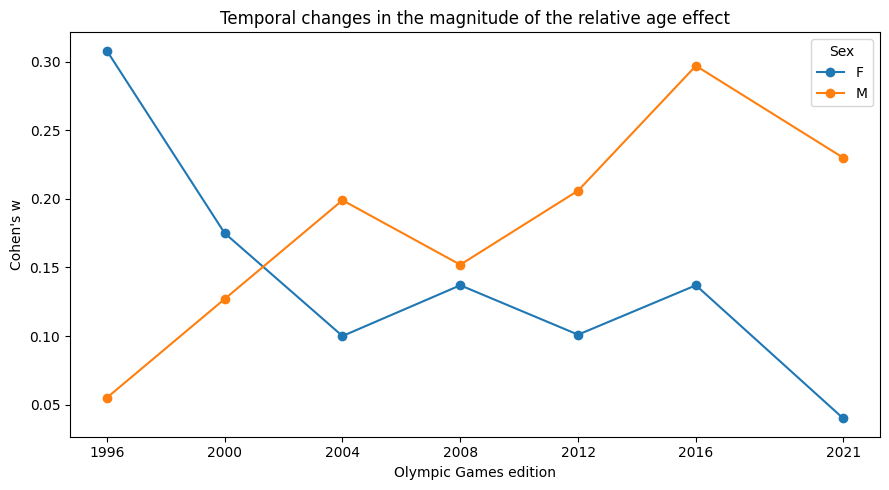

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

for sex, group in temporal_rae_summary.groupby('Sex'):
    plt.plot(
        group['Year'],
        group['Cohens_w'],
        marker='o',
        label=sex
    )

plt.xlabel('Olympic Games edition')
plt.ylabel("Cohen's w")
plt.title(
    'Temporal changes in the magnitude of the relative age effect'
)

plt.xticks(
    temporal_rae_summary['Year'].unique()
)

plt.legend(
    title='Sex'
)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Female: rho = {rho_f:.3f}, p = {p_rho_f:.6f}")
print(f"Male: rho = {rho_m:.3f}, p = {p_rho_m:.6f}")

Female: rho = -0.721, p = 0.067635
Male: rho = 0.929, p = 0.002519


### Resultados da análise temporal | Temporal Analysis Results

**Português:** A distribuição dos quartis de nascimento não diferiu significativamente entre as edições olímpicas no futebol feminino, χ²(18) = 16,719, p = 0,543, V de Cramér = 0,060. A magnitude do efeito da idade relativa, estimada pelo w de Cohen em cada edição, apresentou associação monotônica negativa com o ano dos Jogos Olímpicos (ρ de Spearman = -0,721, p = 0,068). Embora a direção da associação sugira redução da magnitude do efeito ao longo do tempo, essa tendência não atingiu significância estatística.

No futebol masculino, a distribuição dos quartis diferiu significativamente entre as edições olímpicas, χ²(18) = 33,927, p = 0,013, embora a magnitude da associação tenha sido pequena (V de Cramér = 0,069). Adicionalmente, observou-se forte associação monotônica positiva entre o ano da edição e a magnitude do efeito da idade relativa (ρ de Spearman = 0,929, p = 0,003), indicando que edições mais recentes tenderam a apresentar maior magnitude do desvio em relação à distribuição teórica dos quartis de nascimento.

**English:** The birth-quartile distribution did not differ significantly across Olympic editions in women's football, χ²(18) = 16.719, p = 0.543, Cramér's V = 0.060. The magnitude of the relative age effect, estimated using Cohen's w for each edition, showed a negative monotonic association with Olympic year (Spearman's ρ = -0.721, p = 0.068). Although the direction of the association suggested a reduction in effect magnitude over time, this trend did not reach statistical significance.

In men's football, the birth-quartile distribution differed significantly across Olympic editions, χ²(18) = 33.927, p = 0.013, although the magnitude of the association was small (Cramér's V = 0.069). Additionally, a strong positive monotonic association was observed between Olympic year and the magnitude of the relative age effect (Spearman's ρ = 0.929, p = 0.003), indicating that more recent editions tended to show larger deviations from the theoretical birth-quartile distribution.

## 4.6 Síntese dos principais resultados | Summary of Main Findings

**Português:** A análise de 3.914 registros elegíveis demonstrou que a distribuição global dos atletas entre os quartis de nascimento diferiu da distribuição teórica corrigida pelo número de dias de cada quartil, χ²(3) = 63,724, p < 0,001, w = 0,128. O padrão foi caracterizado principalmente pela super-representação de Q1 e Q2 e pela sub-representação de Q4.

Quando estratificada por sexo, a distribuição diferiu da expectativa teórica tanto entre os homens, χ²(3) = 58,737, p < 0,001, w = 0,158, quanto entre as mulheres, χ²(3) = 17,162, p < 0,001, w = 0,105. Nos homens, os maiores desvios ocorreram em Q1, com super-representação, e Q4, com sub-representação. Nas mulheres, o maior excesso ocorreu em Q2, enquanto Q4 apresentou o maior déficit.

A distribuição dos quartis também apresentou associação com o sexo, χ²(3) = 11,273, p = 0,010, V de Cramér = 0,054, embora a magnitude dessa associação tenha sido pequena.

Nas análises temporais, não houve evidência de mudança significativa na distribuição dos quartis entre as edições do futebol feminino, χ²(18) = 16,719, p = 0,543, V = 0,060. A magnitude do efeito apresentou tendência de redução ao longo das edições, mas sem significância estatística (ρ = -0,721, p = 0,068). No futebol masculino, a distribuição dos quartis diferiu entre as edições, χ²(18) = 33,927, p = 0,013, V = 0,069, e a magnitude do efeito apresentou forte associação monotônica positiva com o ano da edição (ρ = 0,929, p = 0,003).

**English:** Analysis of 3,914 eligible records showed that the overall distribution of athletes across birth quartiles differed from the theoretical distribution corrected for the number of days in each quartile, χ²(3) = 63.724, p < 0.001, w = 0.128. The pattern was primarily characterized by an overrepresentation of Q1 and Q2 and an underrepresentation of Q4.

When stratified by sex, the distribution differed from the theoretical expectation among both men, χ²(3) = 58.737, p < 0.001, w = 0.158, and women, χ²(3) = 17.162, p < 0.001, w = 0.105. Among men, the largest deviations occurred in Q1, which was overrepresented, and Q4, which was underrepresented. Among women, the largest excess occurred in Q2, whereas Q4 showed the largest deficit.

Birth-quartile distribution was also associated with sex, χ²(3) = 11.273, p = 0.010, Cramér's V = 0.054, although the magnitude of this association was small.

In the temporal analyses, there was no evidence of a significant change in birth-quartile distribution across editions of the women's tournament, χ²(18) = 16.719, p = 0.543, V = 0.060. Effect magnitude showed a decreasing trend across editions, although this association did not reach statistical significance (ρ = -0.721, p = 0.068). In the men's tournament, birth-quartile distribution differed across editions, χ²(18) = 33.927, p = 0.013, V = 0.069, and effect magnitude showed a strong positive monotonic association with Olympic year (ρ = 0.929, p = 0.003).

In [ ]:
table1 = pd.DataFrame({
    'Group': ['Total', 'Male', 'Female'],
    'N': [
        len(df_rae),
        len(male_data),
        len(female_data)
    ],
    'Q1_n': [1108, 713, 395],
    'Q2_n': [1061, 617, 444],
    'Q3_n': [941, 568, 373],
    'Q4_n': [804, 467, 337],
    'Chi_square': [63.724, 58.737, 17.162],
    'df': [3, 3, 3],
    'p_value': [
        p_value,
        male_results['p_value'],
        female_results['p_value']
    ],
    'Cohens_w': [0.128, 0.158, 0.105]
})

for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    table1[f'{q}_percent'] = (
        table1[f'{q}_n']
        / table1['N']
        * 100
    ).round(2)

table1

,Group,N,Q1_n,Q2_n,Q3_n,Q4_n,Chi_square,df,p_value,Cohens_w,Q1_percent,Q2_percent,Q3_percent,Q4_percent
0,Total,3914,1108,1061,941,804,63.724,3,9.404157e-14,0.128,28.31,27.11,24.04,20.54
1,Male,2365,713,617,568,467,58.737,3,1.094222e-12,0.158,30.15,26.09,24.02,19.75
2,Female,1549,395,444,373,337,17.162,3,6.544344e-04,0.105,25.50,28.66,24.08,21.76


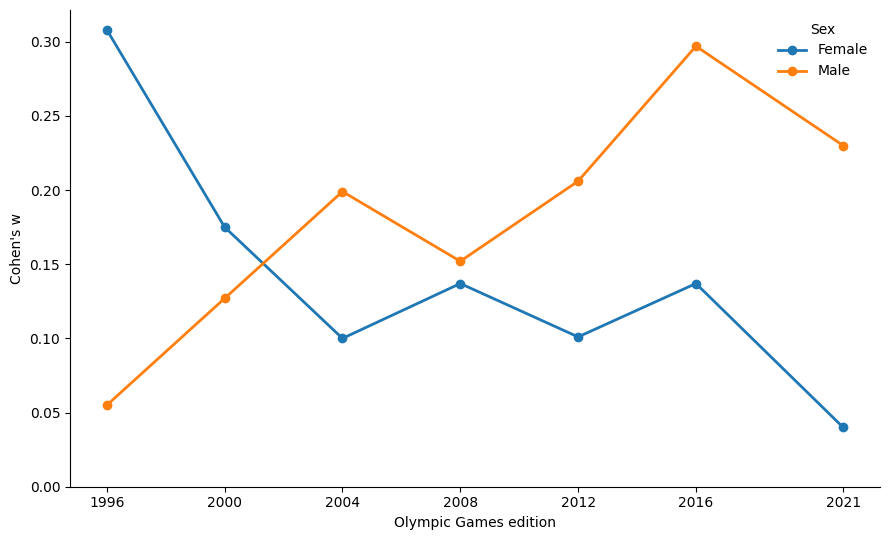

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5.5))

female_plot = temporal_rae_summary.loc[
    temporal_rae_summary['Sex'] == 'F'
]

male_plot = temporal_rae_summary.loc[
    temporal_rae_summary['Sex'] == 'M'
]

ax.plot(
    female_plot['Year'],
    female_plot['Cohens_w'],
    marker='o',
    linewidth=2,
    label='Female'
)

ax.plot(
    male_plot['Year'],
    male_plot['Cohens_w'],
    marker='o',
    linewidth=2,
    label='Male'
)

ax.set_xlabel('Olympic Games edition')
ax.set_ylabel("Cohen's w")

ax.set_xticks(
    sorted(
        temporal_rae_summary['Year'].unique()
    )
)

ax.set_ylim(bottom=0)

ax.legend(
    title='Sex',
    frameon=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    'Figure_1_temporal_RAE.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Figura 1. Magnitude do efeito da idade relativa ao longo das edições dos Jogos Olímpicos, segundo o sexo.** A magnitude do efeito foi expressa pelo w de Cohen derivado do teste do qui-quadrado de aderência em cada edição. No futebol feminino, não foi observada associação significativa entre edição e distribuição dos quartis, χ²(18) = 16,719, p = 0,543, V = 0,060, e a redução temporal do tamanho de efeito não atingiu significância estatística (ρ = -0,721, p = 0,068). No futebol masculino, a distribuição dos quartis diferiu entre as edições, χ²(18) = 33,927, p = 0,013, V = 0,069, e houve associação monotônica positiva entre ano e magnitude do efeito (ρ = 0,929, p = 0,003).